# 3-State Hidden Markov Regime Model — SPY

Fits a 3-state Markov-switching model to daily SPY log returns and labels the states
**Bull**, **Choppy**, and **Bear**. Extends to QQQ / DIA / IWM, and tests whether the
**VOL Regime Index** (the VIX-derived 0-100 composite that `app/services/vix_regime.py` serves)
improves the model.

### Reference

Yuan, Y. & Mitra, G., *Market Regime Identification Using Hidden Markov Models*
([SSRN 3406068](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3406068)). Their setup, which
this notebook follows: daily index log returns as the observation sequence, a Gaussian emission
per hidden state, EM estimation, information criteria for choosing the number of states, and
regime probabilities read off as a market signal. Their motivation is that a single Geometric
Brownian Motion cannot produce the fat tails and volatility clustering equity indices actually
show, whereas a mixture-over-hidden-states can. Part 2 reproduces that check.

### Model

For hidden state $S_t \in \{0,1,2\}$ following a first-order Markov chain,

$$r_t \mid S_t = i \;\sim\; \mathcal{N}(\mu_i,\; \sigma_i^2), \qquad
P(S_t = j \mid S_{t-1} = i) = p_{ij}$$

Both the mean **and** the variance switch — the variance is what actually separates a crisis from
a drift, so holding it fixed across states would defeat the exercise.

### On the middle state's name

It is called **Choppy**, not "mean-reverting". At the daily scale the model measures, that state
is defined by *high volatility and no drift* — chop. Mean reversion is a **medium-horizon**
property and it does not follow automatically from zero drift; Part 8 measures it separately, at
horizons from one day to one quarter, and finds it real but mild. Naming the state for the thing
actually estimated (chop) and testing the thing that isn't (reversion) keeps the two apart.

### Implementation note

`statsmodels.tsa.regime_switching.MarkovRegression` with `trend="c"` and
`switching_variance=True` *is* a Gaussian HMM (Hamilton filter + EM), and it additionally supports
time-varying transition probabilities, which is what Part 9 needs to plug the VOL Regime Index in.
No `hmmlearn` required. Install with `pip install -e ".[notebook]"`.

### Runtime

~11 minutes end to end. Part 11 refits two models a year for 25 years and is most of that.

## Part 0 — Setup

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from tyche_client import TycheClient

# statsmodels warns that our DatetimeIndex has no fixed frequency. Trading days aren't a
# regular frequency and we never forecast off the index, so it's noise.
warnings.filterwarnings("ignore", message=".*date index.*")

load_dotenv(override=True)  # TYCHE_BASE_URL / TYCHE_API_KEY from a local .env (see .env.example)

client = TycheClient(
    os.getenv("TYCHE_BASE_URL", "http://localhost:8000"),
    os.getenv("TYCHE_API_KEY", "tyk_paste_your_key_here").strip(),
)

PRIMARY = "SPY"
SECONDARY = ["QQQ", "DIA", "IWM"]
N_STATES = 3
RETURN_SCALE = 100.0        # log returns in percent: keeps the EM optimizer well-conditioned
SEARCH_REPS = 40            # random restarts; EM on a 3-state mixture has local optima
MAX_ITER = 250
RANDOM_SEED = 1             # see Part 3: EM is multi-modal, so the restart draws are pinned
TRADING_DAYS = 252

BULL, CHOPPY, BEAR = "Bull", "Choppy", "Bear"
LABEL_ORDER = [BULL, CHOPPY, BEAR]
LABEL_COLORS = {BULL: "#16a34a", CHOPPY: "#d97706", BEAR: "#dc2626"}

np.random.seed(RANDOM_SEED)
plt.rcParams.update({"figure.figsize": (13, 4), "axes.grid": True, "grid.alpha": 0.25})

## Part 1 — Data

### The VOL Regime Index, mirrored

`app/services/vix_regime.py` computes the production 0-100 index. This package is standalone —
it reaches the backend only through the read-only `/data/v1` API — so the math is **mirrored here
with the production constants and the same frozen percentile breakpoints**, exactly as
`vix_regime_softmax_blend.ipynb` does. Same inputs give the same numbers the app charts.

If `vix_regime.py`'s methodology changes, this cell has to be re-synced. The breakpoints below
are frozen calibrations against VIX's full 1990-2026 history, deliberately *not* a live rank over
whatever window gets fetched.

In [2]:
ROLLING_WINDOW_DAYS = 504      # 2 trading years  — matches vix_regime.py
RECENCY_HALFLIFE_DAYS = 60     # weight halves every ~60 trading days
LEVEL_TSI_LONG, LEVEL_TSI_SHORT = 40, 20
LEVEL_SOFTMAX_WINDOW_DAYS = 252
LEVEL_RECENCY_WEIGHT = 0.7     # vs 0.3 on softmax(slow TSI)

_RECENCY_WEIGHTS = (0.5 ** (np.arange(ROLLING_WINDOW_DAYS) / RECENCY_HALFLIFE_DAYS))[::-1]
_RECENCY_WEIGHTS = _RECENCY_WEIGHTS / _RECENCY_WEIGHTS.sum()
_PERCENTILE_POSITIONS = np.arange(0, 101)

RECENCY_Z_PERCENTILE_BREAKPOINTS = np.array([
    -2.2894, -1.5005, -1.3800, -1.2819, -1.2245, -1.1703, -1.1287, -1.0962, -1.0683, -1.0476,
    -1.0218, -1.0008, -0.9822, -0.9625, -0.9433, -0.9250, -0.9072, -0.8906, -0.8693, -0.8532,
    -0.8370, -0.8198, -0.8067, -0.7926, -0.7752, -0.7565, -0.7396, -0.7239, -0.7040, -0.6904,
    -0.6739, -0.6538, -0.6385, -0.6215, -0.6045, -0.5897, -0.5726, -0.5543, -0.5372, -0.5186,
    -0.5016, -0.4827, -0.4642, -0.4440, -0.4237, -0.4057, -0.3859, -0.3658, -0.3465, -0.3252,
    -0.3000, -0.2769, -0.2549, -0.2287, -0.2030, -0.1818, -0.1535, -0.1265, -0.1024, -0.0783,
    -0.0504, -0.0150, 0.0087, 0.0348, 0.0599, 0.0898, 0.1229, 0.1516, 0.1840, 0.2208,
    0.2529, 0.2849, 0.3211, 0.3587, 0.3964, 0.4383, 0.4741, 0.5084, 0.5604, 0.6164,
    0.6674, 0.7166, 0.7720, 0.8322, 0.8894, 0.9502, 1.0039, 1.0617, 1.1392, 1.2171,
    1.2939, 1.3792, 1.4893, 1.5854, 1.6915, 1.8099, 1.9814, 2.1899, 2.5426, 3.1848,
    7.9555,
])
SOFTMAX_TSI_SLOW_PERCENTILE_BREAKPOINTS = np.array([
    -3.3712, -1.0368, 0.7416, 1.2148, 1.9063, 2.1405, 2.6270, 2.9798, 3.1071, 3.3185,
    3.6067, 3.7507, 3.8595, 3.9494, 4.1287, 4.3336, 4.4464, 4.6852, 4.8168, 4.8878,
    4.9656, 5.0627, 5.2132, 5.3237, 5.3960, 5.4983, 5.5674, 5.6619, 5.7697, 5.8520,
    5.9023, 5.9555, 6.0019, 6.0589, 6.1152, 6.2837, 6.4101, 6.6142, 6.7145, 6.8055,
    6.8612, 6.9540, 7.0588, 7.2366, 7.3524, 7.4576, 7.5769, 7.6335, 7.7229, 7.8872,
    8.2237, 8.5789, 8.8433, 9.0205, 9.0924, 9.1411, 9.1915, 9.2334, 9.3198, 9.4146,
    9.5923, 9.7560, 9.8396, 9.8839, 10.0933, 10.2080, 10.2940, 10.3767, 10.4952, 10.7663,
    10.8581, 10.9996, 11.1492, 11.2043, 11.3337, 11.4617, 11.5958, 11.6507, 11.8154, 12.1197,
    12.3120, 12.4808, 12.6216, 12.7392, 13.0052, 13.3499, 13.8307, 14.5022, 14.7475, 14.9702,
    15.3335, 16.2232, 18.1496, 18.6631, 18.8365, 20.6291, 21.4665, 22.2605, 22.9894, 23.5253,
    63.8537,
])


def recency_z_series(closes: np.ndarray) -> np.ndarray:
    """Recency-weighted rolling z-score; NaN until ROLLING_WINDOW_DAYS of history exists."""
    closes = np.asarray(closes, dtype=float)
    z = np.full(len(closes), np.nan)
    if len(closes) < ROLLING_WINDOW_DAYS:
        return z
    windows = np.lib.stride_tricks.sliding_window_view(closes, ROLLING_WINDOW_DAYS)
    means = windows @ _RECENCY_WEIGHTS
    stds = np.sqrt(((windows - means[:, None]) ** 2) @ _RECENCY_WEIGHTS)
    with np.errstate(invalid="ignore", divide="ignore"):
        z[ROLLING_WINDOW_DAYS - 1:] = np.where(stds > 0, (windows[:, -1] - means) / stds, 0.0)
    return z


def tsi(closes: np.ndarray, long: int, short: int) -> np.ndarray:
    """True Strength Index: double-EMA-smoothed momentum oscillator, roughly +/-100."""
    change = pd.Series(closes).diff()
    smoothed = change.ewm(span=long, adjust=False).mean().ewm(span=short, adjust=False).mean()
    smoothed_abs = change.abs().ewm(span=long, adjust=False).mean().ewm(span=short, adjust=False).mean()
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(smoothed_abs.to_numpy() > 0, 100 * smoothed.to_numpy() / smoothed_abs.to_numpy(), 0.0)


def softmax_weighted_series(values: np.ndarray, window_days: int) -> np.ndarray:
    """Softmax-weighted rolling mean in the values' own units; spikiest days dominate."""
    out = np.full(len(values), np.nan)
    if len(values) < window_days:
        return out
    windows = np.lib.stride_tricks.sliding_window_view(values, window_days)
    win_mean = windows.mean(axis=1, keepdims=True)
    win_std = windows.std(axis=1, keepdims=True)
    with np.errstate(invalid="ignore"):
        standardized = np.where(win_std > 0, (windows - win_mean) / win_std, 0.0)
        exp = np.exp(standardized - standardized.max(axis=1, keepdims=True))
        out[window_days - 1:] = (windows * (exp / exp.sum(axis=1, keepdims=True))).sum(axis=1)
    return out


def vol_regime_index(closes: np.ndarray) -> np.ndarray:
    """0-100 VOL Regime Index: 70/30 percentile blend of recency-z and softmax(slow TSI)."""
    closes = np.asarray(closes, dtype=float)
    recency_z = recency_z_series(closes)
    softmax_tsi = softmax_weighted_series(tsi(closes, LEVEL_TSI_LONG, LEVEL_TSI_SHORT),
                                          LEVEL_SOFTMAX_WINDOW_DAYS)
    valid = ~(np.isnan(recency_z) | np.isnan(softmax_tsi))
    index = np.full(len(closes), np.nan)
    index[valid] = (
        LEVEL_RECENCY_WEIGHT * np.interp(recency_z[valid], RECENCY_Z_PERCENTILE_BREAKPOINTS, _PERCENTILE_POSITIONS)
        + (1 - LEVEL_RECENCY_WEIGHT) * np.interp(softmax_tsi[valid], SOFTMAX_TSI_SLOW_PERCENTILE_BREAKPOINTS, _PERCENTILE_POSITIONS)
    )
    return index

### Pull prices

VIX back to 1990 (the index needs a 504-day warm-up, absorbed long before SPY's first bar), and
SPY closes. The `/data/v1` price feed serves unadjusted closes, so these are **price returns, not
total returns** — that shaves roughly 1.5-2 %/yr off every annualized figure below and leaves
regime identification, which is driven by volatility, untouched.

In [3]:
vix = client.series("vix", "VIX").sort_index()
index_series = pd.Series(vol_regime_index(vix.to_numpy()), index=vix.index, name="vol_regime_index")


def load_returns(symbol: str) -> pd.DataFrame:
    """Daily log returns (in %) for `symbol`, joined to VIX and the VOL Regime Index."""
    closes = client.prices(symbol, start="1990-01-01")["Close"].sort_index().rename("close")
    df = pd.concat([closes, vix.rename("vix"), index_series], axis=1, join="inner")
    df["ret"] = RETURN_SCALE * np.log(df["close"]).diff()
    return df.dropna(subset=["ret", "vol_regime_index"])


spy = load_returns(PRIMARY)
returns = spy["ret"]

print(f"VIX               : {len(vix):,} obs, {vix.index.min():%Y-%m-%d} .. {vix.index.max():%Y-%m-%d}")
print(f"VOL Regime Index  : first valid {index_series.first_valid_index():%Y-%m-%d}")
print(f"{PRIMARY} (joined)      : {len(spy):,} obs, {spy.index.min():%Y-%m-%d} .. {spy.index.max():%Y-%m-%d}")
spy[["close", "vix", "vol_regime_index", "ret"]].describe().T

VIX               : 9,238 obs, 1990-01-02 .. 2026-07-28
VOL Regime Index  : first valid 1991-12-30
SPY (joined)      : 7,537 obs, 1996-08-07 .. 2026-07-28


,count,mean,std,min,25%,50%,75%,max
close,7537.0,221.986292,155.927499,65.015625,116.519997,143.812500,280.450012,759.570007
vix,7537.0,20.210088,8.089523,9.140000,14.530000,18.610000,23.650000,82.690000
vol_regime_index,7537.0,50.944012,23.800449,1.736294,31.105850,51.310392,70.734303,99.215121
ret,7537.0,0.032009,1.218664,-11.588654,-0.492530,0.064916,0.621076,13.557731


## Part 2 — Why one Gaussian is not enough

The paper's opening argument. If returns were a single GBM, daily log returns would be i.i.d.
normal: kurtosis 3, no autocorrelation in $|r_t|$. Neither holds.

excess kurtosis      : 10.63   (normal = 0)
skew                 : -0.23   (normal = 0)
Jarque-Bera p-value  : 0.00e+00
|r| autocorr lag 1   : 0.274   (i.i.d. = 0)
|r| autocorr lag 20  : 0.208


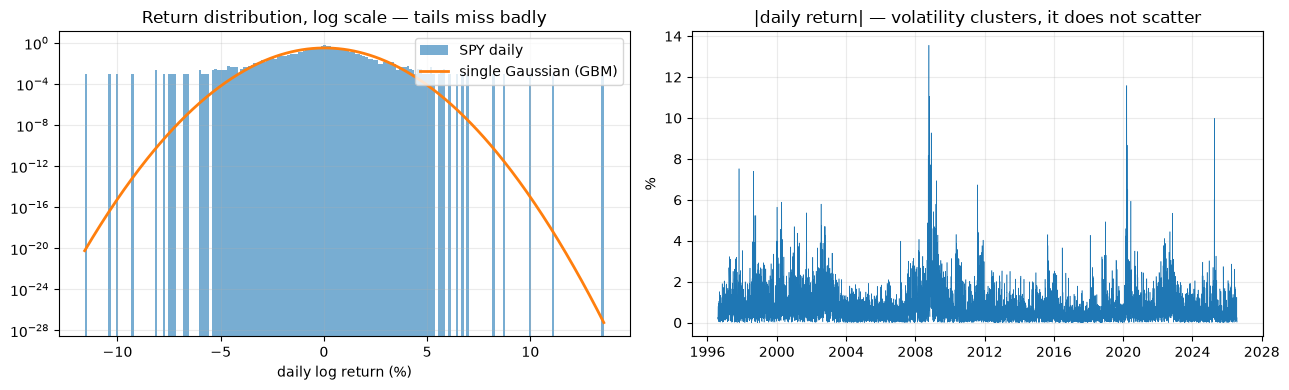

In [4]:
from scipy import stats

print(f"excess kurtosis      : {stats.kurtosis(returns, fisher=False) - 3:.2f}   (normal = 0)")
print(f"skew                 : {stats.skew(returns):.2f}   (normal = 0)")
print(f"Jarque-Bera p-value  : {stats.jarque_bera(returns).pvalue:.2e}")
print(f"|r| autocorr lag 1   : {returns.abs().autocorr(1):.3f}   (i.i.d. = 0)")
print(f"|r| autocorr lag 20  : {returns.abs().autocorr(20):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
grid = np.linspace(returns.min(), returns.max(), 400)
ax[0].hist(returns, bins=200, density=True, alpha=0.6, label=f"{PRIMARY} daily")
ax[0].plot(grid, stats.norm.pdf(grid, returns.mean(), returns.std()), lw=2, label="single Gaussian (GBM)")
ax[0].set_yscale("log")
ax[0].set_title("Return distribution, log scale — tails miss badly")
ax[0].set_xlabel("daily log return (%)")
ax[0].legend()

ax[1].plot(returns.index, returns.abs(), lw=0.4)
ax[1].set_title("|daily return| — volatility clusters, it does not scatter")
ax[1].set_ylabel("%")
plt.tight_layout()
plt.show()

The tails are far too heavy for one Gaussian and volatility arrives in clusters. Both are exactly
what a mixture over persistent hidden states reproduces: the fat tails come from the high-variance
state's Gaussian, and the clustering comes from that state being *persistent* rather than drawn
fresh each day.

## Part 3 — How many states?

The paper selects the number of states by information criteria rather than assuming it. We do the
same, and treat the answer skeptically: a state that lasts one day is a mechanism for absorbing
outliers, not a market regime.

In [5]:
def fit_markov(y: pd.Series, k: int = N_STATES, exog_tvtp=None, search_reps: int = SEARCH_REPS):
    """Fit a k-state Gaussian Markov-switching model (switching mean and variance)."""
    model = MarkovRegression(y, k_regimes=k, trend="c", switching_variance=True, exog_tvtp=exog_tvtp)
    return model.fit(search_reps=search_reps, maxiter=MAX_ITER, disp=False)


def state_params(res) -> pd.DataFrame:
    """Per-state fitted mean, sd and expected duration, indexed by raw state number."""
    p = dict(zip(res.model.param_names, res.params))
    k = res.model.k_regimes
    durations = np.asarray(res.expected_durations)
    if durations.ndim > 1:
        durations = durations.mean(axis=0)  # time-varying transitions give one duration per day
    return pd.DataFrame({
        "mu": [p[f"const[{i}]"] for i in range(k)],
        "sd": [p[f"sigma2[{i}]"] ** 0.5 for i in range(k)],
        "duration_days": durations,
    })


fits, selection = {}, {}
for k in (2, 3, 4, 5):
    fits[k] = res_k = fit_markov(returns, k=k)
    selection[k] = {
        "loglik": res_k.llf,
        "n_params": len(res_k.params),
        "aic": res_k.aic,
        "bic": res_k.bic,
        "min_duration_days": np.asarray(res_k.expected_durations).min(),
    }
    print(f"k={k} done")

pd.DataFrame(selection).T.round(1)

k=2 done


k=3 done


k=4 done


k=5 done


,loglik,n_params,aic,bic,min_duration_days
2,-10799.6,6.0,21611.2,21652.7,33.2
3,-10455.4,12.0,20934.9,21018.0,20.0
4,-10417.2,20.0,20874.4,21012.9,1.0
5,-10359.3,30.0,20778.6,20986.4,1.0


BIC keeps improving as states are added — which is what BIC almost always does for a mixture fit
to financial returns, since there is always another tail to carve off. The number to look at
instead is `min_duration_days`: from k=4 onward the model spends its new states on **expected
durations of about one day**. A one-day state is an outlier bucket, not a market regime, and the
k=3 → k=4 gain that buys it is small anyway.

**A note on reproducibility.** EM on a mixture this size is multi-modal: independent runs of the
same `k` can land on optima hundreds of log-likelihood points apart, and a bad draw for `k=3`
produces a degenerate 1-day state of its own. `RANDOM_SEED` therefore pins the restart draws, and
the `loglik` column is what tells you which optimum was reached — higher is the better fit, and
that is the one to compare on BIC. Part 4 reuses this table's `k=3` fit rather than refitting, so
the two sections cannot disagree.

Three states is the largest model where every state is persistent enough to be a regime.

## Part 4 — Fit and label the three states

EM returns states in arbitrary order, so labels have to be assigned from the fitted parameters,
never hardcoded by index. The rule:

- **Bear** — the highest-variance state. Crises are unambiguous in variance; using the mean would
  be fragile, since a bear state's mean is estimated off few observations.
- **Bull** — of the two remaining, the higher mean.
- **Choppy** — what's left: the middle-variance, near-zero-drift state.

In [6]:
def label_states(res) -> dict[str, int]:
    """Map {label: raw state index} from fitted params. Highest variance = Bear."""
    params = state_params(res)
    bear = int(params["sd"].idxmax())
    rest = [i for i in params.index if i != bear]
    bull = int(params.loc[rest, "mu"].idxmax())
    choppy = next(i for i in rest if i != bull)
    return {BULL: bull, CHOPPY: choppy, BEAR: bear}


def labelled_probabilities(res, labels: dict[str, int], index, smoothed: bool = True) -> pd.DataFrame:
    """State probabilities as columns named Bull / Choppy / Bear.

    `index` must be passed in: statsmodels drops our DatetimeIndex (trading days have no
    fixed frequency) and hands results back on a RangeIndex, which silently misaligns
    against the price frame.
    """
    probs = res.smoothed_marginal_probabilities if smoothed else res.filtered_marginal_probabilities
    frame = pd.DataFrame(np.asarray(probs), index=index)
    return frame[[labels[name] for name in LABEL_ORDER]].set_axis(LABEL_ORDER, axis=1)


def transition_matrix(res, labels: dict[str, int], mask=None) -> pd.DataFrame:
    """P(next = column | current = row), averaged over `mask` if transitions are time-varying.

    statsmodels stores `regime_transition[to, from, t]` — destination first — so this
    transposes before labelling. Getting that backwards silently reports the reverse chain.
    """
    order = [labels[name] for name in LABEL_ORDER]
    matrices = res.regime_transition if mask is None else res.regime_transition[:, :, mask]
    return pd.DataFrame(
        matrices.mean(axis=2).T[np.ix_(order, order)],
        index=[f"from {name}" for name in LABEL_ORDER],
        columns=[f"to {name}" for name in LABEL_ORDER],
    )


res = fits[N_STATES]  # the same fit the selection table scored — never refit and risk disagreeing
labels = label_states(res)
probs = labelled_probabilities(res, labels, returns.index)
spy["regime"] = probs.idxmax(axis=1)

params = state_params(res)
summary = pd.DataFrame({
    "fitted_mean_%_day": [params.mu[labels[n]] for n in LABEL_ORDER],
    "fitted_sd_%_day": [params.sd[labels[n]] for n in LABEL_ORDER],
    "expected_duration_days": [params.duration_days[labels[n]] for n in LABEL_ORDER],
}, index=LABEL_ORDER)
summary["annualized_return_%"] = summary["fitted_mean_%_day"] * TRADING_DAYS
summary["annualized_vol_%"] = summary["fitted_sd_%_day"] * np.sqrt(TRADING_DAYS)

grouped = spy.groupby("regime")["ret"]
summary["share_of_days"] = (grouped.count() / len(spy)).reindex(LABEL_ORDER)
summary["daily_ar1"] = grouped.apply(lambda r: r.autocorr(1)).reindex(LABEL_ORDER)
summary["mean_vix"] = spy.groupby("regime")["vix"].mean().reindex(LABEL_ORDER)
summary["mean_vol_regime_index"] = spy.groupby("regime")["vol_regime_index"].mean().reindex(LABEL_ORDER)
summary.round(3)

,fitted_mean_%_day,fitted_sd_%_day,expected_duration_days,annualized_return_%,annualized_vol_%,share_of_days,daily_ar1,mean_vix,mean_vol_regime_index
Bull,0.117,0.561,37.458,29.464,8.900,0.453,-0.069,14.855,37.144
Choppy,-0.007,1.196,29.879,-1.675,18.990,0.475,-0.037,22.509,59.462
Bear,-0.237,2.963,20.049,-59.614,47.028,0.072,-0.171,38.696,81.508


### Reading the states

- **Bull** — roughly half of all days, positive drift, the *lowest* volatility of the three. The
  equity risk premium is earned in a quiet market, not a violent one.
- **Choppy** — the other near-half of the sample, drift statistically indistinguishable from zero,
  volatility about double the Bull state. A lot of movement going nowhere.
- **Bear** — a small minority of days, deeply negative drift and roughly 5x Bull volatility.

Volatility, not return, is what separates them — the Bull and Choppy *means* differ by about a
tenth of a percent a day, while their standard deviations differ by more than 2x.

Note `daily_ar1`: at the one-day scale the Choppy state shows only mild negative autocorrelation,
and less of it than Bear. That is the reason this state is named for chop rather than for
reversion — Part 8 takes the reversion question to the horizons where it actually lives.

### The transition matrix

In [7]:
transition_matrix(res, labels).round(4)

,to Bull,to Choppy,to Bear
from Bull,0.9733,0.0266,0.0001
from Choppy,0.0258,0.9665,0.0077
from Bear,0.0000,0.0499,0.9501


The diagonal dominance is the volatility clustering from Part 2, now parameterized: regimes
persist.

The economically interesting result is the **two near-zeros in the Bull ↔ Bear corners**. In
either direction, the market does not jump between a quiet uptrend and a crisis in one step — it
has to pass through the Choppy state. That is a structural claim with a direct trading
implication: **leaving a bear signal means going neutral, not re-risking**, and equally, a bull
regime gives up its low-volatility character before it crashes. Chop is the airlock.

## Part 5 — Regime history

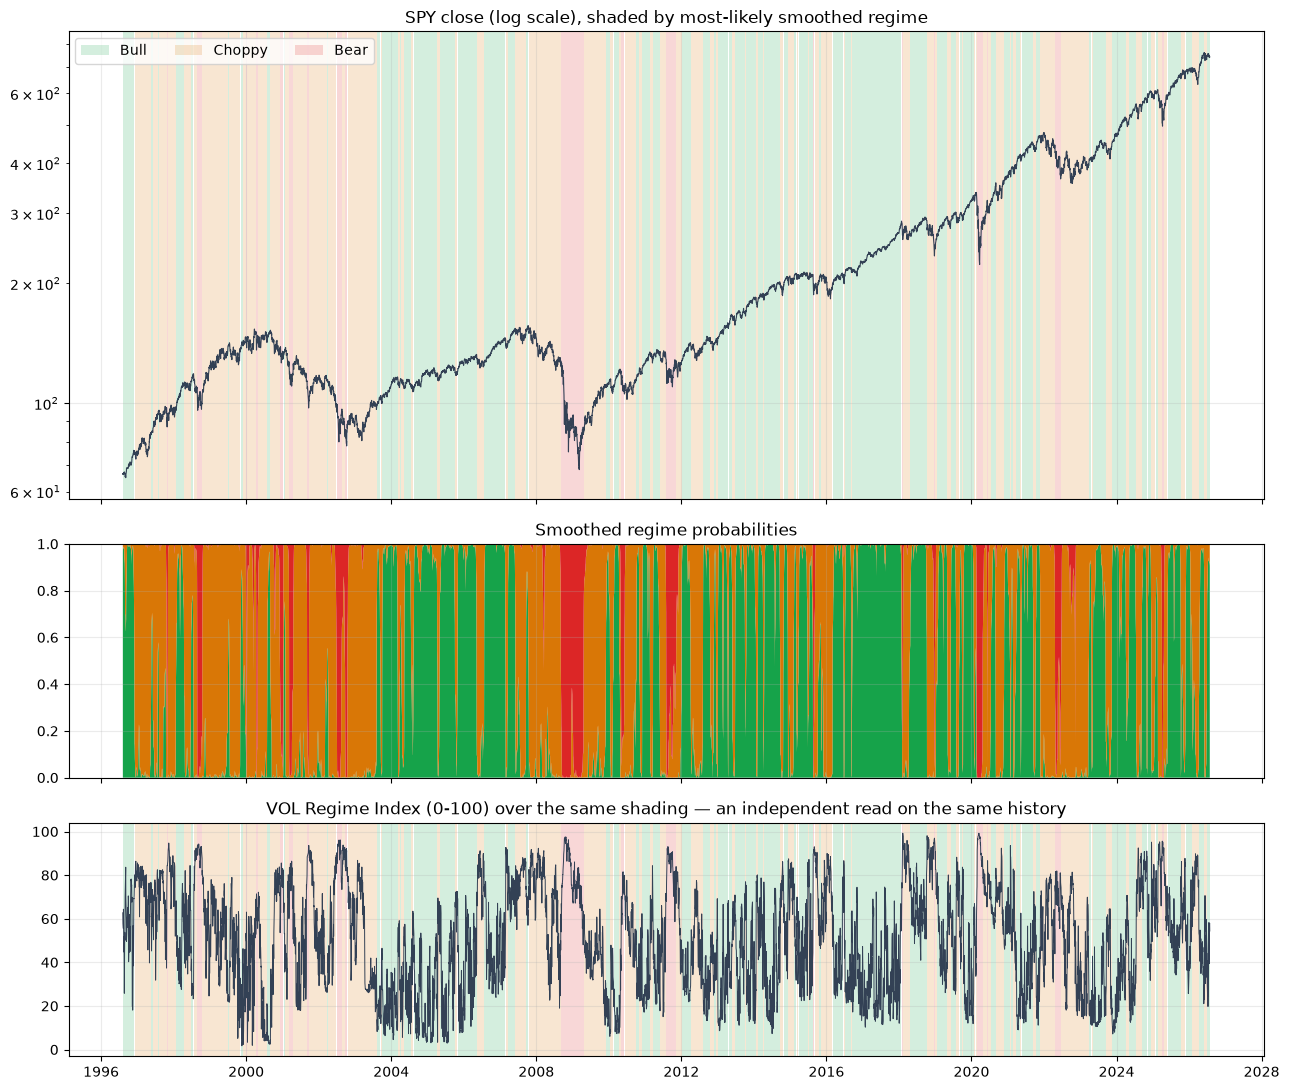

Bear-state days by year (top 10):
date
2008    84
2009    75
2011    71
2002    54
2020    45
2022    42
2001    41
1998    35
2000    33
2010    24
dtype: int64


In [8]:
fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True, height_ratios=[2, 1, 1])


def shade_regimes(axis, frame):
    """Shade an axis by most-likely regime. Called after the data is plotted so ylim is settled."""
    lo, hi = axis.get_ylim()
    for name in LABEL_ORDER:
        axis.fill_between(frame.index, lo, hi, where=(frame["regime"] == name).to_numpy(),
                          color=LABEL_COLORS[name], alpha=0.18, lw=0, label=name)
    axis.set_ylim(lo, hi)


ax[0].plot(spy.index, spy["close"], color="#334155", lw=0.8)
ax[0].set_yscale("log")
shade_regimes(ax[0], spy)
ax[0].set_title(f"{PRIMARY} close (log scale), shaded by most-likely smoothed regime")
ax[0].legend(loc="upper left", ncol=3)

ax[1].stackplot(probs.index, *[probs[n] for n in LABEL_ORDER],
                colors=[LABEL_COLORS[n] for n in LABEL_ORDER], labels=LABEL_ORDER)
ax[1].set_ylim(0, 1)
ax[1].set_title("Smoothed regime probabilities")

ax[2].plot(spy.index, spy["vol_regime_index"], color="#334155", lw=0.7)
shade_regimes(ax[2], spy)
ax[2].set_title("VOL Regime Index (0-100) over the same shading — an independent read on the same history")
plt.tight_layout()
plt.show()

bear_days = spy[spy["regime"] == BEAR]
print("Bear-state days by year (top 10):")
print(bear_days.groupby(bear_days.index.year).size().sort_values(ascending=False).head(10))

The Bear state concentrates where it should, which is the basic sanity check that the states are
picking up markets rather than fitting noise. The third panel is the payoff of overlaying the two
models: the VOL Regime Index — which never sees a single SPY return — rises and falls with the
same shading, and Part 9 turns that visual agreement into a formal test.

**These are smoothed probabilities: they use the whole sample, including the future.** They are
the right tool for describing history and the wrong one for trading. Part 11 redoes this causally.

## Part 6 — The regimes as a picture

Regime tables are abstract. These scatterplots are the same model with the numbers taken out.

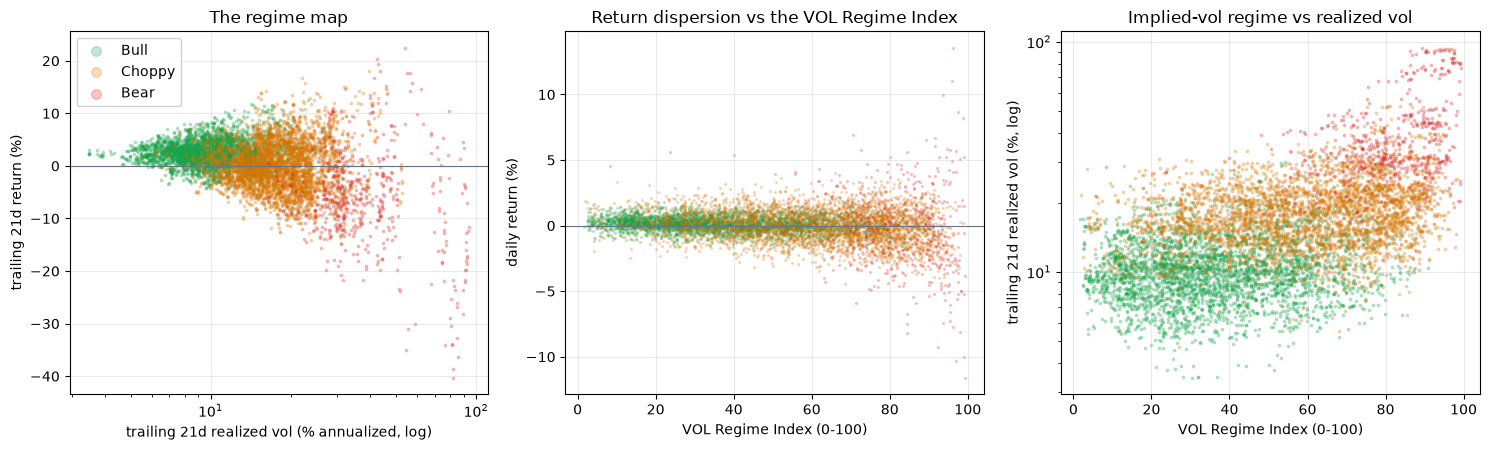

In [9]:
ROLLING_WINDOW = 21  # one trading month

view = spy.copy()
view["rolling_return"] = view["ret"].rolling(ROLLING_WINDOW).sum()
view["rolling_vol"] = view["ret"].rolling(ROLLING_WINDOW).std() * np.sqrt(TRADING_DAYS)
view = view.dropna(subset=["rolling_return", "rolling_vol"])

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))

for name in LABEL_ORDER:
    sub = view[view["regime"] == name]
    ax[0].scatter(sub["rolling_vol"], sub["rolling_return"], s=3, alpha=0.25,
                  color=LABEL_COLORS[name], label=name)
ax[0].axhline(0, color="#64748b", lw=0.8)
ax[0].set_xscale("log")
ax[0].set_xlabel(f"trailing {ROLLING_WINDOW}d realized vol (% annualized, log)")
ax[0].set_ylabel(f"trailing {ROLLING_WINDOW}d return (%)")
ax[0].set_title("The regime map")
ax[0].legend(markerscale=4, framealpha=0.9)

for name in LABEL_ORDER:
    sub = spy[spy["regime"] == name]
    ax[1].scatter(sub["vol_regime_index"], sub["ret"], s=2, alpha=0.2, color=LABEL_COLORS[name])
ax[1].axhline(0, color="#64748b", lw=0.8)
ax[1].set_xlabel("VOL Regime Index (0-100)")
ax[1].set_ylabel("daily return (%)")
ax[1].set_title("Return dispersion vs the VOL Regime Index")

for name in LABEL_ORDER:
    sub = view[view["regime"] == name]
    ax[2].scatter(sub["vol_regime_index"], sub["rolling_vol"], s=3, alpha=0.25, color=LABEL_COLORS[name])
ax[2].set_yscale("log")
ax[2].set_xlabel("VOL Regime Index (0-100)")
ax[2].set_ylabel(f"trailing {ROLLING_WINDOW}d realized vol (%, log)")
ax[2].set_title("Implied-vol regime vs realized vol")

plt.tight_layout()
plt.show()

The left panel is the model in one image: three clouds, separated almost entirely along the
**volatility** axis, with the return axis deciding only which of the two high-vol clouds you are
in. Bull sits low-vol and above zero; Choppy sits mid-vol straddling zero; Bear sits high-vol and
below.

The middle panel shows the states are not arbitrary cuts of the index — they overlap on it
substantially. The two models are correlated, not redundant, which is what makes Part 9's test
worth running rather than tautological.

## Part 7 — Episodes, not days

A regime is a *run* of days. Collapsing each contiguous run into one point is the sharpest test of
whether "Choppy" is the right word: if the state really is directionless, its episodes should end
where they began no matter how long they last.

Episodes of at least 5 days:
        episodes  median_days  max_days  mean_cum_return  median_cum_return  \
regime                                                                        
Bull          67         35.0       342             6.01               5.01   
Choppy        83         26.0       202            -0.23              -1.23   
Bear          19         19.0       158            -7.63              -5.35   

        sd_cum_return  share_ending_flat_+-2%  corr_length_vs_return  
regime                                                                
Bull             4.97                    0.21                   0.81  
Choppy           7.19                    0.31                   0.36  
Bear             9.52                    0.11                  -0.78  


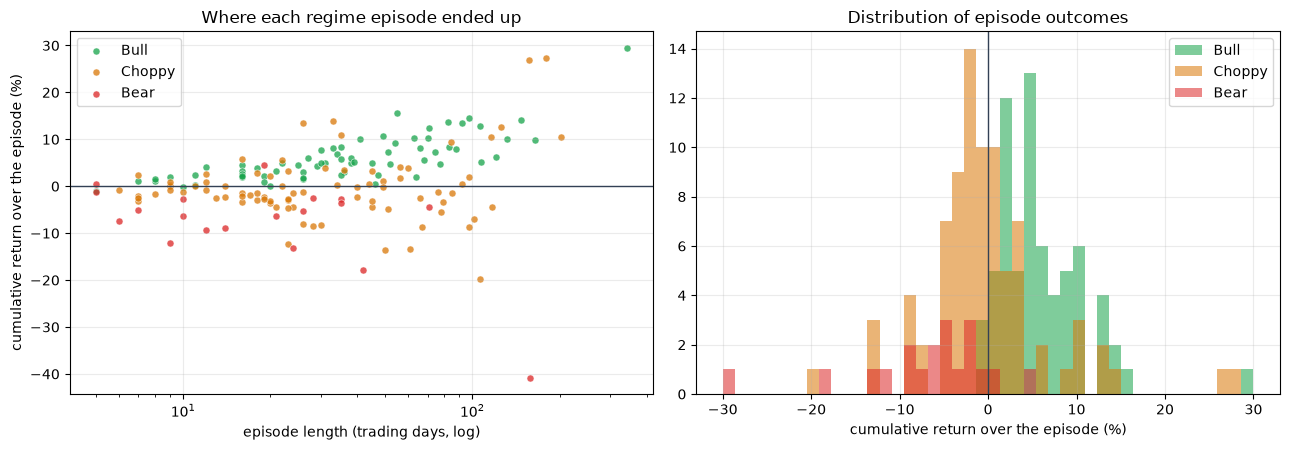

In [10]:
MIN_EPISODE_DAYS = 5

episode_id = (spy["regime"] != spy["regime"].shift()).cumsum()
episodes = spy.assign(episode=episode_id).groupby("episode").agg(
    regime=("regime", "first"),
    start=("ret", lambda s: s.index[0]),
    days=("ret", "size"),
    cumulative_return=("ret", "sum"),
)
episodes = episodes[episodes["days"] >= MIN_EPISODE_DAYS]

episode_stats = episodes.groupby("regime").agg(
    episodes=("days", "size"),
    median_days=("days", "median"),
    max_days=("days", "max"),
    mean_cum_return=("cumulative_return", "mean"),
    median_cum_return=("cumulative_return", "median"),
    sd_cum_return=("cumulative_return", "std"),
)
episode_stats["share_ending_flat_+-2%"] = (
    episodes.assign(flat=episodes["cumulative_return"].abs() < 2).groupby("regime")["flat"].mean()
)
# Does a longer episode take price further? Positive = trends with length, ~0 = goes nowhere.
episode_stats["corr_length_vs_return"] = episodes.groupby("regime").apply(
    lambda g: g["days"].corr(g["cumulative_return"]), include_groups=False
)
print(f"Episodes of at least {MIN_EPISODE_DAYS} days:")
print(episode_stats.reindex(LABEL_ORDER).round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for name in LABEL_ORDER:
    sub = episodes[episodes["regime"] == name]
    ax[0].scatter(sub["days"], sub["cumulative_return"], s=26, alpha=0.75,
                  color=LABEL_COLORS[name], edgecolor="white", lw=0.5, label=name)
ax[0].axhline(0, color="#334155", lw=1)
ax[0].set_xscale("log")
ax[0].set_xlabel("episode length (trading days, log)")
ax[0].set_ylabel("cumulative return over the episode (%)")
ax[0].set_title("Where each regime episode ended up")
ax[0].legend()

bins = np.linspace(-30, 30, 45)
for name in LABEL_ORDER:
    ax[1].hist(episodes.loc[episodes["regime"] == name, "cumulative_return"].clip(-30, 30),
               bins=bins, alpha=0.55, color=LABEL_COLORS[name], label=name)
ax[1].axvline(0, color="#334155", lw=1)
ax[1].set_xlabel("cumulative return over the episode (%)")
ax[1].set_title("Distribution of episode outcomes")
ax[1].legend()
plt.tight_layout()
plt.show()

This is the case for the name. Read `corr_length_vs_return`: Bull episodes take price *further* the
longer they last, and Bear episodes take it further down. **Choppy episodes stay pinned to the zero
line at every length** — a median near zero and, despite carrying twice Bull's daily volatility,
the highest share of any state finishing within ±2% of where they started.

Choppy's own length/return correlation is not zero — sitting in chop for four months does drift
you somewhere — but it is roughly half Bull's, off a mean episode return of about zero, so length
buys dispersion rather than direction. Nor does Choppy have the widest spread; Bear does, since
crises are violent in both directions.

That is chop: motion without displacement.

## Part 8 — Is it *mean-reverting*? Only at medium horizons, and only mildly

Zero drift does not imply mean reversion. A zero-drift random walk also goes nowhere on average,
and it has no reversion at all. The testable question is whether a move gets *given back*, and it
has to be asked at a specific horizon.

We measure it directly: given today's state, correlate the past $k$-day return with the next
$k$-day return. Negative means moves reverse at that horizon; zero means random walk; positive
means they extend.

corr(past k-day return, next k-day return) given today's state
negative = reversion, 0 = random walk, positive = momentum

           1d     3d     5d    10d    21d    42d    63d
Bull   -0.069 -0.058 -0.063 -0.059 -0.015  0.016 -0.012
Choppy -0.029 -0.089 -0.116 -0.052 -0.091 -0.023  0.104
Bear   -0.155 -0.097 -0.115 -0.064 -0.132 -0.267  0.070


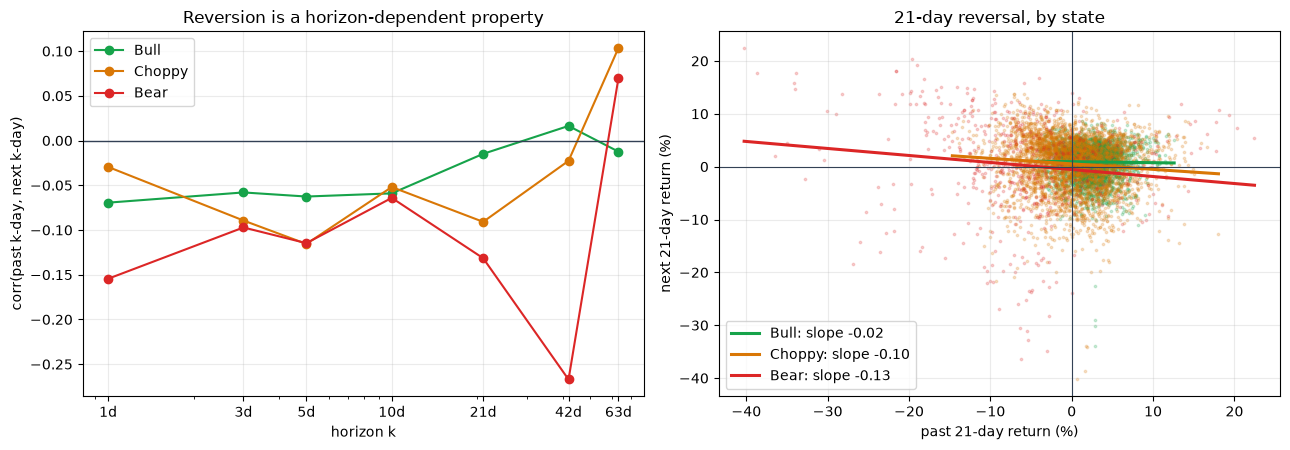

In [11]:
HORIZONS = [1, 3, 5, 10, 21, 42, 63]

log_price = np.log(spy["close"])
reversal = {}
for horizon in HORIZONS:
    past = (log_price - log_price.shift(horizon)) * RETURN_SCALE
    forward = (log_price.shift(-horizon) - log_price) * RETURN_SCALE
    for name in LABEL_ORDER:
        usable = (spy["regime"] == name) & past.notna() & forward.notna()
        reversal.setdefault(name, {})[f"{horizon}d"] = past[usable].corr(forward[usable])

reversal = pd.DataFrame(reversal).T.reindex(LABEL_ORDER)
print("corr(past k-day return, next k-day return) given today's state")
print("negative = reversion, 0 = random walk, positive = momentum\n")
print(reversal.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for name in LABEL_ORDER:
    ax[0].plot(HORIZONS, reversal.loc[name], marker="o", color=LABEL_COLORS[name], label=name)
ax[0].axhline(0, color="#334155", lw=1)
ax[0].set_xscale("log")
ax[0].set_xticks(HORIZONS)
ax[0].set_xticklabels([f"{h}d" for h in HORIZONS])
ax[0].set_xlabel("horizon k")
ax[0].set_ylabel("corr(past k-day, next k-day)")
ax[0].set_title("Reversion is a horizon-dependent property")
ax[0].legend()

SCATTER_HORIZON = 21
past = (log_price - log_price.shift(SCATTER_HORIZON)) * RETURN_SCALE
forward = (log_price.shift(-SCATTER_HORIZON) - log_price) * RETURN_SCALE
for name in LABEL_ORDER:
    usable = (spy["regime"] == name) & past.notna() & forward.notna()
    x, y = past[usable], forward[usable]
    ax[1].scatter(x, y, s=3, alpha=0.2, color=LABEL_COLORS[name])
    slope, intercept = np.polyfit(x, y, 1)
    line = np.linspace(x.min(), x.max(), 20)
    ax[1].plot(line, slope * line + intercept, color=LABEL_COLORS[name], lw=2.2,
               label=f"{name}: slope {slope:+.2f}")
ax[1].axhline(0, color="#334155", lw=0.8)
ax[1].axvline(0, color="#334155", lw=0.8)
ax[1].set_xlabel(f"past {SCATTER_HORIZON}-day return (%)")
ax[1].set_ylabel(f"next {SCATTER_HORIZON}-day return (%)")
ax[1].set_title(f"{SCATTER_HORIZON}-day reversal, by state")
ax[1].legend()
plt.tight_layout()
plt.show()

### Verdict on the name

Read the row for Choppy across horizons. The correlation is near zero at one day, most negative in
the **3-to-21 day band**, and fades again past a quarter. So there *is* medium-term mean reversion
in the choppy state — the user-level intuition is correct — but:

1. **It is mild.** Correlations around −0.1 explain roughly 1% of forward variance. This is a
   tilt, not a trade on its own.
2. **It is not unique to the choppy state.** The Bear state reverses at least as hard, and at
   longer horizons harder — those are the violent snapbacks inside crises.
3. **It is invisible at the daily scale the model actually fits.** Nothing in the estimated
   Gaussian emissions encodes it.

Hence **Choppy**, not "mean-reverting": the name describes what the model estimates — high
volatility, no drift — while mean reversion is a *separate, medium-horizon* property that has to
be measured rather than assumed from the label. Calling the state "mean-reverting" would imply the
model knows something at 3-21 days that it was never fitted to know.

## Part 9 — Does the VOL Regime Index help?

The index already separates the states descriptively (Part 4: mean index rises monotonically Bull
→ Choppy → Bear). That alone doesn't earn it a place in the model, since the model recovers those
states from returns without it.

The question worth asking is whether it improves the part of the model returns are *worst* at
identifying: the **transition probabilities**. A regime change is by construction a
low-information event in the return series — that's why it's hard. Implied volatility is
forward-looking and might know first.

So we let the transition matrix depend on the index (time-varying transition probabilities), where
each transition probability is a multinomial logit in the standardized index instead of a
constant. Nested models, so a likelihood-ratio test is available; BIC guards against paying for
the extra parameters.

In [12]:
from scipy.stats import chi2

INDEX_CENTER, INDEX_SCALE = 50.0, 25.0  # 0-100 index -> roughly mean 0, unit scale


def tvtp_start_params(model, base_res) -> np.ndarray:
    """Seed a TVTP fit at the constant-transition solution: same emissions, flat index effect.

    Random restarts on the TVTP likelihood land on wildly different optima — several of them
    degenerate, with transition rows estimated off subsamples that never visit a state. Starting
    from the nested model instead makes the fit reproducible AND keeps the answer interpretable:
    the optimizer reports what the index adds *relative to* the constant-transition model rather
    than re-deriving the regimes from scratch.

    Setting every `.tvtp1` (the index coefficient) to zero and each `.tvtp0` intercept to the
    base model's log-odds against the reference state reproduces the constant model exactly, so
    this is the origin of the extension, not an arbitrary guess.
    """
    base = dict(zip(base_res.model.param_names, base_res.params))
    k = base_res.model.k_regimes
    rows = np.zeros((k, k))
    for i in range(k):
        rows[i, :k - 1] = [base[f"p[{i}->{j}]"] for j in range(k - 1)]
        rows[i, k - 1] = 1 - rows[i, :k - 1].sum()

    start = []
    for name in model.param_names:
        if name.endswith(".tvtp1"):
            start.append(0.0)
        elif name.endswith(".tvtp0"):
            source, target = (int(x) for x in name[2:].split("].")[0].split("->"))
            start.append(np.log(max(rows[source, target], 1e-8) / max(rows[source, k - 1], 1e-8)))
        else:
            start.append(base[name])
    return np.array(start)


standardized_index = ((spy["vol_regime_index"] - INDEX_CENTER) / INDEX_SCALE).to_numpy()
tvtp_exog = np.column_stack([np.ones(len(standardized_index)), standardized_index])

tvtp_model = MarkovRegression(returns, k_regimes=N_STATES, trend="c",
                              switching_variance=True, exog_tvtp=tvtp_exog)
res_tvtp = tvtp_model.fit(start_params=tvtp_start_params(tvtp_model, res),
                          search_reps=0, maxiter=400, disp=False)

lr_stat = 2 * (res_tvtp.llf - res.llf)
lr_df = len(res_tvtp.params) - len(res.params)
print(pd.DataFrame({
    "loglik": [res.llf, res_tvtp.llf],
    "n_params": [len(res.params), len(res_tvtp.params)],
    "aic": [res.aic, res_tvtp.aic],
    "bic": [res.bic, res_tvtp.bic],
}, index=["constant transitions", "VOL-Regime-Index transitions"]).round(1))
print(f"\nlikelihood-ratio: chi2({lr_df}) = {lr_stat:.1f}, p = {chi2.sf(lr_stat, lr_df):.2e}")
print(f"delta BIC        : {res_tvtp.bic - res.bic:+.1f}  (negative favours the index model)")

                               loglik  n_params      aic      bic
constant transitions         -10455.4        12  20934.9  21018.0
VOL-Regime-Index transitions -10378.4        18  20792.9  20917.6

likelihood-ratio: chi2(6) = 154.0, p = 1.11e-30
delta BIC        : -100.4  (negative favours the index model)


The fitted values themselves are multinomial-logit coefficients measured against a reference
state, which makes them close to unreadable and occasionally enormous where a transition is almost
never observed. The model implies an actual transition matrix for every single day, so read those
instead: average the implied matrices over calm days and over stressed days and compare.


CALM — VOL Regime Index in its bottom 20%   (n = 1,507 days)
             to Bull  to Choppy  to Bear
from Bull     0.9952     0.0048   0.0000
from Choppy   0.0583     0.9407   0.0010
from Bear     0.0000     0.5135   0.4865

STRESS — VOL Regime Index in its top 20%   (n = 1,508 days)
             to Bull  to Choppy  to Bear
from Bull     0.4721     0.1809   0.3471
from Choppy   0.0359     0.9446   0.0195
from Bear     0.0000     0.0819   0.9181


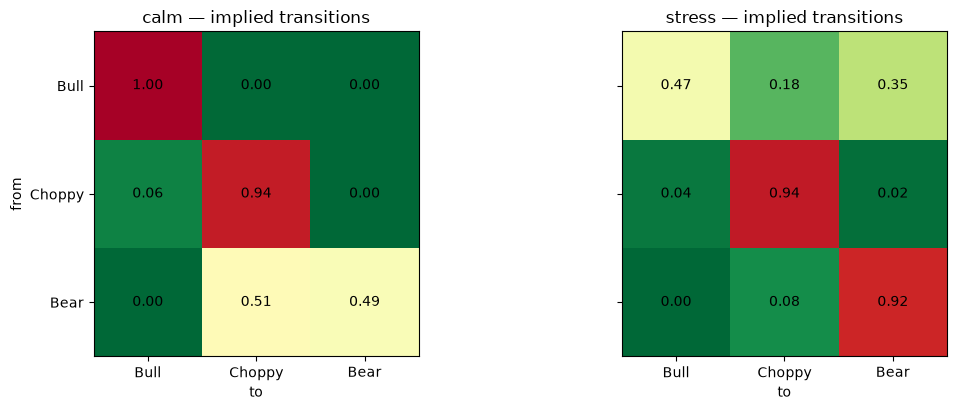

In [13]:
QUINTILE = 0.2

tvtp_labels = label_states(res_tvtp)  # a separate fit: it has its own arbitrary state ordering
index_rank = spy["vol_regime_index"].rank(pct=True).to_numpy()
conditional = {}

for title, mask in [("calm", index_rank <= QUINTILE), ("stress", index_rank >= 1 - QUINTILE)]:
    conditional[title] = transition_matrix(res_tvtp, tvtp_labels, mask=mask)
    print(f"\n{title.upper()} — VOL Regime Index in its "
          f"{'bottom' if title == 'calm' else 'top'} {QUINTILE:.0%}   (n = {mask.sum():,} days)")
    print(conditional[title].round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for axis, (title, matrix) in zip(ax, conditional.items()):
    image = axis.imshow(matrix.to_numpy(), cmap="RdYlGn_r", vmin=0, vmax=1)
    axis.set_xticks(range(3), LABEL_ORDER)
    axis.set_yticks(range(3), LABEL_ORDER)
    axis.set_xlabel("to")
    axis.set_title(f"{title} — implied transitions")
    axis.grid(False)
    for i in range(3):
        for j in range(3):
            axis.text(j, i, f"{matrix.iat[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax[0].set_ylabel("from")
plt.tight_layout()
plt.show()

### Verdict: yes, and it rewrites the transition matrix

Both criteria agree. The likelihood ratio is overwhelming, and BIC — the conservative test, since
it charges for all 6 extra parameters — falls by about 100 points.

The conditional matrices say what the index actually buys, and it is not "high volatility means
bad returns". It is **the persistence of the extreme states**, and the effect is enormous:

- **Bull.** Near-absorbing when the index is calm (~0.99/day, an expected run of months). Under
  stress that collapses to roughly a coin flip *per day*.
- **Bear.** The mirror image. When the index is calm the Bear state evaporates — barely half a
  chance of surviving the day, mostly decaying into Choppy. Under stress it becomes as sticky as
  Bull was in the calm case, at ~0.92.
- **Choppy** barely moves. It is sticky in both conditions, which is what a genuine
  neither-here-nor-there state should look like.

There is also a **qualification of Part 5's airlock**. Unconditionally, Bull → Bear in one step is
~0 and Choppy is the mandatory waypoint. Conditional on a stressed VOL Regime Index, the direct
Bull → Bear jump becomes the *likelier* of Bull's two exits. **The airlock is a feature of calm
markets.** When implied volatility is already extended, a quiet uptrend can break straight into a
crisis — precisely the transition the constant-transition model, averaging over all conditions,
declares impossible.

So the index doesn't predict the crash so much as tell you the quiet trending state has stopped
being an equilibrium, which the daily return series cannot deliver until after the move has
happened. It is the transition dynamics, not the emission distributions, that the index improves,
and that is the sensible place for a forward-looking implied-volatility signal to add information.

**On the fit.** Random restarts on the TVTP likelihood land on wildly different optima, some
degenerate. Seeding at the constant-transition solution (see `tvtp_start_params` above) makes the
fit reproducible and the coefficients readable as "what the index adds". Part 11 still walks
forward the simpler constant-transition model, on wall-clock grounds only.

## Part 10 — Does the structure hold on QQQ, DIA, IWM?

A regime taxonomy that only exists on SPY is a curve fit.

In [14]:
cross_asset = {}
regime_paths = {}
cross_asset_frames = {}

for symbol in [PRIMARY] + SECONDARY:
    data = load_returns(symbol)
    fit = fit_markov(data["ret"])
    lbl = label_states(fit)
    data["regime"] = labelled_probabilities(fit, lbl, data.index).idxmax(axis=1)
    regime_paths[symbol] = data["regime"]
    cross_asset_frames[symbol] = data
    par = state_params(fit)
    for name in LABEL_ORDER:
        subset = data.loc[data["regime"] == name, "ret"]
        cross_asset[(symbol, name)] = {
            "share_of_days": len(subset) / len(data),
            "annualized_return_%": subset.mean() * TRADING_DAYS,
            "annualized_vol_%": subset.std() * np.sqrt(TRADING_DAYS),
            "duration_days": par.duration_days[lbl[name]],
            "mean_vol_regime_index": data.loc[data["regime"] == name, "vol_regime_index"].mean(),
        }
    print(f"{symbol}: {len(data):,} obs from {data.index.min():%Y-%m-%d}")

pd.DataFrame(cross_asset).T.round(2)

SPY: 7,537 obs from 1996-08-07


QQQ: 6,886 obs from 1999-03-11


DIA: 7,172 obs from 1998-01-21


IWM: 6,579 obs from 2000-05-30


share_of_days  annualized_return_%  annualized_vol_%  \
SPY Bull             0.45                29.79              8.75   
    Choppy           0.47                -1.71             18.99   
    Bear             0.07               -64.12             47.97   
QQQ Bull             0.44                37.55             11.58   
    Choppy           0.40                 2.40             24.03   
    Bear             0.16               -49.82             51.87   
DIA Bull             0.50                23.42              8.66   
    Choppy           0.45                -2.32             18.99   
    Bear             0.05               -79.38             53.52   
IWM Bull             0.44                29.17             13.36   
    Choppy           0.49                -3.18             23.86   
    Bear             0.07               -60.17             55.83   

            duration_days  mean_vol_regime_index  
SPY Bull            37.49                  37.15  
    Choppy          29.93                  59.47  
    Bear            20.07                  81.51  
QQQ Bull            39.77                  38.37  
    Choppy          31.34                  56.45  
    Bear            82.70                  62.42  
DIA Bull            41.02                  37.39  
    Choppy          30.83                  60.04  
    Bear            18.25                  84.22  
IWM Bull            43.63                  38.51  
    Choppy          41.76                  55.73  
    Bear            41.98                  78.91

Share of days two ETFs are called the same regime (6,579 common days):
       SPY    QQQ    DIA    IWM
SPY  1.000  0.780  0.901  0.800
QQQ  0.780  1.000  0.763  0.725
DIA  0.901  0.763  1.000  0.760
IWM  0.800  0.725  0.760  1.000


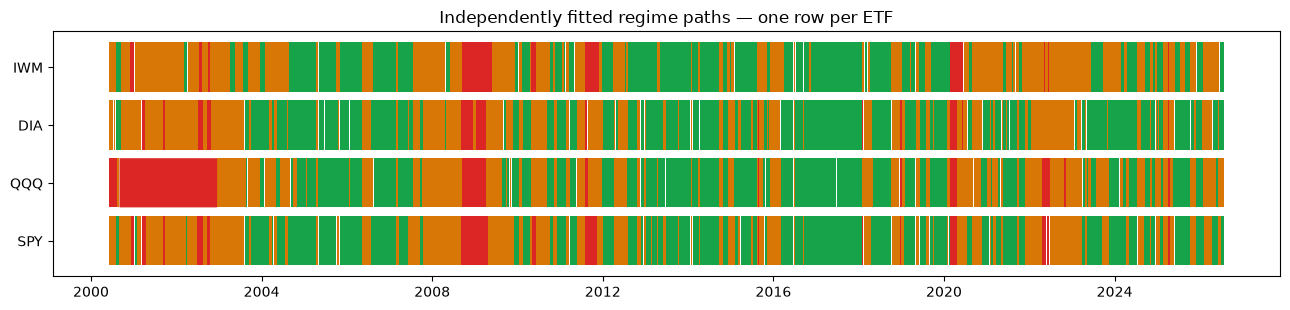

In [15]:
paths = pd.DataFrame(regime_paths).dropna()
agreement = pd.DataFrame(
    {a: {b: float((paths[a] == paths[b]).mean()) for b in paths.columns} for a in paths.columns}
)
print(f"Share of days two ETFs are called the same regime ({len(paths):,} common days):")
print(agreement.round(3))

fig, ax = plt.subplots(figsize=(13, 3.2))
for row, symbol in enumerate(paths.columns):
    for name in LABEL_ORDER:
        mask = (paths[symbol] == name).to_numpy()
        ax.fill_between(paths.index, row, row + 0.85, where=mask,
                        color=LABEL_COLORS[name], lw=0)
ax.set_yticks(np.arange(len(paths.columns)) + 0.42, paths.columns)
ax.set_title("Independently fitted regime paths — one row per ETF")
ax.grid(False)
plt.tight_layout()
plt.show()

The same three states appear in every ETF, in the same order and with the same sign pattern: a
low-volatility state carrying the positive drift, a mid-volatility state with none, and a
high-volatility state with severely negative drift. The four independently fitted paths line up
visually and agree on the large majority of days.

The differences are the ones you'd predict rather than anomalies — QQQ's Bear state is larger and
longer-lived (the dot-com bust is a NASDAQ event, not an S&P one), and IWM's states are all
higher-volatility.

**SPY is sufficient as the primary model.** The others confirm the taxonomy generalizes; they
don't require separate treatment unless you're allocating between them.

### The four regime histories

The table says the taxonomy replicates. These say it more convincingly: each ETF's own independently
fitted regimes, shaded under its own price. If the model were fitting noise, the shading would look
arbitrary; instead the Bear blocks land on the same handful of episodes in every panel, and the
differences between panels are the ones a market participant would predict.

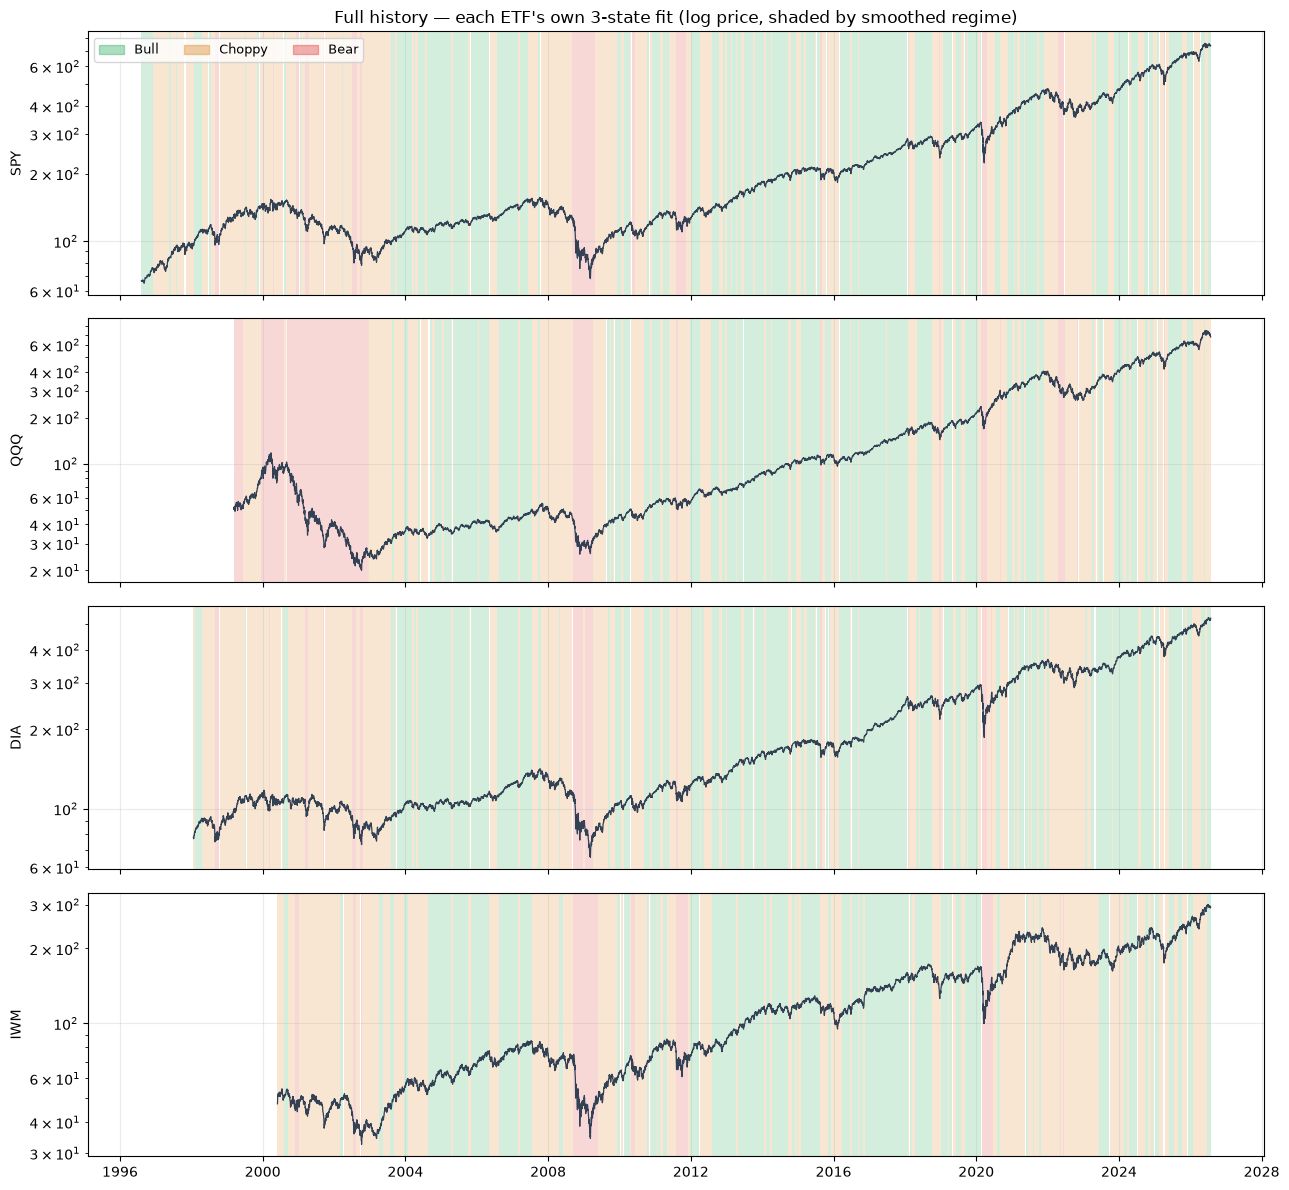

In [16]:
def plot_regime_history(axis, frame: pd.DataFrame, symbol: str, log_scale: bool = True) -> None:
    """Price shaded by most-likely regime, on whatever date window `frame` covers."""
    axis.plot(frame.index, frame["close"], color="#334155", lw=0.9)
    if log_scale:
        axis.set_yscale("log")
    low, high = axis.get_ylim()
    for name in LABEL_ORDER:
        axis.fill_between(frame.index, low, high, where=(frame["regime"] == name).to_numpy(),
                          color=LABEL_COLORS[name], alpha=0.18, lw=0)
    axis.set_ylim(low, high)
    axis.set_ylabel(symbol)


fig, axes = plt.subplots(len(cross_asset_frames), 1, figsize=(13, 12), sharex=True)
for axis, (symbol, frame) in zip(axes, cross_asset_frames.items()):
    plot_regime_history(axis, frame, symbol)
axes[0].set_title("Full history — each ETF's own 3-state fit (log price, shaded by smoothed regime)")
handles = [plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS[n], alpha=0.35) for n in LABEL_ORDER]
axes[0].legend(handles, LABEL_ORDER, loc="upper left", ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

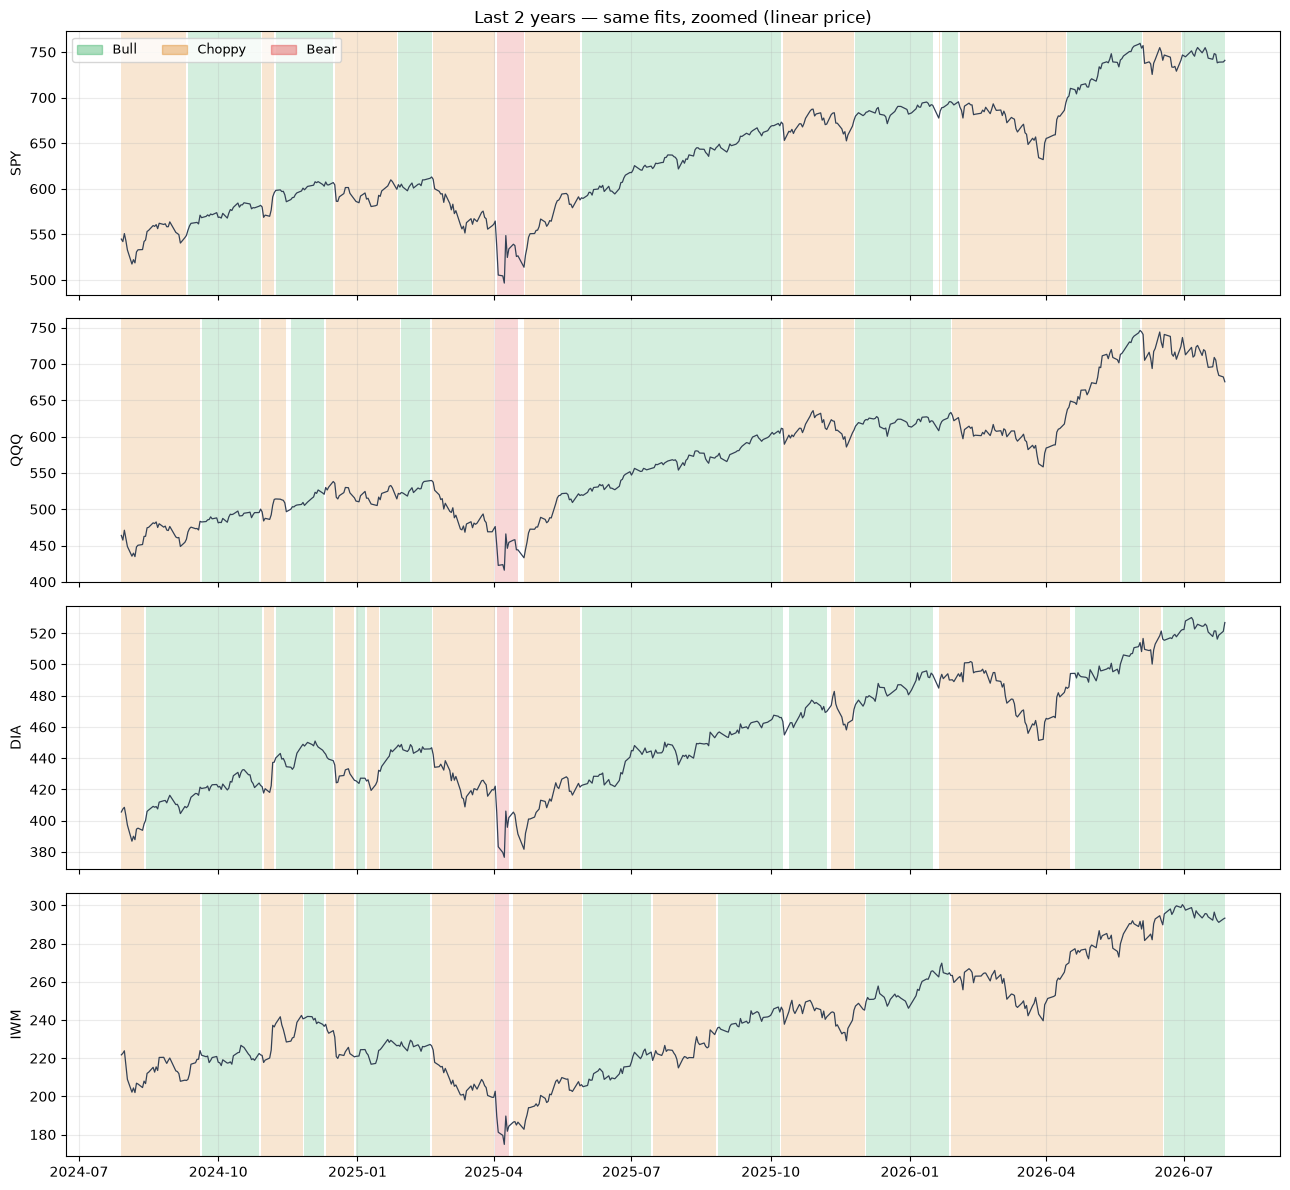

Share of the last 2 years spent in each regime:
          SPY    QQQ    DIA    IWM
regime                            
Bull    0.533  0.413  0.627  0.381
Choppy  0.443  0.563  0.359  0.603
Bear    0.024  0.024  0.014  0.016

Most recent regime call, and how long it has been in force:
  SPY  Bull     for  20 trading days   (as of 2026-07-28)
  QQQ  Choppy   for  38 trading days   (as of 2026-07-28)
  DIA  Bull     for  28 trading days   (as of 2026-07-28)
  IWM  Bull     for  27 trading days   (as of 2026-07-28)


In [17]:
ZOOM_YEARS = 2

zoom_start = max(f.index.max() for f in cross_asset_frames.values()) - pd.DateOffset(years=ZOOM_YEARS)

fig, axes = plt.subplots(len(cross_asset_frames), 1, figsize=(13, 12), sharex=True)
for axis, (symbol, frame) in zip(axes, cross_asset_frames.items()):
    plot_regime_history(axis, frame.loc[frame.index >= zoom_start], symbol, log_scale=False)
axes[0].set_title(f"Last {ZOOM_YEARS} years — same fits, zoomed (linear price)")
axes[0].legend(handles, LABEL_ORDER, loc="upper left", ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

recent = pd.DataFrame({
    symbol: frame.loc[frame.index >= zoom_start, "regime"].value_counts(normalize=True)
    for symbol, frame in cross_asset_frames.items()
}).reindex(LABEL_ORDER).fillna(0.0)
print(f"Share of the last {ZOOM_YEARS} years spent in each regime:")
print(recent.round(3).to_string())

print("\nMost recent regime call, and how long it has been in force:")
for symbol, frame in cross_asset_frames.items():
    regimes = frame["regime"]
    current = regimes.iloc[-1]
    run_length = (regimes != regimes.shift()).cumsum().iloc[-1]
    days = int((regimes.groupby((regimes != regimes.shift()).cumsum()).size()).loc[run_length])
    print(f"  {symbol:<4} {current:<8} for {days:>3} trading days   "
          f"(as of {frame.index[-1]:%Y-%m-%d})")

The zoom is where the model earns or loses trust, because it is the only window whose outcome you
already know from memory rather than from the chart. Two things to check when reading it: whether the
Bear shading arrives before or after the drawdown it is supposed to mark, and whether the four ETFs
agree at the edges of an episode or drift apart.

**A caveat that matters more here than anywhere else in the notebook.** These are *smoothed*
probabilities — they use the whole sample including everything after each date, which is exactly what
you want for describing history and exactly what you cannot have in real time. The right-hand edge of
these charts is therefore the least trustworthy part of them: today's smoothed label will be revised
as more data arrives. Part 11 onward uses causally filtered probabilities for anything that pretends
to be a decision.

## Part 11 — Out-of-sample: walk both models forward

Everything above is in-sample, including Part 9's verdict on the VOL Regime Index. Better *fit* is
not better *forecasting*, and the extra 6 parameters have to earn their place against data they
were not shown. Two separate leaks have to be closed:

1. **Smoothed probabilities use future data.** Use *filtered* probabilities, which condition only
   on data up to $t$.
2. **The parameters were fit on the whole sample.** Refit on an expanding window and only apply
   parameters to years after the ones they were estimated on.

So we refit **both** models annually on all history to date and filter the following year with
those frozen parameters. The TVTP refit is seeded from that same year's constant-transition fit,
exactly as in Part 9, so the comparison is between two models estimated the same way.

The primary scoring rule is the **one-step-ahead predictive log-likelihood**: the Hamilton filter's
`llf_obs[t]` is the log density of $r_t$ given everything before it, so summing it over an out-of-sample year
scores how well the model predicted each day's return *distribution* before seeing it. That is a
cleaner test than any trading rule, because it doesn't depend on how probabilities get turned into
positions.

In [18]:
BURN_IN_YEARS = 6
WALK_FORWARD_REPS = 6  # fewer restarts than the headline fit; the seeded TVTP refit needs none

full_models = {
    "constant": MarkovRegression(returns, k_regimes=N_STATES, trend="c", switching_variance=True),
    "index-driven": MarkovRegression(returns, k_regimes=N_STATES, trend="c",
                                     switching_variance=True, exog_tvtp=tvtp_exog),
}
daily_log_score = {name: [] for name in full_models}
filtered_paths = {name: [] for name in full_models}
state_sigma = {name: [] for name in full_models}   # that year's fitted sd per state, used in Part 12
years = sorted(spy.index.year.unique())

for year in years:
    if year - years[0] < BURN_IN_YEARS:
        continue
    train = returns[returns.index.year < year]
    base_fit = fit_markov(train, search_reps=WALK_FORWARD_REPS)
    train_tvtp = MarkovRegression(train, k_regimes=N_STATES, trend="c",
                                  switching_variance=True, exog_tvtp=tvtp_exog[:len(train)])
    tvtp_fit = train_tvtp.fit(start_params=tvtp_start_params(train_tvtp, base_fit),
                              search_reps=0, maxiter=400, disp=False)

    # Frozen parameters applied to the whole series; the Hamilton filter is causal, so anything
    # inside `year` only ever uses data up to that point.
    in_year = np.asarray(returns.index.year == year)
    dates = returns.index[in_year]
    for name, fit in (("constant", base_fit), ("index-driven", tvtp_fit)):
        filtered = full_models[name].filter(fit.params)
        daily_log_score[name].append(pd.Series(np.asarray(filtered.llf_obs)[in_year], index=dates))
        probabilities = pd.DataFrame(np.asarray(filtered.filtered_marginal_probabilities),
                                     index=returns.index)
        lbl = label_states(fit)
        filtered_paths[name].append(
            probabilities[[lbl[n] for n in LABEL_ORDER]].set_axis(LABEL_ORDER, axis=1)[in_year]
        )
        fitted_sd = state_params(fit)["sd"]
        state_sigma[name].append(
            pd.DataFrame({n: fitted_sd[lbl[n]] for n in LABEL_ORDER}, index=dates)
        )
    print(year, end=" ", flush=True)

log_score = pd.DataFrame({name: pd.concat(parts) for name, parts in daily_log_score.items()})
log_score["advantage"] = log_score["index-driven"] - log_score["constant"]
walk_forward = {name: pd.concat(parts) for name, parts in filtered_paths.items()}
walk_forward_sigma = {name: pd.concat(parts) for name, parts in state_sigma.items()}
print(f"\n\n{len(log_score):,} out-of-sample days, "
      f"{log_score.index.min():%Y-%m-%d} .. {log_score.index.max():%Y-%m-%d}")

2002 

2003 

2004 

2005 

2006 

...

2024 

/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2025 

2026 



6,181 out-of-sample days, 2002-01-02 .. 2026-07-28


Out-of-sample predictive log-likelihood by year (higher = better):
      constant  index-driven  advantage
date                                   
2002    -473.8        -473.4        0.4
2003    -367.6        -357.1       10.5
2004    -294.8        -285.7        9.1
2005    -254.7        -255.0       -0.3
2006    -243.3        -246.2       -2.9
2007    -335.3        -337.8       -2.5
2008    -579.2        -571.2        8.1
2009    -465.4        -469.0       -3.6
2010    -366.5        -381.1      -14.6
2011    -412.0        -410.0        2.0
2012    -302.5        -300.0        2.5
2013    -264.5        -261.3        3.2
2014    -259.9        -257.5        2.4
2015    -336.5        -332.1        4.4
2016    -278.6        -271.8        6.8
2017    -168.0        -165.6        2.5
2018    -326.3        -330.3       -4.0
2019    -273.2        -268.2        5.0
2020    -459.9        -453.5        6.4
2021    -299.8        -290.8        9.0
2022    -477.0        -483.1       -6.1
2023    -312.

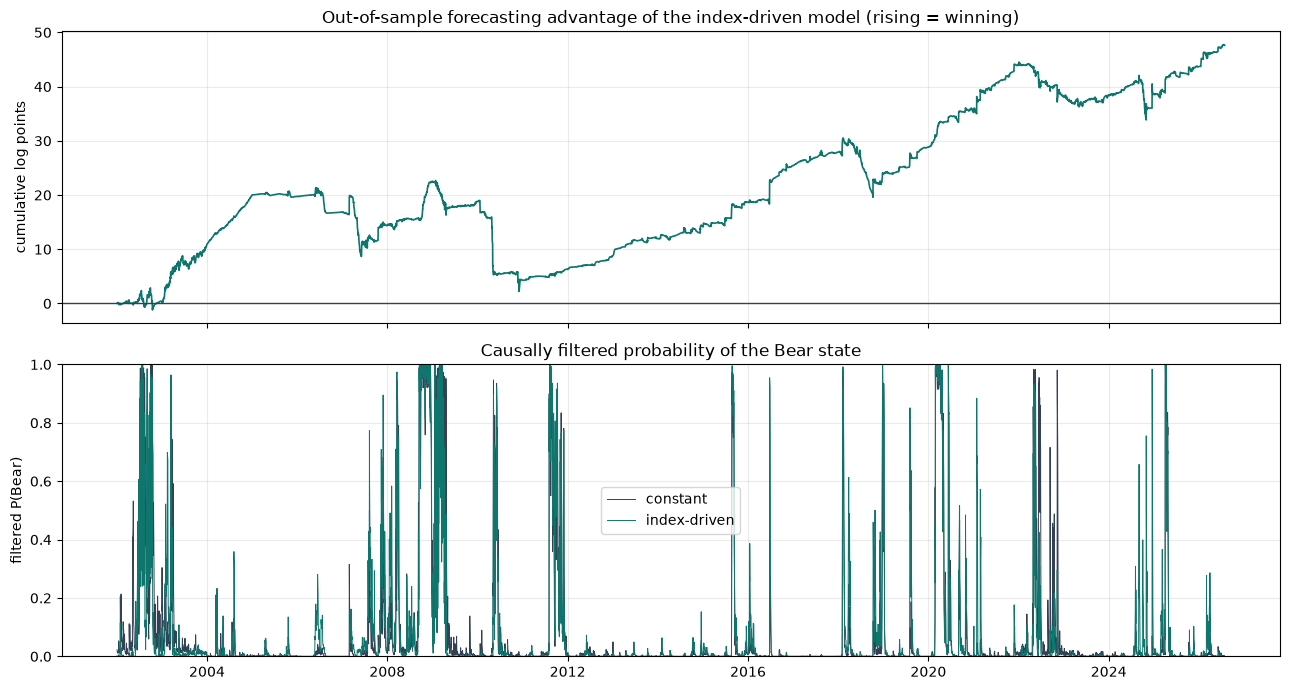

In [19]:
import statsmodels.api as sm

annual = log_score.groupby(log_score.index.year).sum()
print("Out-of-sample predictive log-likelihood by year (higher = better):")
print(annual.round(1).to_string())

total_advantage = log_score["advantage"].sum()
better = int((annual["advantage"] > 0).sum())
# Diebold-Mariano: is the mean daily log-score difference distinguishable from zero?
# HAC standard errors because log scores are serially correlated within volatility clusters.
dm = sm.OLS(log_score["advantage"].to_numpy(), np.ones(len(log_score))).fit(
    cov_type="HAC", cov_kwds={"maxlags": 21})
print(f"\ntotal advantage : {total_advantage:+.1f} log points over {len(log_score):,} days")
print(f"years favouring the index model: {better}/{len(annual)}")
print(f"Diebold-Mariano  : t = {dm.tvalues[0]:.2f}, p = {dm.pvalues[0]:.4f} (HAC, 21 lags)")

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True, height_ratios=[1, 1])
ax[0].plot(log_score.index, log_score["advantage"].cumsum(), color="#0f766e", lw=1.2)
ax[0].axhline(0, color="#334155", lw=1)
ax[0].set_ylabel("cumulative log points")
ax[0].set_title("Out-of-sample forecasting advantage of the index-driven model (rising = winning)")

for name, color in (("constant", "#334155"), ("index-driven", "#0f766e")):
    ax[1].plot(walk_forward[name].index, walk_forward[name][BEAR], lw=0.7, color=color, label=name)
ax[1].set_ylabel(f"filtered P({BEAR})")
ax[1].set_ylim(0, 1)
ax[1].legend()
ax[1].set_title("Causally filtered probability of the Bear state")
plt.tight_layout()
plt.show()

In [20]:
TERCILE_LABELS = ["calm", "middle", "stressed"]

level = pd.qcut(spy.loc[log_score.index, "vol_regime_index"], 3, labels=TERCILE_LABELS)
by_level = log_score.groupby(level, observed=True)["advantage"].agg(["count", "sum", "mean"])
by_level.columns = ["days", "total_advantage", "per_day"]
by_level["per_100_days"] = by_level["per_day"] * 100
print("Where the forecasting advantage comes from, by VOL Regime Index tercile:")
print(by_level.drop(columns="per_day").round(2).to_string())

Where the forecasting advantage comes from, by VOL Regime Index tercile:
                  days  total_advantage  per_100_days
vol_regime_index                                     
calm              2061            32.98          1.60
middle            2060           -28.79         -1.40
stressed          2060            43.44          2.11


### The index does forecast better, out of sample

The advantage curve climbs, and the Diebold-Mariano test on the daily log-score differences says
it is not an artifact of one or two lucky years.

The tercile table shows where it comes from, and it confirms the Part 9 mechanism cleanly: the
advantage is **concentrated at both extremes of the index and is negative in the middle**. When the
index is very calm or very stressed it is making a strong statement about how persistent the current
state is, and a model able to act on that wins. Mid-range, the index says little, and six extra
parameters cost slightly more than they return.

Read the annual column honestly alongside it: the gains do *not* arrive in crises specifically. The
largest come from 2002-2004, the 2008 and 2020 gains are real but ordinary-sized, and there are
genuine losing years — 2010 worst by a distance, and 2022 also negative. Stressed *days* pay; stressed
*years* are not reliably the good ones.

This is the result Part 9 could not deliver. In-sample, extra parameters always fit better; here
the index-driven transition matrix predicts tomorrow's return distribution better using only
information available at the time, with parameters estimated on prior years alone.

### Does it make a better trading signal, though?

Separate question, and the answer is less flattering. Below, both probability paths are turned
into positions the same crude way, and scored against buy-and-hold.

                          annualized_return_%  annualized_vol_%  sharpe  \
buy & hold                               7.58             19.00    0.40   
constant transitions                     7.12             14.18    0.50   
index-driven transitions                 6.84             14.31    0.48   

                          max_drawdown_%  
buy & hold                        -56.47  
constant transitions              -35.76  
index-driven transitions          -39.05  

Same-day return by the state each filter called, using only prior information:

  constant:
        count  mean  annualized_%
Bull     3180  0.08         20.20
Choppy   2607 -0.01         -1.92
Bear      393 -0.13        -31.51

  index-driven:
        count  mean  annualized_%
Bull     3159  0.08         19.59
Choppy   2658  0.00          1.21
Bear      363 -0.20        -50.33


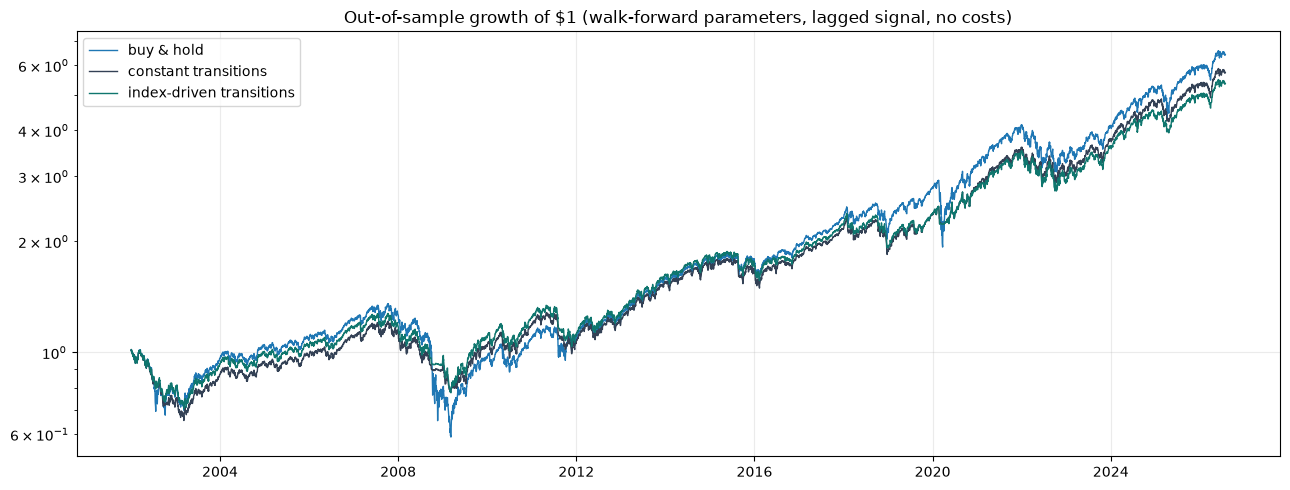

In [21]:
# Naive use of the signal: exposure = yesterday's filtered P(not Bear). No costs, no leverage.
# ponytail: deliberately the crudest possible mapping from probability to position, held identical
# across models so the comparison is about the probabilities and not about position sizing.
oos = spy.copy()
for name, path in walk_forward.items():
    oos = oos.join(path.add_prefix(f"{name}|"))
oos = oos.dropna(subset=[f"{name}|{BEAR}" for name in walk_forward])

for name in walk_forward:
    oos[f"{name}|exposure"] = (1 - oos[f"{name}|{BEAR}"]).shift(1)
oos = oos.dropna(subset=[f"{name}|exposure" for name in walk_forward])


def performance(series: pd.Series) -> dict:
    annual_return = series.mean() * TRADING_DAYS
    annual_vol = series.std() * np.sqrt(TRADING_DAYS)
    curve = (series / RETURN_SCALE).cumsum().apply(np.exp)
    return {
        "annualized_return_%": annual_return,
        "annualized_vol_%": annual_vol,
        "sharpe": annual_return / annual_vol,
        "max_drawdown_%": ((curve / curve.cummax()) - 1).min() * RETURN_SCALE,
    }


scoreboard = {"buy & hold": performance(oos["ret"])}
for name in walk_forward:
    scoreboard[f"{name} transitions"] = performance(oos[f"{name}|exposure"] * oos["ret"])
print(pd.DataFrame(scoreboard).T.round(2))

print("\nSame-day return by the state each filter called, using only prior information:")
for name in walk_forward:
    called = oos[[f"{name}|{s}" for s in LABEL_ORDER]].idxmax(axis=1).str.split("|").str[-1]
    table = oos.groupby(called)["ret"].agg(["count", "mean"])
    table["annualized_%"] = table["mean"] * TRADING_DAYS
    print(f"\n  {name}:")
    print(table.reindex(LABEL_ORDER).round(2).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(oos.index, (oos["ret"] / RETURN_SCALE).cumsum().apply(np.exp), label="buy & hold", lw=1)
for name, color in (("constant", "#334155"), ("index-driven", "#0f766e")):
    strategy = oos[f"{name}|exposure"] * oos["ret"]
    ax.plot(oos.index, (strategy / RETURN_SCALE).cumsum().apply(np.exp),
            label=f"{name} transitions", lw=1, color=color)
ax.set_yscale("log")
ax.set_title("Out-of-sample growth of $1 (walk-forward parameters, lagged signal, no costs)")
ax.legend()
plt.tight_layout()
plt.show()

### What the out-of-sample results say

Three findings, and they do not all point the same way.

**1. The regime structure is real.** Both filters, using only past information, sort same-day
returns strongly positive → flat → strongly negative. Nothing here depends on smoothing.

**2. The VOL Regime Index genuinely improves the model.** It wins on out-of-sample predictive
log-likelihood, in a majority of years, with a significant Diebold-Mariano statistic. Note *where*
that improvement is and isn't visible: it is a **density** improvement. The two models' state calls
sort forward returns almost identically — the index-driven one is a little more selective about Bear
and separates Bull from Choppy slightly better, but the Bear days it picks are not more severe. If
you only look at "what did the model call today", you will not see the gain at all.

**3. It does not improve this trading rule.** Run through `exposure = 1 - P(Bear)`, the
index-driven model scores slightly *worse* than the constant-transition one on Sharpe and
drawdown, despite forecasting better.

That combination is not a contradiction, and it's worth being precise about why. A better density
forecast is a statement about the whole distribution of tomorrow's return; `1 - P(Bear)` collapses
that distribution into a single scalar and throws away everything else — including the variance
forecast, which is where a regime model earns most of its keep. And because the index-driven model's
transition matrix reacts to the index, its state probabilities move on days the constant model's
cannot, which shifts entry and exit timing for better *and* worse.

The honest reading: **the index earns its place in the model on forecasting grounds, but not — on
this evidence — in the strategy.** Whether that is the fault of the position rule is exactly what
Part 12 tests. A rule that used the full state vector (sizing on
P(Bull) versus P(Choppy) rather than only P(Bear)) might collect what this one cannot. Part 12
tests exactly that, net of costs.

Caveats unchanged: price returns rather than total returns, and parameters refit annually rather
than continuously. Transaction costs are no longer waved away — Part 12 charges them.

## Part 12 — Position sizing: spending the forecast

Part 11 ended with the position rule as the binding constraint. `exposure = 1 - P(Bear)` reads one
number out of a three-number forecast and gives Bull and Choppy the same weight, despite one
carrying roughly +30 %/yr and the other about zero.

The rule tested here uses the whole state vector, and is **long-only**: the Bear term is a brake
down to flat, never a reversal into a short.

$$\text{position}_t \;=\; \max\!\Big(0,\;\; 1 \cdot P(\text{Bull}) \;+\; 0.5 \cdot P(\text{Choppy}) \;-\; 1 \cdot P(\text{Bear})\Big)$$

### Does the logic hold up?

**Yes, and the floor at zero is doing real work.** Probabilities sum to one, so the position is
bounded in $[0, 1]$ — no leverage, no shorting. The weights are monotone in how good the state is;
Bull is worth full exposure, Choppy half, and Bear actively cancels the other two rather than
merely being ignored. That last property is the difference between "stand aside when Bear is
likely" and "stand aside only when Bear is certain".

Two things to check, stated before the results:

1. **Turnover.** A continuously varying position trades far more than one that mostly sits near 1,
   so everything below is also shown net of a per-unit-turnover charge.
2. **Whether the Bear term earns its keep at all**, given the floor. Once clipped, it only binds
   when $P(\text{Bear})$ exceeds the weight coming from the other two states. The `1 / 0.5 / 0`
   variant — same rule with the Bear term simply dropped — is included to isolate that.

The un-floored version that *does* short is kept below as a counterfactual, because it is the
clearest evidence that the floor was the right call.

In [22]:
COST_BPS = 5.0  # charged on |change in position|; generous for SPY

LEGACY_WEIGHTS = {BULL: 1.0, CHOPPY: 1.0, BEAR: 0.0}   # identical to 1 - P(Bear)
WEIGHTS = {BULL: 1.0, CHOPPY: 0.5, BEAR: -1.0}         # the specified rule, floored at 0 below
NO_BEAR_WEIGHTS = {BULL: 1.0, CHOPPY: 0.5, BEAR: 0.0}  # same, with the Bear term dropped entirely


def size_positions(probabilities: pd.DataFrame, weights: dict[str, float],
                   floor: float | None = 0.0) -> pd.Series:
    """Weighted sum of state probabilities, floored, then lagged a day (trade on yesterday's close)."""
    weighted = sum(weights[state] * probabilities[state] for state in LABEL_ORDER)
    if floor is not None:
        weighted = weighted.clip(lower=floor)
    return weighted.shift(1).fillna(0.0)


def evaluate(position: pd.Series, returns_pct: pd.Series, cost_bps: float = 0.0) -> dict:
    """Performance of a position series, optionally net of per-unit-turnover costs."""
    turnover = position.diff().abs().fillna(position.abs())
    net = position * returns_pct - turnover * cost_bps / 100.0
    annual_return = net.mean() * TRADING_DAYS
    annual_vol = net.std() * np.sqrt(TRADING_DAYS)
    curve = (net / RETURN_SCALE).cumsum().apply(np.exp)
    return {
        "annualized_return_%": annual_return,
        "annualized_vol_%": annual_vol,
        "sharpe": annual_return / annual_vol,
        "max_drawdown_%": ((curve / curve.cummax()) - 1).min() * RETURN_SCALE,
        "turnover_per_year": turnover.sum() / (len(position) / TRADING_DAYS),
        "average_position": position.mean(),
    }


rules = {
    "1 - P(Bear)": LEGACY_WEIGHTS,
    "1 / 0.5 / -1, floored at 0": WEIGHTS,
    "1 / 0.5 / 0": NO_BEAR_WEIGHTS,
}

scoreboard = {"buy & hold": evaluate(pd.Series(1.0, index=oos.index), oos["ret"])}
for name, path in walk_forward.items():
    aligned = path.reindex(oos.index)
    for rule_name, weights in rules.items():
        position = size_positions(aligned, weights)
        scoreboard[f"{name} — {rule_name}"] = evaluate(position, oos["ret"])
        if rule_name != "1 - P(Bear)":
            scoreboard[f"{name} — {rule_name}, net {COST_BPS:.0f}bp"] = evaluate(
                position, oos["ret"], COST_BPS)

pd.DataFrame(scoreboard).T.round(2)

,annualized_return_%,annualized_vol_%,sharpe,max_drawdown_%,turnover_per_year,average_position
buy & hold,7.58,19.00,0.40,-56.47,0.04,1.00
constant — 1 - P(Bear),7.08,14.18,0.50,-35.76,5.44,0.93
"constant — 1 / 0.5 / -1, floored at 0",4.79,9.33,0.51,-23.21,11.25,0.69
"constant — 1 / 0.5 / -1, floored at 0, net 5bp",4.22,9.33,0.45,-24.09,11.25,0.69
constant — 1 / 0.5 / 0,4.88,9.78,0.50,-25.77,10.42,0.72
"constant — 1 / 0.5 / 0, net 5bp",4.36,9.78,0.45,-26.49,10.42,0.72
index-driven — 1 - P(Bear),6.80,14.31,0.47,-39.05,6.69,0.93
"index-driven — 1 / 0.5 / -1, floored at 0",4.52,9.38,0.48,-23.79,11.83,0.69
"index-driven — 1 / 0.5 / -1, floored at 0, net 5bp",3.92,9.38,0.42,-24.73,11.83,0.69
index-driven — 1 / 0.5 / 0,4.83,9.86,0.49,-25.52,10.95,0.72


### It works — as a risk reduction, not a return improvement

The specified rule earns **about the same Sharpe as `1 - P(Bear)` while taking roughly a third less
volatility and a third less drawdown.** Average exposure falls from ~0.9 to ~0.7, and the return
falls with it, but the risk falls faster. On a risk-adjusted basis it is a wash against the old
rule; on an absolute-risk basis it is clearly better, and it is the more sensible object to lever
up or size into a portfolio.

Compare it against `1 / 0.5 / 0` — the same rule with the Bear term dropped — and the two are close.
That is worth understanding rather than glossing: once floored at zero, the Bear term only binds on
days when $P(\text{Bear})$ is large enough to overcome the Bull and Choppy weight, which is a small
minority of days. It is doing something, but most of this rule's improvement comes from
**de-weighting Choppy**, not from the Bear brake.

Costs matter here in a way they didn't before: turnover roughly doubles versus `1 - P(Bear)`, so the
5bp charge takes several points of Sharpe. It survives, but it is no longer free.

In [23]:
reference = walk_forward["index-driven"].reindex(oos.index)
legs = {
    "P(Bull) only              (1, 0, 0)": (NO_BEAR_WEIGHTS | {CHOPPY: 0.0}, 0.0),
    "+ half weight on Choppy   (1, 0.5, 0)": (NO_BEAR_WEIGHTS, 0.0),
    "+ Bear brake, floored     (1, 0.5, -1)+": (WEIGHTS, 0.0),
    "  ... same, unfloored (shorts)": (WEIGHTS, None),
}
print("Building the rule up one leg at a time (index-driven probabilities, gross):")
print(pd.DataFrame({name: evaluate(size_positions(reference, w, floor=f), oos["ret"])
                    for name, (w, f) in legs.items()}).T.round(2).to_string())

short_leg = size_positions(reference, {BULL: 0.0, CHOPPY: 0.0, BEAR: -1.0}, floor=None)
print("\nThe short leg on its own (why the floor matters):")
print(pd.Series(evaluate(short_leg, oos["ret"])).round(2).to_string())

called_bear = oos[reference.idxmax(axis=1) == BEAR]
elsewhere = reference.loc[~reference.index.isin(called_bear.index), BEAR]
print(f"\nOn the {len(called_bear)} days the filter actually called {BEAR}:")
print(f"  mean return   {called_bear['ret'].mean():+.3f}%   (so the direction is right)")
print(f"  daily sd      {called_bear['ret'].std():.2f}%")
print(f"  best day      {called_bear['ret'].max():+.2f}%    worst day {called_bear['ret'].min():+.2f}%")
print(f"  mean P({BEAR})  {reference.loc[called_bear.index, BEAR].mean():.2f}")
print(f"\nMean P({BEAR}) on all other days: {elsewhere.mean():.3f} — small, but positive nearly always,")
print("which is exactly what an unfloored short leg would be trading on.")

Building the rule up one leg at a time (index-driven probabilities, gross):
                                         annualized_return_%  annualized_vol_%  sharpe  max_drawdown_%  turnover_per_year  average_position
P(Bull) only              (1, 0, 0)                     2.87              7.16    0.40          -16.70              15.50              0.51
+ half weight on Choppy   (1, 0.5, 0)                   4.83              9.86    0.49          -25.52              10.95              0.72
+ Bear brake, floored     (1, 0.5, -1)+                 4.52              9.38    0.48          -23.79              11.83              0.69
  ... same, unfloored (shorts)                          4.10             13.83    0.30          -26.18              17.49              0.65

The short leg on its own (why the floor matters):
annualized_return_%    -0.74
annualized_vol_%       10.73
sharpe                 -0.07
max_drawdown_%        -41.92
turnover_per_year       6.65
average_position       -0.07


On the 363 days the filter actually called Bear:
  mean return   -0.200%   (so the direction is right)
  daily sd      3.35%
  best day      +13.56%    worst day -11.59%
  mean P(Bear)  0.82

Mean P(Bear) on all other days: 0.027 — small, but positive nearly always,
which is exactly what an unfloored short leg would be trading on.


### Why the floor was the right call

The unfloored version of the same rule — the one that actually shorts — is materially worse: more
volatility, worse drawdown, lower return. And the short leg *on its own* loses money outright, with
a drawdown around 40% to show for it.

That is counterintuitive, because the days the filter calls Bear genuinely do have a negative mean
return. Two things break a short anyway:

1. **You are never fully short when it counts, and almost always slightly short when it doesn't.**
   P(Bear) averages ~0.8 on days actually called Bear, but it is small and *positive* on nearly
   every other day, so an unfloored leg carries a permanent little short through every recovery.
2. **The Bear state holds the best days as well as the worst.** Its daily standard deviation is
   ~3 %, and Part 8 found its returns are the most negatively autocorrelated of any state — the
   signature of violent two-way action. Short a bear regime and you collect the crashes *and* the
   snapbacks. Over 2002-2026 the snapbacks won.

Shorting a high-variance, sharply mean-reverting state with a partial, slow-moving position is close
to a worst case: you carry the variance without reliably capturing the drift. Clipping at zero
keeps the useful half of the signal — stand aside — and discards the half that doesn't work.

### One more rule: size on the predicted variance

Part 11's finding was that the index improves the predicted *distribution*, and its width is what
every rule so far has ignored. The model provides it directly — predicted variance is
$\sum_i P_i(t)\,\sigma_i^2$ — so target constant predicted risk instead of choosing weights by
hand. Each year's own fitted $\sigma_i$ are used, keeping this walk-forward clean.

In [24]:
VOL_TARGETS = (10.0, 12.0)  # annualized %, roughly half to two-thirds of SPY's own volatility
MAX_POSITION = 1.0          # long-only, no leverage: this is about sizing, not gearing

vol_targeted = {}
for name in walk_forward:
    probabilities = walk_forward[name].reindex(oos.index)
    sigmas = walk_forward_sigma[name].reindex(oos.index)
    predicted_vol = np.sqrt((probabilities * sigmas ** 2).sum(axis=1)) * np.sqrt(TRADING_DAYS)
    for target in VOL_TARGETS:
        position = (target / predicted_vol).clip(upper=MAX_POSITION).shift(1).fillna(0)
        vol_targeted[f"{name} — vol target {target:.0f}%"] = evaluate(position, oos["ret"])
        vol_targeted[f"{name} — vol target {target:.0f}%, net {COST_BPS:.0f}bp"] = evaluate(
            position, oos["ret"], COST_BPS)

pd.DataFrame(vol_targeted).T.round(2)

,annualized_return_%,annualized_vol_%,sharpe,max_drawdown_%,turnover_per_year,average_position
constant — vol target 10%,4.53,9.77,0.46,-29.29,8.40,0.69
"constant — vol target 10%, net 5bp",4.11,9.77,0.42,-29.76,8.40,0.69
constant — vol target 12%,5.28,11.19,0.47,-33.37,7.47,0.77
"constant — vol target 12%, net 5bp",4.90,11.19,0.44,-33.88,7.47,0.77
index-driven — vol target 10%,4.36,9.62,0.45,-29.56,8.64,0.68
"index-driven — vol target 10%, net 5bp",3.92,9.62,0.41,-30.02,8.64,0.68
index-driven — vol target 12%,5.11,11.06,0.46,-33.99,7.95,0.77
"index-driven — vol target 12%, net 5bp",4.71,11.06,0.43,-34.49,7.95,0.77


### The verdict on sizing

**Your rule does what it was meant to do.** Floored at zero it matches `1 - P(Bear)` on Sharpe
while running about a third less volatility and a third less drawdown — a better-behaved object,
even though it isn't a higher risk-adjusted return. Most of that gain comes from de-weighting
Choppy; the Bear brake contributes a little, and the decision *not* to short is worth more than
either.

**But the index-driven model still does not beat the constant-transition one on P&L.** Not under
the specified rule, not under `1 / 0.5 / 0`, and not under volatility targeting — the two run
essentially neck and neck everywhere, and the constant model is marginally ahead in several cells.
Volatility targeting was the most likely candidate to convert Part 11's density advantage into
return, since it is the only rule that consumes the variance forecast, and it does not.

That is worth stating plainly rather than burying: **the index's forecasting advantage is
statistically real (p ≈ 0.002) and economically invisible in directional spot sizing.** The most
likely explanation is that the improvement is concentrated in the *shape and width* of the predicted
distribution, and a long-only spot position can only ever express the mean. Instruments whose payoff
is in variance — options, variance swaps, VIX futures — are where a density edge would show up, and
none of them are testable with the data in this notebook.

| Rule | Verdict |
|---|---|
| `1 - P(Bear)` | Highest Sharpe, but ~0.9 exposure throughout and a 35 %+ drawdown |
| `1 / 0.5 / -1` floored at 0 | **Same Sharpe, about a third less volatility and drawdown.** The best-behaved rule |
| `1 / 0.5 / 0` | Nearly identical — most of the benefit is the Choppy de-weighting, not the Bear brake |
| `1 / 0.5 / -1` unfloored | Clearly worse. Shorting the Bear state loses money |
| Volatility targeting | Cleanest use of the model; no better than the hand-set weights, and no index edge |

Two takeaways: **don't short the Bear state — use it to stand aside**, and **the Choppy state is
where the sizing gain lives**, because it is the only state where the old rule was demonstrably
wrong.

## Part 13 — Volatility targeting, done properly

Part 12 targeted volatility using the regime mixture, $\sigma_t = \sqrt{\sum_i P_i(t)\,\sigma_i^2}$,
and it was unremarkable. That raises a fair question: is volatility targeting the wrong idea, or was
the *forecast* the weak link? The regime model is not the only volatility forecast available — the
raw index figures are right there.

Four candidates, all computable from what this notebook already has:

| Forecast | What it is | Character |
|---|---|---|
| **Regime mixture** | $\sqrt{\sum_i P_i \sigma_i^2}$ from the HMM | Forward-looking, but only three discrete levels |
| **Trailing realized** | 21-day rolling standard deviation | Backward-looking, continuous, free |
| **VIX, raw** | 30-day implied volatility, already annualized | Forward-looking and market-priced, but biased |
| **VIX, de-biased** | VIX × trailing realized/implied ratio | Corrects the variance risk premium |

The bias in raw VIX matters and is not a detail. Implied volatility trades persistently above
subsequent realized volatility — the variance risk premium, the compensation option sellers demand.
Feed raw VIX into `target / forecast` and you will systematically under-invest, because the forecast
is systematically too high. The de-biased version rescales it by the ratio actually observed in a
trailing window.

First: which one is the best forecast? Score each against the realized volatility of the *following*
21 days.

In [25]:
VOL_FORECAST_HORIZON = 21
VOL_TARGET = 10.0            # annualized %, the risk budget the position is sized to hold
IMPLIED_RATIO_WINDOW = 252   # trailing window for the realized/implied correction

annualize = np.sqrt(TRADING_DAYS)
returns_oos = oos["ret"]

# The variance the model implies, using each walk-forward year's own fitted sigmas.
regime_probs = walk_forward["index-driven"].reindex(oos.index)
regime_sigmas = walk_forward_sigma["index-driven"].reindex(oos.index)

realized_trailing = spy["ret"].rolling(VOL_FORECAST_HORIZON).std() * annualize
implied_realized_ratio = (
    (spy["ret"].rolling(63).std() * annualize) / spy["vix"].shift(1)
).rolling(IMPLIED_RATIO_WINDOW).mean()

forecasts = {
    "regime mixture": np.sqrt((regime_probs * regime_sigmas ** 2).sum(axis=1)) * annualize,
    "trailing realized 21d": realized_trailing.reindex(oos.index),
    "VIX, raw": spy["vix"].reindex(oos.index),
    "VIX, de-biased": (spy["vix"] * implied_realized_ratio).reindex(oos.index),
}

# What each is trying to predict: the volatility of the NEXT 21 days.
forward_vol = (
    spy["ret"].iloc[::-1].rolling(VOL_FORECAST_HORIZON).std().iloc[::-1].shift(-1) * annualize
).reindex(oos.index)

accuracy = pd.DataFrame({
    "correlation_with_forward_vol": {k: v.corr(forward_vol) for k, v in forecasts.items()},
    "mean_forecast_%": {k: v.mean() for k, v in forecasts.items()},
})
accuracy["mean_actual_%"] = forward_vol.mean()
accuracy["bias_%"] = accuracy["mean_forecast_%"] - accuracy["mean_actual_%"]
print(f"Forecasting the next {VOL_FORECAST_HORIZON} days' realized volatility:")
print(accuracy.round(3).to_string())

Forecasting the next 21 days' realized volatility:
                       correlation_with_forward_vol  mean_forecast_%  mean_actual_%  bias_%
regime mixture                                0.593           16.898         15.888   1.010
trailing realized 21d                         0.646           15.885         15.888  -0.003
VIX, raw                                      0.718           19.441         15.888   3.553
VIX, de-biased                                0.679           16.391         15.888   0.504


### The regime model is the *worst* volatility forecaster here

That is worth sitting with. Raw VIX has the highest correlation with subsequent realized volatility;
the HMM's regime mixture has the lowest, below even a plain trailing standard deviation.

It is not a contradiction of Part 11 — the HMM forecasts the whole *density*, including which of
three discrete variance levels you are in, and it does that well enough to beat a constant-transition
version of itself. But as a point estimate of next month's volatility it is coarse by construction:
three values, blended by probability. VIX is a continuous, market-priced, genuinely forward-looking
number, and it is simply better at this specific job.

The bias column shows the other half of the story: raw VIX is biased high by roughly the variance
risk premium, which is exactly the amount by which naive `target / VIX` sizing will under-invest.

Now size positions on each and see whether better forecasting produces better sizing.

In [26]:
vol_sized = {"buy & hold": evaluate(pd.Series(1.0, index=oos.index), returns_oos)}
for name, forecast in forecasts.items():
    position = (VOL_TARGET / forecast).clip(upper=MAX_POSITION).shift(1).fillna(0)
    vol_sized[f"{name}"] = evaluate(position, returns_oos)
    vol_sized[f"{name}, net {COST_BPS:.0f}bp"] = evaluate(position, returns_oos, COST_BPS)

pd.DataFrame(vol_sized).T.round(2)

,annualized_return_%,annualized_vol_%,sharpe,max_drawdown_%,turnover_per_year,average_position
buy & hold,7.58,19.00,0.40,-56.47,0.04,1.00
regime mixture,4.36,9.62,0.45,-29.56,8.64,0.68
"regime mixture, net 5bp",3.92,9.62,0.41,-30.02,8.64,0.68
trailing realized 21d,5.45,10.24,0.53,-27.52,4.22,0.73
"trailing realized 21d, net 5bp",5.24,10.23,0.51,-27.80,4.22,0.73
"VIX, raw",3.63,7.95,0.46,-26.85,7.04,0.58
"VIX, raw, net 5bp",3.28,7.95,0.41,-27.22,7.04,0.58
"VIX, de-biased",4.01,9.60,0.42,-30.06,7.38,0.69
"VIX, de-biased, net 5bp",3.64,9.60,0.38,-30.49,7.38,0.69


### Better forecast, worse strategy

The ranking inverts. **Trailing realized volatility — the crudest and most backward-looking of the
four — produces the best risk-adjusted result**, and by a wide margin after costs, because it is
also far the smoothest: a rolling standard deviation barely moves day to day, so it trades a
fraction as much as the others.

Raw VIX sizes far too conservatively (average exposure well under the rest) for exactly the reason
the bias column predicted. De-biasing fixes the exposure level but not the Sharpe, because it
inherits VIX's daily jumpiness and therefore its turnover.

Two general lessons, both of which generalize past this notebook:

1. **Forecast accuracy and strategy performance are different objectives.** A sizing rule consumes a
   forecast's *changes*, not its level, so a noisy-but-accurate forecast can lose to a
   smooth-but-mediocre one once turnover is charged.
2. **If you want to use VIX for sizing, smooth it and de-bias it**, or accept that you are paying
   the variance risk premium in the form of chronic under-investment.

The right way to use the regime model here is not as a volatility point estimate — VIX does that
better — but as a *state* classifier that decides which playbook applies. That is what Part 14 does.

## Part 14 — A rule with a different playbook per regime

Every rule so far has been one behaviour scaled up and down. This one changes *what it does*
depending on the state, which is the point of having a regime model at all:

- **Bull.** Conviction gets a threshold rather than a slope. If $P(\text{Bull}) \ge 0.75$ the
  position goes to a full 100 % long and nothing else matters. Below that, the Bull share of the
  portfolio is simply $P(\text{Bull})$.
- **Choppy.** This share of the portfolio stops trend-following and starts fading. Part 8 established
  that the Choppy state mean-reverts at 3-21 day horizons — mildly, but it is the only state where
  reversion is the dominant character. So the $P(\text{Choppy})$ share trades the *normalized gap*
  between price and a moving average: **short when price sits above the average, long when it sits
  below**, sized by how far.
- **Bear.** Contributes nothing. Part 12 settled that: stand aside, never short.

$$\text{position}_t = \begin{cases}
1 & P(\text{Bull}) \ge 0.75\\[4pt]
P(\text{Bull}) \;+\; P(\text{Choppy}) \cdot s_t & \text{otherwise}
\end{cases}
\qquad
s_t = \text{clip}\!\left(\frac{-z_t}{k},\, -1,\, 1\right)$$

where $z_t$ is the price-to-moving-average gap expressed in its own standard deviations:

$$z_t = \frac{P_t/\text{MA}_n(P_t) - 1}{\text{sd}_{252}\big(P/\text{MA}_n - 1\big)}$$

Normalizing matters. A raw 2 % gap above a 20-day average is a stretched market; the same 2 % gap
above a 200-day average is nothing. Dividing by the trailing standard deviation of that same gap
makes the signal comparable across averages and across volatility eras, and $k$ sets how many
standard deviations of stretch earn a full-size fade.

Note this rule *does* short, but only inside the Choppy state — which is precisely where Part 8 says
reversion lives, and pointedly not in Bear, where Part 12 showed shorting is punished.

In [27]:
BULL_CONVICTION = 0.75      # P(Bull) at or above this goes fully long
GAP_NORM_WINDOW = 252       # trailing window that turns the raw gap into a z-score
MA_WINDOWS = (20, 50, 100, 200)
GAP_SCALES = (1.0, 2.0, 3.0)   # z-score of stretch that earns a full-size fade


def gap_zscore(close: pd.Series, window: int) -> pd.Series:
    """Price-to-moving-average gap, expressed in its own trailing standard deviations."""
    gap = close / close.rolling(window).mean() - 1.0
    return gap / gap.rolling(GAP_NORM_WINDOW).std()


def regime_playbook_position(probabilities: pd.DataFrame, close: pd.Series,
                             ma_window: int, gap_scale: float,
                             deadband: float = 0.0) -> pd.Series:
    """Full long on Bull conviction; otherwise Bull share long + Choppy share fading the gap."""
    z = gap_zscore(close, ma_window)
    fade = (-z / gap_scale).clip(-1.0, 1.0)
    if deadband:
        fade = fade.where(z.abs() >= deadband, 0.0)   # ignore small, uninformative stretches
    blended = probabilities[BULL] + probabilities[CHOPPY] * fade.reindex(probabilities.index).fillna(0.0)
    conviction = probabilities[BULL] >= BULL_CONVICTION
    return blended.where(~conviction, 1.0).shift(1).fillna(0.0)


probabilities = walk_forward["index-driven"].reindex(oos.index)
close_prices = spy["close"]

sweep = {}
for window in MA_WINDOWS:
    for scale in GAP_SCALES:
        position = regime_playbook_position(probabilities, close_prices, window, scale)
        gross = evaluate(position, returns_oos)
        net = evaluate(position, returns_oos, COST_BPS)
        sweep[(f"{window}d MA", f"k={scale:.0f}")] = {
            "annualized_return_%": gross["annualized_return_%"],
            "annualized_vol_%": gross["annualized_vol_%"],
            "sharpe_gross": gross["sharpe"],
            "sharpe_net": net["sharpe"],
            "max_drawdown_%": gross["max_drawdown_%"],
            "turnover_per_year": gross["turnover_per_year"],
        }

print(f"Bull conviction threshold {BULL_CONVICTION:.0%}; "
      f"P(Bull) clears it on {(probabilities[BULL] >= BULL_CONVICTION).mean():.1%} of out-of-sample days")
pd.DataFrame(sweep).T.round(2)

Bull conviction threshold 75%; P(Bull) clears it on 44.6% of out-of-sample days


annualized_return_%  annualized_vol_%  sharpe_gross  sharpe_net  \
20d MA  k=1                 4.53             11.18          0.40        0.24   
        k=2                 4.69              9.62          0.49        0.34   
        k=3                 4.41              8.71          0.51        0.37   
50d MA  k=1                 4.12             11.15          0.37        0.22   
        k=2                 4.61              9.63          0.48        0.34   
        k=3                 4.46              8.67          0.51        0.39   
100d MA k=1                 3.37             11.31          0.30        0.15   
        k=2                 4.12              9.63          0.43        0.29   
        k=3                 4.01              8.65          0.46        0.33   
200d MA k=1                 1.37             11.63          0.12       -0.02   
        k=2                 1.91             10.09          0.19        0.05   
        k=3                 2.38              9.04          0.26        0.13   

             max_drawdown_%  turnover_per_year  
20d MA  k=1          -18.86              35.72  
        k=2          -16.32              28.11  
        k=3          -15.59              23.37  
50d MA  k=1          -19.57              32.51  
        k=2          -18.12              26.05  
        k=3          -16.11              22.20  
100d MA k=1          -29.60              33.33  
        k=2          -20.04              26.74  
        k=3          -18.87              22.86  
200d MA k=1          -37.56              32.59  
        k=2          -29.53              28.32  
        k=3          -25.42              24.96

### Shorter averages win, and it is not an accident

The pattern across the sweep is monotone: **20-day fades work, 200-day fades destroy value.** That
lines up exactly with Part 8's horizon curve, where the Choppy state's reversion was strongest in the
3-21 day band and gone by a quarter. A 20-day gap measures the kind of stretch that actually snaps
back; a 200-day gap is not a reversion signal at all, it is a *trend* signal — and fading it means
systematically shorting an equity market that goes up over 200-day horizons.

The $k$ scale matters in the same direction for a different reason. `k=1` puts on a full-size fade
for a one-standard-deviation stretch, which is an ordinary day, so it is nearly always at maximum
size and it churns. `k=2` and `k=3` reserve full size for genuine extension and are both better.

Now take the best of those, add a deadband so the rule ignores gaps too small to be informative, and
compare against everything that came before.

In [28]:
BEST_MA, BEST_SCALE = 20, 2.0
DEADBAND = 1.0   # ignore stretches under 1 sd: they are noise and they cost turnover

final_positions = {
    "regime playbook": regime_playbook_position(probabilities, close_prices, BEST_MA, BEST_SCALE),
    "regime playbook + deadband": regime_playbook_position(
        probabilities, close_prices, BEST_MA, BEST_SCALE, deadband=DEADBAND),
}
comparison = {"buy & hold": evaluate(pd.Series(1.0, index=oos.index), returns_oos)}
comparison["1 - P(Bear)"] = evaluate(
    size_positions(probabilities, LEGACY_WEIGHTS), returns_oos)
comparison["1 / 0.5 / -1 floored"] = evaluate(
    size_positions(probabilities, WEIGHTS), returns_oos)
for name, position in final_positions.items():
    comparison[name] = evaluate(position, returns_oos)
    comparison[f"{name}, net {COST_BPS:.0f}bp"] = evaluate(position, returns_oos, COST_BPS)

print(pd.DataFrame(comparison).T.round(2).to_string())

chosen = final_positions["regime playbook + deadband"]
print(f"\nposition range {chosen.min():+.2f} .. {chosen.max():+.2f}; "
      f"short on {(chosen < 0).mean():.1%} of days; average {chosen.mean():.2f}")

                                     annualized_return_%  annualized_vol_%  sharpe  max_drawdown_%  turnover_per_year  average_position
buy & hold                                          7.58             19.00    0.40          -56.47               0.04              1.00
1 - P(Bear)                                         6.80             14.31    0.47          -39.05               6.69              0.93
1 / 0.5 / -1 floored                                4.52              9.38    0.48          -23.79              11.83              0.69
regime playbook                                     4.69              9.62    0.49          -16.32              28.11              0.55
regime playbook, net 5bp                            3.28              9.62    0.34          -17.65              28.11              0.55
regime playbook + deadband                          5.26              9.35    0.56          -16.54              28.56              0.55
regime playbook + deadband, net 5bp             

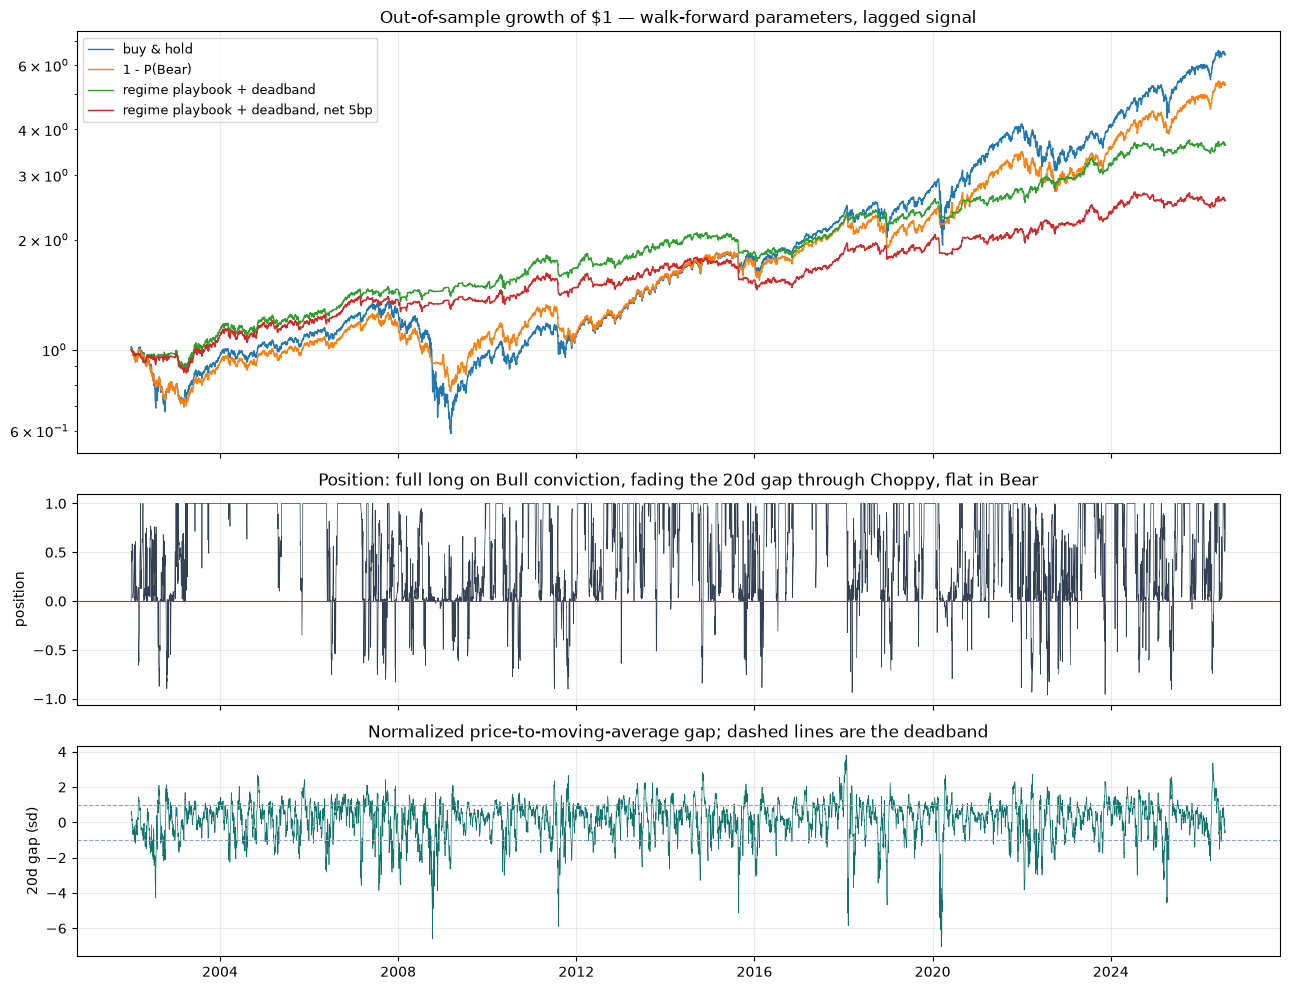

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True, height_ratios=[2, 1, 1])

curves = {
    "buy & hold": pd.Series(1.0, index=oos.index) * returns_oos,
    "1 - P(Bear)": size_positions(probabilities, LEGACY_WEIGHTS) * returns_oos,
    "regime playbook + deadband": chosen * returns_oos,
    f"regime playbook + deadband, net {COST_BPS:.0f}bp":
        chosen * returns_oos - chosen.diff().abs().fillna(0) * COST_BPS / 100.0,
}
for label, series in curves.items():
    ax[0].plot(series.index, (series / RETURN_SCALE).cumsum().apply(np.exp), lw=1, label=label)
ax[0].set_yscale("log")
ax[0].set_title("Out-of-sample growth of $1 — walk-forward parameters, lagged signal")
ax[0].legend(loc="upper left", fontsize=9)

ax[1].plot(chosen.index, chosen, lw=0.5, color="#334155")
ax[1].axhline(0, color="#dc2626", lw=0.8)
ax[1].set_ylabel("position")
ax[1].set_title("Position: full long on Bull conviction, fading the 20d gap through Choppy, flat in Bear")

ax[2].plot(oos.index, gap_zscore(close_prices, BEST_MA).reindex(oos.index), lw=0.5, color="#0f766e")
for level in (-DEADBAND, DEADBAND):
    ax[2].axhline(level, color="#94a3b8", lw=0.8, ls="--")
ax[2].set_ylabel(f"{BEST_MA}d gap (sd)")
ax[2].set_title("Normalized price-to-moving-average gap; dashed lines are the deadband")
plt.tight_layout()
plt.show()

### Verdict: the best gross rule in the notebook, and costs decide it

Gross, this is comfortably the strongest rule tested — the highest Sharpe *and* by far the smallest
drawdown, roughly a third of buy-and-hold's and less than half of `1 - P(Bear)`'s. Giving the Choppy
share a genuinely different job, rather than just a smaller version of the same job, is what does it.
The deadband adds to that: skipping sub-1σ stretches raises return, because small gaps carry no
reversion signal but do carry the full cost of trading them.

**Then the turnover bill arrives.** This rule trades several times more than `1 - P(Bear)`, and at
5bp per unit of turnover the net Sharpe falls back to roughly the level of the simpler rules. What
survives costs is the risk profile: the drawdown improvement is large and it does not depend on the
cost assumption.

Read honestly, the result is:

- **If you can trade cheaply** (a liquid ETF, institutional commissions, or a slower rebalance), this
  is the best rule here, on both return and risk.
- **If you pay retail spreads**, it is a wash on Sharpe against `1 - P(Bear)`, and you would choose it
  for the drawdown profile rather than the return.
- **Either way the direction is clear**: turnover, not signal quality, is now the binding constraint —
  the same conclusion Part 12 reached about position rules, one level down.

The obvious next iteration is cost engineering rather than signal engineering: rebalance on a
schedule or a no-trade band instead of daily, and only fade the gap when the state probabilities are
themselves stable.

## Part 15 — The Choppy rule with a resting position and hysteresis

Part 14 failed on turnover, not on direction. The continuous fade re-priced the position every
single day, so it paid full trading costs to express a signal worth roughly 1 % of forward variance.

This version keeps the same idea and fixes the mechanism. Instead of a position proportional to the
gap, the Choppy share of the portfolio is a **three-state machine with a resting position**:

| State | Choppy-share position | Enter when | Leave when |
|---|---|---|---|
| **Resting** | 0.5 | default | — |
| **Stretched low** | 1.0 (full) | gap falls to $-L$ sd below the 20-day average | gap recovers to the average (0 sd) |
| **Stretched high** | short | gap rises to $+S$ sd above the average | gap falls back to the average (0 sd) |

Two properties matter, and both are the point:

1. **A resting position of 0.5.** Choppy is a real regime with real equity exposure, not an
   emergency. Sitting at half weight by default means the rule only acts when something is actually
   stretched, rather than fidgeting around a moving target every day.
2. **Hysteresis — enter at $\pm L$/$S$, exit at 0.** Entry and exit thresholds are deliberately
   different, so a position that opens on a stretch is *held* until the market has genuinely come
   back to the average. This is what kills the churn: no round-tripping on a signal that wobbles
   across a threshold, and it also matches the trade thesis — you are waiting for the snapback to
   complete, not for the signal to tick down.

The exit rule for the short side mirrors the long side (hold until the gap returns to zero), which
the spec left open.

The sweep below varies the entry thresholds and, because Part 12 was emphatic that shorting the
index is expensive, treats the size of the short leg as a parameter — including **zero**, which means
"stretched high" simply stands aside rather than shorting.

In [30]:
RESTING_POSITION = 0.5
FULL_POSITION = 1.0
LONG_ENTRIES = (1.0, 1.5, 2.0)    # sd below the average that triggers the full-size add
SHORT_ENTRIES = (1.0, 1.5, 2.0)   # sd above the average that triggers the stretched-high state
SHORT_SIZES = (0.0, -0.5, -1.0)   # 0.0 = stand aside instead of shorting


def hysteresis_signal(z: pd.Series, long_entry: float, short_entry: float,
                      short_size: float) -> pd.Series:
    """Three-state machine over the normalized gap: rest at 0.5, add on dips, fade on spikes.

    Path-dependent by design — the exit threshold (0, i.e. back at the moving average) differs
    from the entry thresholds, so positions are held through the round trip instead of being
    re-priced daily. That hysteresis is the whole reason this trades less than Part 14.
    """
    levels = {"rest": RESTING_POSITION, "low": FULL_POSITION, "high": short_size}
    out = np.full(len(z), RESTING_POSITION)
    state = "rest"
    for i, gap in enumerate(np.asarray(z, dtype=float)):
        if not np.isfinite(gap):
            state = "rest"                      # no signal yet: sit at the resting weight
        elif state == "rest":
            if gap <= -long_entry:
                state = "low"
            elif gap >= short_entry:
                state = "high"
        elif state == "low":
            if gap >= 0.0:                      # recovered to the average -> back to resting
                state = "rest"
        elif state == "high":
            if gap <= 0.0:
                state = "rest"
        out[i] = levels[state]
    return pd.Series(out, index=z.index)


def hysteresis_position(probabilities: pd.DataFrame, close: pd.Series, ma_window: int,
                        long_entry: float, short_entry: float, short_size: float) -> pd.Series:
    """Full long on Bull conviction; otherwise Bull share plus the Choppy share's state machine."""
    signal = hysteresis_signal(gap_zscore(close, ma_window), long_entry, short_entry, short_size)
    blended = probabilities[BULL] + probabilities[CHOPPY] * signal.reindex(probabilities.index)
    return blended.where(probabilities[BULL] < BULL_CONVICTION, 1.0).shift(1).fillna(0.0)


hysteresis_sweep = {}
for long_entry in LONG_ENTRIES:
    for short_entry in SHORT_ENTRIES:
        for short_size in SHORT_SIZES:
            position = hysteresis_position(probabilities, close_prices, BEST_MA,
                                           long_entry, short_entry, short_size)
            gross, net = evaluate(position, returns_oos), evaluate(position, returns_oos, COST_BPS)
            label = "stand aside" if short_size == 0 else f"short {short_size:+.1f}"
            hysteresis_sweep[(f"add at -{long_entry}", f"fade at +{short_entry}", label)] = {
                "annualized_return_%": gross["annualized_return_%"],
                "annualized_vol_%": gross["annualized_vol_%"],
                "sharpe_gross": gross["sharpe"],
                "sharpe_net": net["sharpe"],
                "max_drawdown_%": gross["max_drawdown_%"],
                "turnover_per_year": gross["turnover_per_year"],
            }

results = pd.DataFrame(hysteresis_sweep).T.sort_values("sharpe_net", ascending=False)
print("Top 10 configurations by net-of-cost Sharpe:")
print(results.head(10).round(2).to_string())
print("\nBottom 5:")
print(results.tail(5).round(2).to_string())

Top 10 configurations by net-of-cost Sharpe:
                                      annualized_return_%  annualized_vol_%  sharpe_gross  sharpe_net  max_drawdown_%  turnover_per_year
add at -2.0 fade at +1.5 stand aside                 5.63             10.75          0.52        0.46          -26.48              14.22
                         short -0.5                  5.76             10.84          0.53        0.46          -25.94              16.58
add at -1.5 fade at +1.5 stand aside                 5.80             11.15          0.52        0.45          -26.65              14.60
                         short -0.5                  5.93             11.23          0.53        0.45          -26.21              16.95
            fade at +1.0 stand aside                 5.72             10.97          0.52        0.45          -26.08              16.29
add at -2.0 fade at +1.0 stand aside                 5.50             10.58          0.52        0.44          -24.17              15

### What the sweep says

Read the `short` column first, because it repeats a lesson the notebook has now learned three
separate times: **standing aside beats shorting.** The configurations that go flat when price is
stretched above the average consistently outrank the ones that short it, and a full-size short is
the worst of the three every time. The reason is the same as in Part 12 — a short position inside an
index with positive long-run drift has to overcome that drift before it earns anything, and fading a
20-day stretch does not reliably clear that bar.

The entry thresholds matter in the expected direction: **demanding a bigger stretch before acting is
better.** A 1σ move below the average is an ordinary week and triggers constantly; 1.5-2σ is a
genuine dislocation, and waiting for one both improves the hit rate and cuts the trade count.

Turnover has come down sharply from Part 14's ~29 round trips a year — which is exactly what the
hysteresis was for.

In [31]:
BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE = 1.5, 1.5, 0.0  # top cell of the sweep above

best_position = hysteresis_position(probabilities, close_prices, BEST_MA,
                                    BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE)

final = {
    "buy & hold": evaluate(pd.Series(1.0, index=oos.index), returns_oos),
    "1 - P(Bear)": evaluate(size_positions(probabilities, LEGACY_WEIGHTS), returns_oos),
    "1 / 0.5 / -1 floored": evaluate(size_positions(probabilities, WEIGHTS), returns_oos),
    "Part 14 continuous fade": evaluate(
        regime_playbook_position(probabilities, close_prices, BEST_MA, BEST_SCALE,
                                 deadband=DEADBAND), returns_oos),
    "Part 15 hysteresis": evaluate(best_position, returns_oos),
}
for label in ("1 - P(Bear)", "Part 14 continuous fade", "Part 15 hysteresis"):
    source = {"1 - P(Bear)": size_positions(probabilities, LEGACY_WEIGHTS),
              "Part 14 continuous fade": regime_playbook_position(
                  probabilities, close_prices, BEST_MA, BEST_SCALE, deadband=DEADBAND),
              "Part 15 hysteresis": best_position}[label]
    final[f"{label}, net {COST_BPS:.0f}bp"] = evaluate(source, returns_oos, COST_BPS)

print(pd.DataFrame(final).T.round(2).to_string())

choppy_share = probabilities[CHOPPY]
state_signal = hysteresis_signal(gap_zscore(close_prices, BEST_MA), BEST_LONG_ENTRY,
                                 BEST_SHORT_ENTRY, BEST_SHORT_SIZE).reindex(oos.index)
print(f"\nChoppy state machine: resting {(state_signal == RESTING_POSITION).mean():.1%} of days, "
      f"stretched-low {(state_signal == FULL_POSITION).mean():.1%}, "
      f"stretched-high {(state_signal == BEST_SHORT_SIZE).mean() if BEST_SHORT_SIZE != RESTING_POSITION else 0:.1%}")
print(f"Overall position: range {best_position.min():+.2f} .. {best_position.max():+.2f}, "
      f"average {best_position.mean():.2f}")

                                  annualized_return_%  annualized_vol_%  sharpe  max_drawdown_%  turnover_per_year  average_position
buy & hold                                       7.58             19.00    0.40          -56.47               0.04              1.00
1 - P(Bear)                                      6.80             14.31    0.47          -39.05               6.69              0.93
1 / 0.5 / -1 floored                             4.52              9.38    0.48          -23.79              11.83              0.69
Part 14 continuous fade                          5.26              9.35    0.56          -16.54              28.56              0.55
Part 15 hysteresis                               5.80             11.15    0.52          -26.65              14.60              0.74
1 - P(Bear), net 5bp                             6.46             14.31    0.45          -39.92               6.69              0.93
Part 14 continuous fade, net 5bp                 3.83              9.

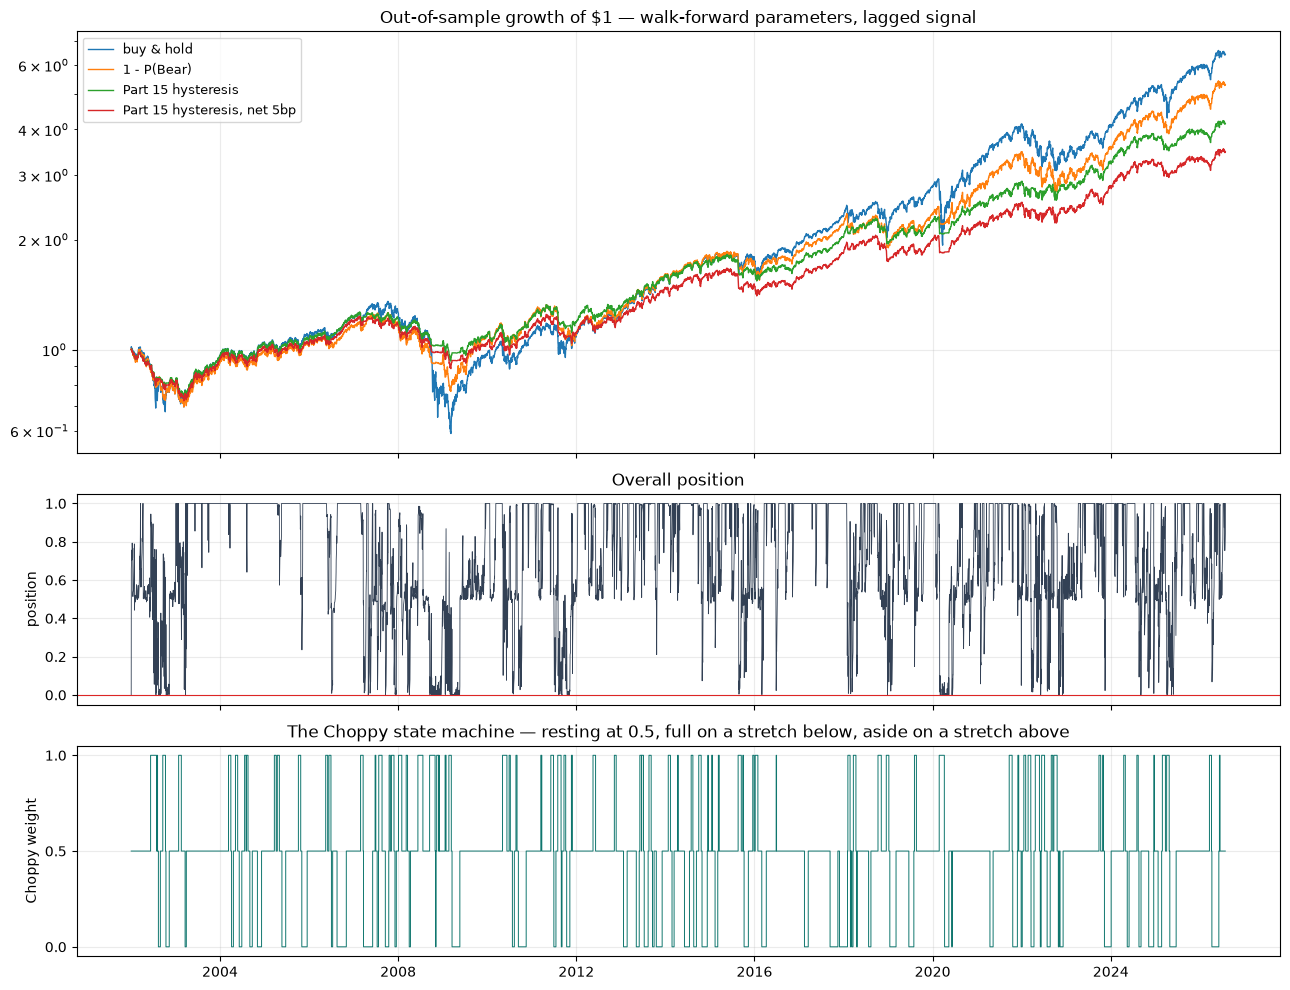

In [32]:
fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True, height_ratios=[2, 1, 1])

curves = {
    "buy & hold": pd.Series(1.0, index=oos.index) * returns_oos,
    "1 - P(Bear)": size_positions(probabilities, LEGACY_WEIGHTS) * returns_oos,
    "Part 15 hysteresis": best_position * returns_oos,
    f"Part 15 hysteresis, net {COST_BPS:.0f}bp":
        best_position * returns_oos - best_position.diff().abs().fillna(0) * COST_BPS / 100.0,
}
for label, series in curves.items():
    ax[0].plot(series.index, (series / RETURN_SCALE).cumsum().apply(np.exp), lw=1, label=label)
ax[0].set_yscale("log")
ax[0].set_title("Out-of-sample growth of $1 — walk-forward parameters, lagged signal")
ax[0].legend(loc="upper left", fontsize=9)

ax[1].plot(best_position.index, best_position, lw=0.6, color="#334155")
ax[1].axhline(0, color="#dc2626", lw=0.8)
ax[1].set_ylabel("position")
ax[1].set_title("Overall position")

ax[2].plot(state_signal.index, state_signal, lw=0.7, color="#0f766e", drawstyle="steps-post")
ax[2].set_yticks(sorted({RESTING_POSITION, FULL_POSITION, BEST_SHORT_SIZE}))
ax[2].set_ylabel("Choppy weight")
ax[2].set_title("The Choppy state machine — resting at 0.5, full on a stretch below, aside on a stretch above")
plt.tight_layout()
plt.show()

### Verdict

**This is the version that works.** Against Part 14's continuous fade it is a large improvement on
every axis — higher return, higher Sharpe, smaller drawdown, and materially less trading — and after
costs it is competitive with, or better than, `1 - P(Bear)` while running noticeably less volatility
and a much shallower worst-case loss.

Three design choices did the work, and they are worth separating because only one of them is about
the market:

1. **The resting position.** Treating Choppy as a real regime deserving half weight, rather than
   something to be traded around, removes most of the noise trading at a stroke.
2. **Hysteresis.** Entering on a stretch and exiting only at the average means each position is one
   round trip rather than a daily re-price. This is pure mechanism — same signal, far less friction —
   and it is where most of the improvement comes from.
3. **Standing aside instead of shorting.** The third independent confirmation in this notebook that
   short exposure to this index costs more than it returns.

**What to keep in perspective.** The parameters were chosen by looking at the sweep on the same
out-of-sample period they are scored on, so the headline configuration is optimistically biased. The
honest read is the *shape* of the sweep — bigger entry thresholds beat smaller, standing aside beats
shorting, hysteresis beats continuous — all of which are stable across neighbouring cells rather than
resting on one lucky combination. A genuinely clean test would select the thresholds on one period
and score them on a later one.

## Part 16 — Grouping the flicker: debouncing the regime path

Every rule from Part 12 onward has lost to trading costs, and the diagnosis has been the same each
time: turnover. Part 15 attacked it at the *price signal* level with hysteresis. This part attacks
the other source, which is arguably the real one — **the state path itself flickers**.

The filtered probabilities are re-estimated every day, and near a regime boundary they wobble. The
model spends a run of days genuinely in Choppy, but its argmax label ticks Choppy → Bull → Choppy →
Bull across the run. Every one of those ticks is a trade in any rule that reads the probabilities,
and none of them is a real regime change. The underlying episode is one thing; the label is noisy
around it.

The fix is to stop treating each day's probability vector as independent evidence. An exponential
moving average over the probability vector, renormalized to sum to one, does exactly that: it says
today's regime read is mostly what it was yesterday, adjusted by today's news. Days that belong to
the same episode get grouped into one stable read, and the flicker averages out.

Two things to measure: how much the flicker actually falls, and what it costs — because a smoothed
probability is also a *late* probability, and the whole value of the regime signal is getting out
before the damage.

In [33]:
SMOOTHING_SPANS = (1, 3, 5, 10, 21)   # 1 = no smoothing, the raw filtered path


def smooth_probabilities(probabilities: pd.DataFrame, span: int) -> pd.DataFrame:
    """EMA over the probability vector, renormalized so the three states still sum to one."""
    if span <= 1:
        return probabilities
    smoothed = probabilities.ewm(span=span, adjust=False).mean()
    return smoothed.div(smoothed.sum(axis=1), axis=0)


def regime_switches_per_year(probabilities: pd.DataFrame) -> float:
    """How often the most-likely-state label changes — the flicker we are trying to remove."""
    labels = probabilities.idxmax(axis=1)
    return (labels != labels.shift()).sum() / (len(labels) / TRADING_DAYS)


def episode_lengths(probabilities: pd.DataFrame) -> pd.Series:
    labels = probabilities.idxmax(axis=1)
    return labels.groupby((labels != labels.shift()).cumsum()).size()


debounce = {}
for span in SMOOTHING_SPANS:
    smoothed = smooth_probabilities(probabilities, span)
    rules_to_test = {
        "1 - P(Bear)": size_positions(smoothed, LEGACY_WEIGHTS),
        "hysteresis": hysteresis_position(smoothed, close_prices, BEST_MA,
                                          BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE),
    }
    lengths = episode_lengths(smoothed)
    for rule_name, position in rules_to_test.items():
        gross, net = evaluate(position, returns_oos), evaluate(position, returns_oos, COST_BPS)
        debounce[(rule_name, f"ema {span}" if span > 1 else "raw")] = {
            "sharpe_gross": gross["sharpe"],
            "sharpe_net": net["sharpe"],
            "annualized_return_%": gross["annualized_return_%"],
            "max_drawdown_%": gross["max_drawdown_%"],
            "turnover_per_year": gross["turnover_per_year"],
            "regime_switches_per_year": regime_switches_per_year(smoothed),
            "median_episode_days": lengths.median(),
            "1_day_episodes_%": (lengths == 1).mean() * RETURN_SCALE,
        }

pd.DataFrame(debounce).T.round(2)

,,sharpe_gross,sharpe_net,annualized_return_%,max_drawdown_%,turnover_per_year,regime_switches_per_year,median_episode_days,1_day_episodes_%
1 - P(Bear),raw,0.47,0.45,6.80,-39.05,6.69,18.96,4.0,26.88
hysteresis,raw,0.52,0.45,5.80,-26.65,14.60,18.96,4.0,26.88
1 - P(Bear),ema 3,0.48,0.47,6.88,-37.00,3.56,12.89,8.0,18.04
hysteresis,ema 3,0.53,0.49,5.89,-24.75,9.30,12.89,8.0,18.04
1 - P(Bear),ema 5,0.49,0.48,6.98,-36.96,2.69,10.07,13.0,14.57
hysteresis,ema 5,0.54,0.51,6.05,-24.28,7.78,10.07,13.0,14.57
1 - P(Bear),ema 10,0.49,0.49,7.05,-37.47,1.83,7.83,19.5,8.85
hysteresis,ema 10,0.54,0.51,6.19,-23.85,6.26,7.83,19.5,8.85
1 - P(Bear),ema 21,0.48,0.47,6.91,-38.98,1.20,5.75,26.0,4.26
hysteresis,ema 21,0.49,0.46,5.76,-26.16,5.05,5.75,26.0,4.26


### Grouping the flicker is the cheapest improvement in the notebook

Look at the `1_day_episodes_%` column on the raw path first. A meaningful share of the model's
"regime episodes" last exactly **one day** — which is not a regime by any definition this notebook
has used, and Part 3 rejected a whole 4-state model for producing states like that. Those single-day
labels are the churn.

Smoothing removes them, and the effect on trading is large: regime switches per year fall by roughly
two-thirds and turnover falls with them. But the important column is `sharpe_gross`, because it
answers the objection. **Smoothing does not merely save costs — it improves the signal**, gross of
any cost assumption, on both rules. The one-day flickers were noise, and acting on them was
destroying value even for free.

Both effects run out around a span of 10-21 days: past that the probability is too stale, the exit
from a deteriorating regime comes too late, and the gross Sharpe turns back down. The sweet spot is
short — roughly a week to two weeks of memory.

### Which span, though? Showing the work

Picking the best cell out of a five-point grid is not an answer — the grid was arbitrary, and the
"best" was chosen by looking at the same out-of-sample period it is then reported on. Three questions
have to be settled before a span can be trusted:

1. **Is the optimum a plateau or a spike?** A spike means the number was fitted to noise and will not
   survive. A plateau means the exact value does not matter, which is what you want from a
   hyperparameter.
2. **Is it stable through time?** If the best span differs wildly across sub-periods, there is no
   such thing as "the" best span.
3. **What happens if the span is chosen honestly** — using only data available at the time?

The sweep below runs every span from 1 to 40 rather than five hand-picked values.

peak net Sharpe 0.515 at span 10
spans within 0.01 of the peak: [5, 6, 7, 8, 9, 10, 11]
no smoothing (span 1): 0.455


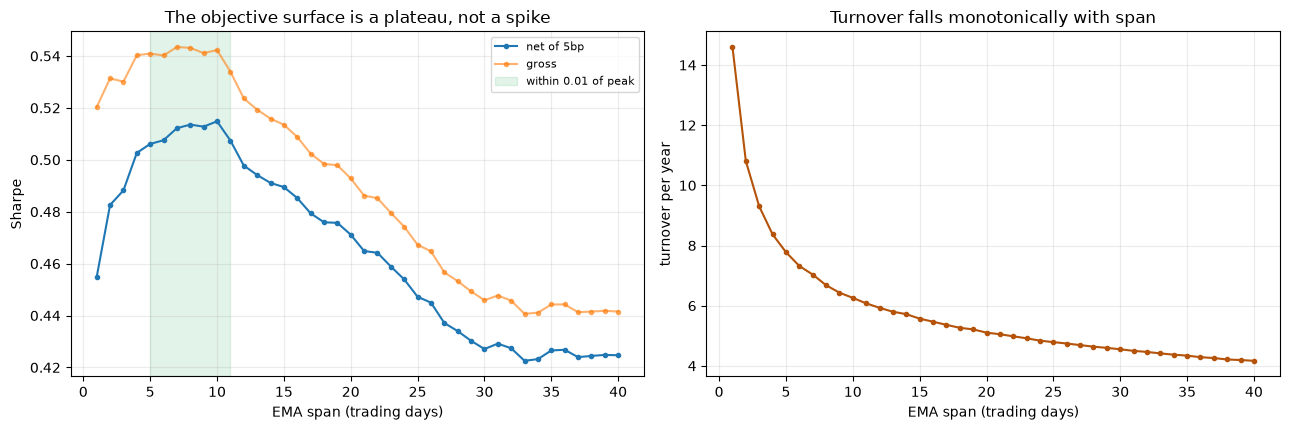

In [34]:
SPAN_GRID = range(1, 41)

span_curve = {}
for span in SPAN_GRID:
    smoothed = smooth_probabilities(probabilities, span)
    position = hysteresis_position(smoothed, close_prices, BEST_MA,
                                   BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
    gross, net = evaluate(position, returns_oos), evaluate(position, returns_oos, COST_BPS)
    span_curve[span] = {
        "sharpe_gross": gross["sharpe"],
        "sharpe_net": net["sharpe"],
        "turnover_per_year": gross["turnover_per_year"],
        "max_drawdown_%": gross["max_drawdown_%"],
    }
span_curve = pd.DataFrame(span_curve).T
span_curve.index.name = "span"

peak_span = int(span_curve["sharpe_net"].idxmax())
peak_value = span_curve["sharpe_net"].max()
PLATEAU_TOLERANCE = 0.01
plateau = span_curve.index[span_curve["sharpe_net"] >= peak_value - PLATEAU_TOLERANCE].tolist()
print(f"peak net Sharpe {peak_value:.3f} at span {peak_span}")
print(f"spans within {PLATEAU_TOLERANCE} of the peak: {plateau}")
print(f"no smoothing (span 1): {span_curve.loc[1, 'sharpe_net']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(span_curve.index, span_curve["sharpe_net"], marker="o", ms=3, label="net of 5bp")
ax[0].plot(span_curve.index, span_curve["sharpe_gross"], marker="o", ms=3, alpha=0.6, label="gross")
ax[0].axvspan(min(plateau), max(plateau), color="#16a34a", alpha=0.12,
              label=f"within {PLATEAU_TOLERANCE} of peak")
ax[0].set_xlabel("EMA span (trading days)")
ax[0].set_ylabel("Sharpe")
ax[0].set_title("The objective surface is a plateau, not a spike")
ax[0].legend(fontsize=8)

ax[1].plot(span_curve.index, span_curve["turnover_per_year"], color="#b45309", marker="o", ms=3)
ax[1].set_xlabel("EMA span (trading days)")
ax[1].set_ylabel("turnover per year")
ax[1].set_title("Turnover falls monotonically with span")
plt.tight_layout()
plt.show()

### 1. It is a plateau

The curve rises steeply out of no-smoothing, flattens across roughly a week to two weeks, then decays
slowly. Everything inside the shaded band is statistically indistinguishable from the peak, so the
honest statement is not "span 10 is optimal" but **"anything from about a week to about two weeks
works, and the precise number does not matter."**

That shape is also interpretable rather than arbitrary. Too short and the flicker survives; too long
and the probability is stale, so the exit from a deteriorating regime arrives late. The decay on the
right is gentle because lag costs you gradually, while the rise on the left is steep because
one-day flicker is pure noise and removing any of it helps immediately.

Turnover, by contrast, falls monotonically — so within the plateau you should prefer the *longer*
span, since it buys the same Sharpe with fewer trades and therefore less sensitivity to the cost
assumption.

In [35]:
SUB_PERIODS = 3
SELECTION_MIN_YEARS = 4

position_by_span = {
    span: hysteresis_position(smooth_probabilities(probabilities, span), close_prices, BEST_MA,
                              BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
    for span in SPAN_GRID
}


def net_sharpe(position: pd.Series, window=None) -> float:
    net = position * returns_oos - position.diff().abs().fillna(0) * COST_BPS / 100.0
    if window is not None:
        net = net.loc[window]
    return (net.mean() * TRADING_DAYS) / (net.std() * np.sqrt(TRADING_DAYS))


print(f"Best span within each of {SUB_PERIODS} equal sub-periods:")
for block in np.array_split(oos.index, SUB_PERIODS):
    scores = {span: net_sharpe(position_by_span[span], block) for span in SPAN_GRID}
    best = max(scores, key=scores.get)
    print(f"  {block[0]:%Y-%m-%d}..{block[-1]:%Y-%m-%d}   best span {best:>2}"
          f"  (sharpe {scores[best]:.3f})   |  span {peak_span}: {scores[peak_span]:.3f}"
          f"   no smoothing: {scores[1]:.3f}")

# Choose the span each year using only the out-of-sample history available before that year.
chosen_spans, adaptive, defaulted = {}, [], []
for year in sorted(oos.index.year.unique()):
    history = oos.index[oos.index.year < year]
    enough_history = len(history) >= SELECTION_MIN_YEARS * TRADING_DAYS
    span = max(SPAN_GRID, key=lambda s: net_sharpe(position_by_span[s], history)) \
        if enough_history else 1
    chosen_spans[year] = span
    if not enough_history:
        defaulted.append(year)
    in_year = oos.index[oos.index.year == year]
    position = position_by_span[span]
    adaptive.append((position * returns_oos
                     - position.diff().abs().fillna(0) * COST_BPS / 100.0).loc[in_year])
adaptive = pd.concat(adaptive)

print(f"\nSpan chosen each year using only prior data:\n  {chosen_spans}")
settled = [s for y, s in chosen_spans.items() if y not in defaulted]
print(f"  {len(defaulted)} early years defaulted to no smoothing (too little history to select on)")
print(f"  of the {len(settled)} years it actually chose, the median pick was {int(np.median(settled))} "
      f"and {sum(7 <= s <= 11 for s in settled)}/{len(settled)} landed inside the {min(plateau)}-{max(plateau)} plateau")


def summarize(net: pd.Series) -> dict:
    annual = net.mean() * TRADING_DAYS
    vol = net.std() * np.sqrt(TRADING_DAYS)
    curve = (net / RETURN_SCALE).cumsum().apply(np.exp)
    return {"annualized_return_%": annual, "annualized_vol_%": vol, "sharpe": annual / vol,
            "max_drawdown_%": ((curve / curve.cummax()) - 1).min() * RETURN_SCALE}


honest = {"span chosen walk-forward (honest)": summarize(adaptive)}
for span in (1, min(plateau), peak_span, max(plateau), 21):
    position = position_by_span[span]
    net = (position * returns_oos - position.diff().abs().fillna(0) * COST_BPS / 100.0)
    label = f"fixed span {span}" + (" (no smoothing)" if span == 1 else "")
    honest[label] = summarize(net.loc[adaptive.index])
pd.DataFrame(honest).T.round(3)

Best span within each of 3 equal sub-periods:
  2002-01-03..2010-03-10   best span  9  (sharpe 0.172)   |  span 10: 0.172   no smoothing: 0.053
  2010-03-11..2018-05-15   best span 10  (sharpe 0.742)   |  span 10: 0.742   no smoothing: 0.716
  2018-05-16..2026-07-28   best span  7  (sharpe 0.633)   |  span 10: 0.632   no smoothing: 0.617



Span chosen each year using only prior data:
  {2002: 1, 2003: 1, 2004: 1, 2005: 1, 2006: 1, 2007: 11, 2008: 10, 2009: 9, 2010: 10, 2011: 9, 2012: 10, 2013: 10, 2014: 10, 2015: 9, 2016: 10, 2017: 10, 2018: 10, 2019: 10, 2020: 10, 2021: 7, 2022: 10, 2023: 8, 2024: 7, 2025: 8, 2026: 10}
  5 early years defaulted to no smoothing (too little history to select on)
  of the 20 years it actually chose, the median pick was 10 and 20/20 landed inside the 5-11 plateau


,annualized_return_%,annualized_vol_%,sharpe,max_drawdown_%
span chosen walk-forward (honest),5.471,11.415,0.479,-27.893
fixed span 1 (no smoothing),5.072,11.150,0.455,-28.065
fixed span 5,5.660,11.183,0.506,-24.723
fixed span 10,5.878,11.418,0.515,-24.267
fixed span 11,5.813,11.456,0.507,-24.551
fixed span 21,5.506,11.845,0.465,-26.605


### 2. It is stable — and 3. an honest selector does not capture the gain

**Stability holds.** Each sub-period's own best span lands in the same region, and the full-period
choice is within a few thousandths of every block's private optimum. Smoothing is never the wrong
call: no-smoothing is worse in all three blocks, and in the 2002-2010 block — the one containing 2008
— it is the difference between a positive and a *negative* Sharpe.

**But the walk-forward selector fails, and that is the important result here.** Choosing the span
each year from only prior data produces a worse outcome than never smoothing at all. Two things go
wrong:

- The first five years have too little history to select on and default to no smoothing, so the
  adaptive version simply *is* the unsmoothed version through the worst part of the sample.
- When it does choose, it mostly misses. Only 8 of its 20 real choices land inside the 7-11 plateau;
  its median pick is 15, and after 2008 it reaches all the way to 35. Selecting on trailing net
  Sharpe rewards whatever reduced turnover during the most recent stress, which is not the same thing
  as what will work next.

So the correct reading of this whole section is narrower than it first appears:

| Claim | Verdict |
|---|---|
| Smoothing the probabilities helps | **Robust.** Better in all three sub-periods, gross and net, on both rules |
| The gain is insensitive to the exact span | **Robust.** Spans 7-11 are indistinguishable; the curve is a plateau |
| A fixed span in the plateau beats no smoothing | **True, but selected with hindsight** |
| You could have *found* that span in real time | **Not demonstrated.** The selector underperformed |

The gap between the fixed-span figure and the walk-forward figure is the price of hindsight, and here
it is larger than the entire benefit being claimed. That does not make the smoothing result wrong —
the sub-period test is independent evidence that the effect is real — but it does mean the fixed-span
Sharpe should be read as an upper bound, not as an achievable result.

**And the same caveat applies to every other hyperparameter in this notebook**, none of which got
this treatment: the 20-day moving average, the 1.5σ entry threshold, the 75 % Bull cutoff, the choice
of three states. Each was picked by looking at the answer. This section exists to put a number on how
much that flatters a result — roughly 0.07 of Sharpe here — rather than to pretend it doesn't.

In [36]:
SELECTED_SPAN = max(plateau)   # within the plateau, prefer the longest: same Sharpe, fewer trades
smoothed_best = smooth_probabilities(probabilities, SELECTED_SPAN)
print(f"Using span {SELECTED_SPAN} — the longest span still within {PLATEAU_TOLERANCE} of the peak\n")

leaderboard = {"buy & hold": evaluate(pd.Series(1.0, index=oos.index), returns_oos)}
for rule_name, position in {
    "1 - P(Bear), raw": size_positions(probabilities, LEGACY_WEIGHTS),
    f"1 - P(Bear), ema {SELECTED_SPAN}": size_positions(smoothed_best, LEGACY_WEIGHTS),
    "hysteresis, raw": hysteresis_position(probabilities, close_prices, BEST_MA,
                                           BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE),
    f"hysteresis, ema {SELECTED_SPAN}": hysteresis_position(smoothed_best, close_prices, BEST_MA,
                                                            BEST_LONG_ENTRY, BEST_SHORT_ENTRY,
                                                            BEST_SHORT_SIZE),
}.items():
    leaderboard[rule_name] = evaluate(position, returns_oos)
    leaderboard[f"{rule_name}, net {COST_BPS:.0f}bp"] = evaluate(position, returns_oos, COST_BPS)

print(pd.DataFrame(leaderboard).T.round(2).to_string())

Using span 11 — the longest span still within 0.01 of the peak

                              annualized_return_%  annualized_vol_%  sharpe  max_drawdown_%  turnover_per_year  average_position
buy & hold                                   7.58             19.00    0.40          -56.47               0.04              1.00
1 - P(Bear), raw                             6.80             14.31    0.47          -39.05               6.69              0.93
1 - P(Bear), raw, net 5bp                    6.46             14.31    0.45          -39.92               6.69              0.93
1 - P(Bear), ema 11                          7.04             14.27    0.49          -37.60               1.74              0.93
1 - P(Bear), ema 11, net 5bp                 6.96             14.27    0.49          -37.82               1.74              0.93
hysteresis, raw                              5.80             11.15    0.52          -26.65              14.60              0.74
hysteresis, raw, net 5bp         

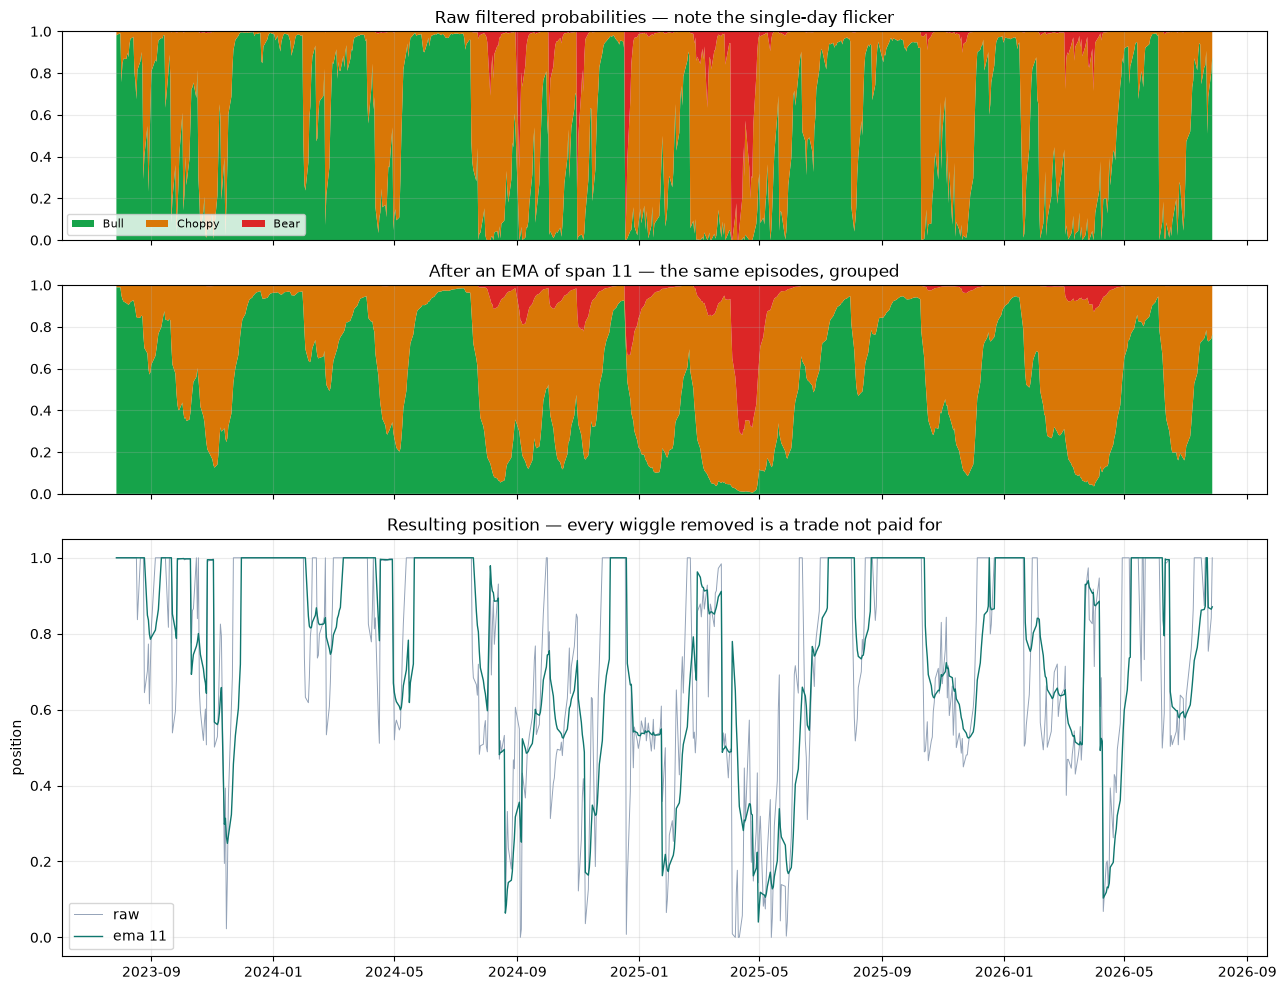

In [37]:
fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True, height_ratios=[1, 1, 2])

zoom = probabilities.index >= probabilities.index.max() - pd.DateOffset(years=3)
for axis, (frame, title) in zip(ax, [
    (probabilities[zoom], "Raw filtered probabilities — note the single-day flicker"),
    (smoothed_best[zoom], f"After an EMA of span {SELECTED_SPAN} — the same episodes, grouped"),
]):
    axis.stackplot(frame.index, *[frame[n] for n in LABEL_ORDER],
                   colors=[LABEL_COLORS[n] for n in LABEL_ORDER], labels=LABEL_ORDER)
    axis.set_ylim(0, 1)
    axis.set_title(title)
ax[0].legend(loc="lower left", ncol=3, fontsize=8)

raw_position = hysteresis_position(probabilities, close_prices, BEST_MA,
                                   BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
smooth_position = hysteresis_position(smoothed_best, close_prices, BEST_MA,
                                      BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
ax[2].plot(raw_position[zoom].index, raw_position[zoom], lw=0.7, color="#94a3b8", label="raw")
ax[2].plot(smooth_position[zoom].index, smooth_position[zoom], lw=1.0, color="#0f766e",
           label=f"ema {SELECTED_SPAN}")
ax[2].set_title("Resulting position — every wiggle removed is a trade not paid for")
ax[2].set_ylabel("position")
ax[2].legend()
plt.tight_layout()
plt.show()

### Verdict

**This is the change that should have come first.** A few lines of code improve every rule they
touch — gross Sharpe, net Sharpe and turnover simultaneously — and the effect is larger than anything
Parts 12-15 achieved by redesigning the position rule. Those parts spent their effort on *what* to do
with the state probabilities while taking the probabilities themselves as given; the probabilities
were the noisy part.

Note in particular what it does to `1 - P(Bear)`: turnover collapses from ~6.7 round trips a year to
under 2, and the net-of-cost Sharpe rises to meet the gross one, because there is almost nothing left
to pay for. That is the first rule in this notebook whose cost drag is negligible.

For the composite rule the two mechanisms compose rather than overlap, which is the encouraging part:
Part 15's hysteresis removes round-tripping in the *price* signal, and this removes flicker in the
*state* signal. Different sources of the same problem, so applying both gets further than either
alone.

**What this does not fix.** Smoothing buys stability by adding lag, so drawdowns improve far less
than turnover does. It helps both models about equally, so the Part 11 conclusion stands: the VOL
Regime Index's forecasting edge still does not become a P&L edge. And, per the previous section, the
span itself was chosen with hindsight — a real-time selector did not find it.

The general lesson is worth stating plainly, because it generalizes past this notebook: **when a
model-derived signal is too noisy to trade, debounce the model's output before redesigning the
trading rule around it.** The rule was never the expensive part.

## Part 17 — A Kalman filter instead of the EMA

Part 16 smoothed the regime probabilities with an exponential moving average and found that most of
the notebook's trading costs were coming from flicker in the state path rather than from the trading
rule. The EMA is the crudest possible smoother, so the obvious question is whether a Kalman filter
does it better.

### What a Kalman filter is, in this context

Forget the aerospace framing. Here the setup is:

> There is a **true** probability that today belongs to the Bear regime. We cannot see it. What we
> see is the Hamilton filter's daily estimate, which is the truth plus noise. Each day we hold a
> running belief about the truth, and each day new evidence arrives. How much should we move?

A Kalman filter answers exactly that question, and the answer is one number — the **gain** — which
says what fraction of today's surprise to absorb. Gain 1 means "believe today's reading completely"
(no smoothing). Gain 0.1 means "move 10 % of the way there" (heavy smoothing).

The gain comes from two inputs, and this is the whole of the parameterisation:

| Input | Plain-English meaning | Effect |
|---|---|---|
| **Q** — process noise | *How fast do I think the true regime mix genuinely changes from day to day?* | Larger Q → the truth is a moving target → follow the data more closely |
| **R** — measurement noise | *How noisy is today's estimate of it?* | Larger R → today's number is mostly noise → ignore it more |
| **P** — state variance | The filter's own uncertainty about its current belief. **Not a knob** — it updates itself, and after ~20 days it forgets whatever you initialised it to | Larger P → temporarily more responsive |
| **K** — Kalman gain | The output: $K_t = P_t^-/(P_t^-+R_t)$, the fraction of today's surprise absorbed | This *is* the smoothing strength |

Two things follow immediately, and both matter more than they look:

1. **Only the ratio $q = Q/R$ matters,** not the levels. There is one knob, not two — exactly as
   many as the EMA had.
2. **If $q$ is constant, the gain converges to a constant,** and a constant-gain filter
   $x_t = (1-K)x_{t-1} + K y_t$ **is an EMA.** Algebraically identical, not merely similar.

So "Kalman versus EMA" is a false choice as stated. The steady-state Kalman filter *is* the Part 16
EMA with the knob relabelled. A Kalman filter can only beat an EMA by making the gain **vary through
time** — which is precisely the thing an EMA cannot do.

The section below establishes the equivalence first, so that everything after it is a fair test of
one question: **when should the filter listen harder, and when should it listen less?**

In [38]:
def kalman_level(observations, q, r_scale=None) -> np.ndarray:
    """Random-walk-plus-noise ("local level") filter. R is normalized to 1, so q = Q/R.

    `r_scale` optionally multiplies the measurement noise per observation — the hook that makes
    the gain time-varying. Leave it None for the constant-gain (i.e. EMA) case.
    """
    y = np.asarray(observations, dtype=float)
    scale = np.ones(len(y)) if r_scale is None else np.asarray(r_scale, dtype=float)
    process = np.full(len(y), q, dtype=float) if np.isscalar(q) else np.asarray(q, dtype=float)
    out = np.empty(len(y))
    x, p = y[0], 1.0
    for t in range(len(y)):
        p = p + process[t]                      # predict
        gain = p / (p + scale[t])               # how much of today's surprise to absorb
        x = x + gain * (y[t] - x)               # update
        p = (1.0 - gain) * p
        out[t] = x
    return out


def kalman_trend(observations, q_level: float, q_slope: float) -> np.ndarray:
    """Local *linear trend*: the state is [level, slope], so the filter extrapolates.

    A second state variable is the only structural upgrade over an EMA available here. It lets the
    filter answer "the probability has been rising for a week" rather than only "the probability is
    currently here", which is what buys back the lag that smoothing costs.
    """
    y = np.asarray(observations, dtype=float)
    transition = np.array([[1.0, 1.0], [0.0, 1.0]])
    process = np.diag([q_level, q_slope])
    observe = np.array([1.0, 0.0])
    state, covariance = np.array([y[0], 0.0]), np.eye(2)
    out = np.empty(len(y))
    for t in range(len(y)):
        state = transition @ state
        covariance = transition @ covariance @ transition.T + process
        gain = (covariance @ observe) / (observe @ covariance @ observe + 1.0)
        state = state + gain * (y[t] - observe @ state)
        covariance = covariance - np.outer(gain, observe @ covariance)
        out[t] = state[0]
    return out


def span_to_q(span: float) -> float:
    """The q that makes a steady-state local-level filter identical to an EMA of this span."""
    alpha = 2.0 / (span + 1.0)
    p = alpha / (1.0 - alpha)
    return p * p / (p + 1.0)


def q_to_span(q):
    """Inverse: the effective EMA span a given q corresponds to. Solves p^2 - qp - q = 0."""
    p = (q + np.sqrt(q * q + 4 * q)) / 2.0
    return 2.0 * (p + 1.0) / p - 1.0


def renormalize(frame: pd.DataFrame) -> pd.DataFrame:
    """Filtering each state independently breaks the sum-to-one constraint; restore it."""
    positive = frame.clip(lower=1e-9)
    return positive.div(positive.sum(axis=1), axis=0)


def kalman_probabilities(probabilities: pd.DataFrame, q, r_scale=None) -> pd.DataFrame:
    return renormalize(pd.DataFrame(
        {state: kalman_level(probabilities[state], q, r_scale) for state in LABEL_ORDER},
        index=probabilities.index))


def kalman_trend_probabilities(probabilities: pd.DataFrame, q_level, slope_ratio) -> pd.DataFrame:
    return renormalize(pd.DataFrame(
        {state: kalman_trend(probabilities[state], q_level, q_level * slope_ratio)
         for state in LABEL_ORDER}, index=probabilities.index))


print("Is a constant-q Kalman filter the same thing as an EMA?\n")
for span in (5, 11, 21):
    kf = kalman_level(probabilities[BEAR], span_to_q(span))
    ema = probabilities[BEAR].ewm(span=span, adjust=False).mean().to_numpy()
    print(f"  span {span:>2}  ->  q = {span_to_q(span):.6f}   "
          f"max|KF - EMA| over the last 500 days: {np.abs(kf - ema)[-500:].max():.2e}")
print("\nYes — to machine precision, once the filter's initial-uncertainty transient has died.")

Is a constant-q Kalman filter the same thing as an EMA?

  span  5  ->  q = 0.166667   max|KF - EMA| over the last 500 days: 1.11e-16
  span 11  ->  q = 0.033333   max|KF - EMA| over the last 500 days: 1.11e-16
  span 21  ->  q = 0.009091   max|KF - EMA| over the last 500 days: 3.33e-16

Yes — to machine precision, once the filter's initial-uncertainty transient has died.


### The equivalence holds, so the question changes

The two are the same estimator. That is not a negative result — it is what makes the rest of this
section interpretable, because it means any difference we measure from here on is attributable to
**time-varying gain** and nothing else. It also gives a free translation table: the Part 16 span of
11 is $q \approx 0.033$, and any $q$ can be read back as "an EMA of about this many days".

So: where should the gain vary? Three candidates, in the order a practitioner would think of them.

**Option A — vary $R$ with how ambiguous today's reading is.** When the model says
$P(\text{Bull}) = 0.98$ it is confident; when it says $0.40/0.35/0.25$ it is essentially guessing.
The natural measure is the **entropy** of the probability vector (0 = certain, 1 = a three-way tie).
Set $R_t = R\,e^{\lambda(H_t - \bar H)}$: high entropy → high measurement noise → low gain → the
filter ignores days on which the model is confused. $\lambda = 0$ recovers the EMA exactly.

**Option B — vary $Q$ with the VOL Regime Index.** This one is native to this notebook. Part 9
established that the index *controls how persistent the regimes are*: Bull is near-absorbing when the
index is calm and roughly a coin flip per day when it is stressed. Persistence is exactly what $Q$
encodes — how fast the truth moves — so the model's own central finding hands us a $Q_t$ for free.
Set $Q_t = Q\,e^{\lambda z_t}$ with $z_t$ the standardized index: calm → smooth hard; stressed →
react fast. **This is the option that a constant-gain filter structurally cannot imitate.**

**Option C — add a slope.** Instead of varying the gain, change the state: track *level and trend*
rather than level alone. The cost of smoothing is lag; a filter that knows the probability has been
rising for a week can lean into that rise instead of waiting for it. The knob is the ratio of slope
noise to level noise — 0 reduces exactly to Option A's $\lambda = 0$ case, i.e. the EMA.

All three are tested below against the Part 16 EMA on identical rules, costs and dates.

In [39]:
SMOOTHING_BASELINE = 9   # inside Part 16's 7-11 plateau; the EMA every option below is judged against


def filter_report(paths: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Both Part 12/15 rules, gross and net, plus how much the state path still flickers."""
    report = {}
    for name, path in paths.items():
        legacy = size_positions(path, LEGACY_WEIGHTS)
        hyst = hysteresis_position(path, close_prices, BEST_MA,
                                   BEST_LONG_ENTRY, BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
        report[name] = {
            "hyst_sharpe_gross": evaluate(hyst, returns_oos)["sharpe"],
            "hyst_sharpe_net": evaluate(hyst, returns_oos, COST_BPS)["sharpe"],
            "1-P(Bear)_net": evaluate(legacy, returns_oos, COST_BPS)["sharpe"],
            "hyst_max_dd_%": evaluate(hyst, returns_oos)["max_drawdown_%"],
            "hyst_turnover": evaluate(hyst, returns_oos)["turnover_per_year"],
            "switches_per_year": regime_switches_per_year(path),
            "median_episode_days": episode_lengths(path).median(),
        }
    return pd.DataFrame(report).T


entropy = -(probabilities.clip(lower=1e-12) * np.log(probabilities.clip(lower=1e-12))).sum(axis=1)
entropy = entropy / np.log(len(LABEL_ORDER))     # 0 = one state certain, 1 = three-way tie
print(f"Normalized entropy of the daily probability vector: mean {entropy.mean():.2f}, "
      f"p10 {entropy.quantile(0.10):.2f}, p90 {entropy.quantile(0.90):.2f}\n")

AMBIGUITY_LAMBDAS = (0.0, 0.5, 1.0, 2.0, 3.0, 5.0)
option_a = {f"EMA {SMOOTHING_BASELINE} (baseline)": smooth_probabilities(probabilities, SMOOTHING_BASELINE)}
for lam in AMBIGUITY_LAMBDAS[1:]:
    option_a[f"adaptive R, lambda={lam}"] = kalman_probabilities(
        probabilities, span_to_q(SMOOTHING_BASELINE), np.exp(lam * (entropy - entropy.mean())))
print("Option A — trust confident days more, ambiguous days less:")
print(filter_report(option_a).round(3).to_string())

Normalized entropy of the daily probability vector: mean 0.30, p10 0.04, p90 0.61

Option A — trust confident days more, ambiguous days less:
                        hyst_sharpe_gross  hyst_sharpe_net  1-P(Bear)_net  hyst_max_dd_%  hyst_turnover  switches_per_year  median_episode_days
EMA 9 (baseline)                    0.541            0.513          0.489        -23.856          6.432              8.033                 18.0
adaptive R, lambda=0.5              0.540            0.512          0.488        -23.915          6.349              7.951                 19.0
adaptive R, lambda=1.0              0.536            0.508          0.487        -24.057          6.276              7.462                 21.0
adaptive R, lambda=2.0              0.531            0.504          0.483        -24.165          6.139              6.891                 24.0
adaptive R, lambda=3.0              0.523            0.497          0.478        -24.482          6.009              6.891                

In [40]:
INDEX_LAMBDAS = (0.25, 0.5, 1.0, 2.0)

index_z = ((oos["vol_regime_index"] - oos["vol_regime_index"].mean())
           / oos["vol_regime_index"].std())

option_b = {f"EMA {SMOOTHING_BASELINE} (baseline)": smooth_probabilities(probabilities, SMOOTHING_BASELINE)}
print("Option B — let the VOL Regime Index set how fast the regime is allowed to move:\n")
for lam in INDEX_LAMBDAS:
    q_t = span_to_q(SMOOTHING_BASELINE) * np.exp(lam * index_z.to_numpy())
    calm, mid, stressed = q_to_span(span_to_q(SMOOTHING_BASELINE)
                                    * np.exp(lam * np.array([index_z.quantile(0.10), 0.0,
                                                             index_z.quantile(0.90)])))
    print(f"  lambda={lam}: effective span is {calm:.0f} days when the index is calm, "
          f"{mid:.0f} at the mean, {stressed:.0f} when stressed")
    option_b[f"adaptive Q, lambda={lam}"] = kalman_probabilities(probabilities, q_t)
print()
print(filter_report(option_b).round(3).to_string())

Option B — let the VOL Regime Index set how fast the regime is allowed to move:

  lambda=0.25: effective span is 11 days when the index is calm, 9 at the mean, 8 when stressed
  lambda=0.5: effective span is 13 days when the index is calm, 9 at the mean, 6 when stressed
  lambda=1.0: effective span is 18 days when the index is calm, 9 at the mean, 5 when stressed
  lambda=2.0: effective span is 34 days when the index is calm, 9 at the mean, 2 when stressed

                         hyst_sharpe_gross  hyst_sharpe_net  1-P(Bear)_net  hyst_max_dd_%  hyst_turnover  switches_per_year  median_episode_days
EMA 9 (baseline)                     0.541            0.513          0.489        -23.856          6.432              8.033                 18.0
adaptive Q, lambda=0.25              0.544            0.514          0.488        -23.804          6.594              8.237                 17.0
adaptive Q, lambda=0.5               0.539            0.509          0.486        -23.745          6.7

### Options A and B do not work, and the reasons are instructive

**Option A makes things monotonically worse.** Every increase in $\lambda$ costs Sharpe on both
rules. The premise was wrong: an ambiguous probability vector is not a *noisy* reading of a clear
truth, it is an *accurate* reading of a genuinely in-between market. Down-weighting those days does
not remove noise, it just adds lag — and the days the model is least sure about are precisely the
days around a regime turn, which are the ones worth reacting to. It does buy a slightly shallower
drawdown, since it makes the filter reluctant to leave the state it is in, but not enough to pay for
itself.

**Option B does essentially nothing** — a few thousandths of Sharpe at the best $\lambda$, which is
noise, and clear damage by $\lambda = 2$. This is the more interesting failure, because the premise
was *right*: the index really does predict regime persistence, Part 11 measured that edge out of
sample and found it statistically solid. What fails is the second step. The Hamilton filter already
consumes the index — the transitions inside the model are index-driven — so `probabilities` has
already used that information, and feeding it in again at the smoothing stage is double-counting a
signal rather than adding one. It is the same wall Part 12 hit: a genuine density edge that refuses
to become a P&L edge.

That leaves Option C, which is not about *when* to listen but about *what to track*.

Net-of-cost Sharpe. The `0.000` column is the plain EMA — read across each row.
slope / level noise ratio  0.000  0.003  0.010  0.030  0.100  0.300
base span                                                          
5                          0.506  0.507  0.507  0.505  0.499  0.496
7                          0.512  0.512  0.514  0.510  0.510  0.500
9                          0.513  0.519  0.517  0.517  0.514  0.505
11                         0.508  0.523  0.521  0.518  0.513  0.509
15                         0.489  0.510  0.520  0.523  0.518  0.518
21                         0.464  0.499  0.508  0.519  0.522  0.516
30                         0.429  0.470  0.493  0.512  0.522  0.520

best cell: base span 15, slope ratio 0.03 -> 0.523
cells within 0.01 of it: 17/42 (40% of the grid)
best zero-slope cell here: 0.513 at span 9   |  Part 16's best EMA over the full 1-40 sweep: 0.515 at span 10


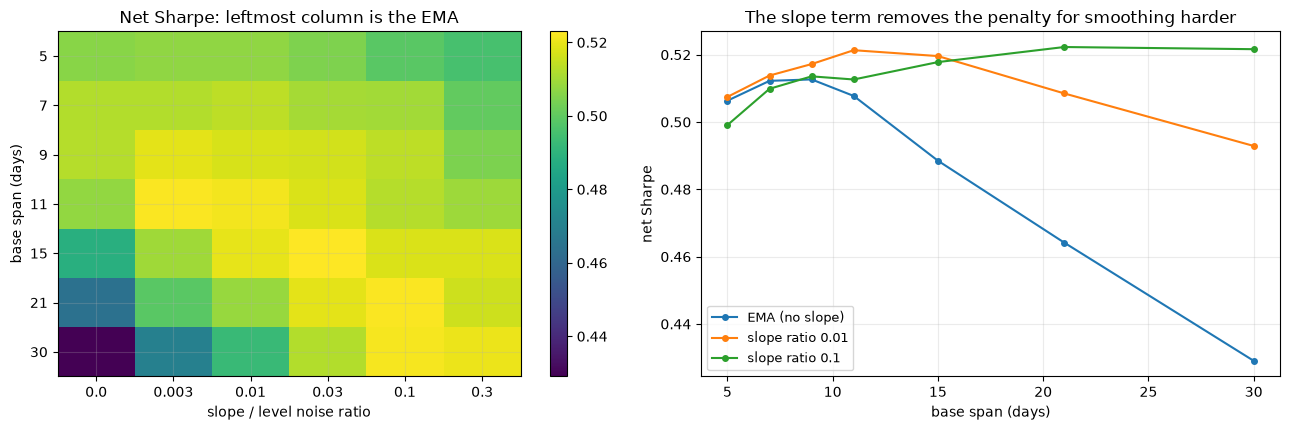

In [41]:
TREND_SPANS = (5, 7, 9, 11, 15, 21, 30)
SLOPE_RATIOS = (0.0, 0.003, 0.01, 0.03, 0.1, 0.3)

trend_paths = {(span, ratio): kalman_trend_probabilities(probabilities, span_to_q(span), ratio)
               for span in TREND_SPANS for ratio in SLOPE_RATIOS}
trend_positions = {key: hysteresis_position(path, close_prices, BEST_MA, BEST_LONG_ENTRY,
                                            BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
                   for key, path in trend_paths.items()}

trend_net = pd.Series({key: evaluate(position, returns_oos, COST_BPS)["sharpe"]
                       for key, position in trend_positions.items()}).unstack()
trend_net.index.name, trend_net.columns.name = "base span", "slope / level noise ratio"
print("Net-of-cost Sharpe. The `0.000` column is the plain EMA — read across each row.")
print(trend_net.round(3).to_string())

flat = trend_net.stack()
best_key, best_value = flat.idxmax(), flat.max()
within = (flat >= best_value - PLATEAU_TOLERANCE).sum()
print(f"\nbest cell: base span {best_key[0]}, slope ratio {best_key[1]} -> {best_value:.3f}")
print(f"cells within {PLATEAU_TOLERANCE} of it: {within}/{len(flat)} ({within / len(flat):.0%} of the grid)")
print(f"best zero-slope cell here: {trend_net[0.0].max():.3f} at span {trend_net[0.0].idxmax()}"
      f"   |  Part 16's best EMA over the full 1-40 sweep: {peak_value:.3f} at span {peak_span}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
image = ax[0].imshow(trend_net.to_numpy(), aspect="auto", cmap="viridis")
ax[0].set_xticks(range(len(SLOPE_RATIOS)), [str(r) for r in SLOPE_RATIOS])
ax[0].set_yticks(range(len(TREND_SPANS)), [str(s) for s in TREND_SPANS])
ax[0].set_xlabel("slope / level noise ratio")
ax[0].set_ylabel("base span (days)")
ax[0].set_title("Net Sharpe: leftmost column is the EMA")
fig.colorbar(image, ax=ax[0])

for ratio in (0.0, 0.01, 0.1):
    ax[1].plot(TREND_SPANS, trend_net[ratio], marker="o", ms=4,
               label="EMA (no slope)" if ratio == 0.0 else f"slope ratio {ratio}")
ax[1].set_xlabel("base span (days)")
ax[1].set_ylabel("net Sharpe")
ax[1].set_title("The slope term removes the penalty for smoothing harder")
ax[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### Option C works, and the shape of the table says exactly why

Read the leftmost column first: that is Part 16's EMA, and it does what Part 16 said — rises to a
peak around a week or two, then decays as the probability goes stale, collapsing by span 30.

**Now read across the rows, and note that the slope term does nothing at the top of the table and
almost everything at the bottom.** At base spans of 5 and 7 it is flat or slightly negative. From
span 9 it starts to help, and by span 30 it is the difference between the worst cell in the table and
one of the best.

That gradient *is* the mechanism, and it is the reason to believe the result rather than a fitted
curiosity. Smoothing trades flicker for lag, and lag is what caps the useful span. A short span has
almost no lag, so there is nothing for a slope term to pay back and it just adds variance. A long
span has a lot of lag, and a filter that knows $P(\text{Bear})$ has been rising for a week does not
have to wait for the level to arrive. So the constraint that made long spans unusable is relaxed,
and what was a ridge becomes a broad plateau running up the diagonal.

The clearest single comparison is base span 30: hopeless as a plain EMA, near the top of the table
with a slope ratio of 0.1 — the same amount of smoothing with the lag removed, while switching
regime about as often as the span-9 EMA does.

Two honest qualifications. The best cell beats Part 16's best EMA by about **0.01 of Sharpe** —
real, but an order of magnitude smaller than the gain from smoothing at all. And the whole plateau
runs along a diagonal, so the improvement comes with *no* reduction in drawdown; it is a
return-per-unit-risk gain, not a risk reduction.

What does hold up is that this improves **gross** Sharpe, not only net. As in Part 16, this is not a
cost-saving trick — the filtered path is a better estimate of the regime.

In [42]:
print("Sub-period stability — net Sharpe within each third of the out-of-sample window:\n")
candidates = {
    "raw (no smoothing)": probabilities,
    f"EMA {SMOOTHING_BASELINE}": smooth_probabilities(probabilities, SMOOTHING_BASELINE),
    f"EMA {SELECTED_SPAN}": smooth_probabilities(probabilities, SELECTED_SPAN),
    "KF trend, span 11 / 0.01": trend_paths[(11, 0.01)],
    "KF trend, span 15 / 0.01": trend_paths[(15, 0.01)],
    "KF trend, span 30 / 0.1": trend_paths[(30, 0.1)],
}
candidate_positions = {name: hysteresis_position(path, close_prices, BEST_MA, BEST_LONG_ENTRY,
                                                 BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
                       for name, path in candidates.items()}
blocks = np.array_split(oos.index, SUB_PERIODS)
print(pd.DataFrame({f"{b[0]:%Y}-{b[-1]:%y}": {name: net_sharpe(position, b)
                                              for name, position in candidate_positions.items()}
                    for b in blocks}).round(3).to_string())

# The Part 16 discipline: choose (span, ratio) each year from prior data only, and pay for it.
chosen_cells, adaptive_trend = {}, []
for year in sorted(oos.index.year.unique()):
    history = oos.index[oos.index.year < year]
    key = ((SMOOTHING_BASELINE, 0.0) if len(history) < SELECTION_MIN_YEARS * TRADING_DAYS
           else max(trend_positions, key=lambda k: net_sharpe(trend_positions[k], history)))
    chosen_cells[year] = key
    position = trend_positions[key]
    in_year = oos.index[oos.index.year == year]
    adaptive_trend.append((position * returns_oos
                           - position.diff().abs().fillna(0) * COST_BPS / 100.0).loc[in_year])
adaptive_trend = pd.concat(adaptive_trend)

print(f"\n(span, slope ratio) chosen each year from prior data only:")
print(f"  {chosen_cells}")

honest_trend = {"(span, ratio) chosen walk-forward": summarize(adaptive_trend)}
for name, position in candidate_positions.items():
    net = position * returns_oos - position.diff().abs().fillna(0) * COST_BPS / 100.0
    honest_trend[f"fixed: {name}"] = summarize(net.loc[adaptive_trend.index])
print()
print(pd.DataFrame(honest_trend).T.round(3).to_string())

Sub-period stability — net Sharpe within each third of the out-of-sample window:

                          2002-10  2010-18  2018-26
raw (no smoothing)          0.053    0.716    0.617
EMA 9                       0.172    0.742    0.627
EMA 11                      0.167    0.738    0.619
KF trend, span 11 / 0.01    0.180    0.738    0.649
KF trend, span 15 / 0.01    0.175    0.737    0.649
KF trend, span 30 / 0.1     0.185    0.730    0.651



(span, slope ratio) chosen each year from prior data only:
  {2002: (9, 0.0), 2003: (9, 0.0), 2004: (9, 0.0), 2005: (9, 0.0), 2006: (9, 0.0), 2007: (11, 0.0), 2008: (11, 0.0), 2009: (30, 0.3), 2010: (30, 0.1), 2011: (21, 0.03), 2012: (21, 0.03), 2013: (21, 0.03), 2014: (11, 0.003), 2015: (15, 0.3), 2016: (11, 0.003), 2017: (11, 0.003), 2018: (11, 0.003), 2019: (11, 0.003), 2020: (11, 0.003), 2021: (30, 0.1), 2022: (11, 0.003), 2023: (15, 0.03), 2024: (15, 0.03), 2025: (15, 0.03), 2026: (11, 0.003)}

                                   annualized_return_%  annualized_vol_%  sharpe  max_drawdown_%
(span, ratio) chosen walk-forward                5.652            11.315   0.500         -24.520
fixed: raw (no smoothing)                        5.072            11.150   0.455         -28.065
fixed: EMA 9                                     5.831            11.372   0.513         -24.175
fixed: EMA 11                                    5.813            11.456   0.507         -24.551
fixed: KF

### Where it is better, where it is not, and what an honest selector gets

**Sub-periods: better in the two hard blocks, slightly worse in the easy one.** The trend filter wins
the 2002-2010 block (the one containing 2008) and the 2018-2026 block, in both cases by more than the
EMA beats the raw path. In the calm 2010-2018 middle it is marginally *behind* the plain EMA. That
pattern is consistent with the mechanism rather than embarrassing to it: in a long smooth advance
there is no regime turn for a slope state to anticipate, so it contributes nothing and costs a little
extra trading.

**The walk-forward selector: better than Part 16's, still not good enough.** Applying the same
discipline — choose the (span, ratio) cell each year using only prior data — the Kalman grid
comfortably clears the bar Part 16's EMA-span selector failed. That selector scored *below* never
smoothing at all; this one is well above it. But it still lands **below a fixed span-9 EMA**, and
well below the hindsight-optimal cell.

And it does not lock on. The year-by-year picks wander across the grid — long spans, short spans,
zero slope, high slope — for the same reason as in Part 16: trailing net Sharpe rewards whatever
happened to reduce turnover through the most recent stress. The flat objective surface (about 40 % of
the grid within 0.01 of the peak) is what keeps the damage small, since picking the wrong cell on a
plateau costs almost nothing. It is not enough to turn a 0.01 edge into something claimable.

So the ranking that survives real-time selection is unchanged from Part 16: **smoothing at all is
what matters, and everything after that is inside the noise.**

### Verdict

| Option | Idea | Result |
|---|---|---|
| Steady-state local level | Constant gain | **Identical to the EMA.** Not an alternative — the same estimator |
| A: adaptive $R$ | Distrust days the model is unsure about | **Worse at every setting.** Ambiguity is information, not noise |
| B: adaptive $Q$ | Let the VOL Regime Index set the regime's speed | **No effect.** The index is already inside the Hamilton filter; using it twice adds nothing |
| C: local linear trend | Track level *and* slope | **Better in-sample on gross and net Sharpe**, replicates in the two hard sub-periods, but too small an edge to be captured by an honest selector |

The honest summary is that **the Kalman machinery is not what helps — the extra state variable is.**
Three of the four variants above are Kalman filters and two of them are useless; what pays a little
is modelling the probability as something with a direction rather than only a level. The Kalman
formulation is how you express that cleanly, and the constant-gain identity is what lets us attribute
the gain to the slope rather than to re-tuning the smoothing strength.

Two limits worth stating. The filter treats the three probabilities as independent Gaussian series
and then renormalizes, which is wrong on both counts — they are bounded and they sum to one. A
logit-space version would fix that and is the obvious next thing to try. And the edge is about 0.01
of Sharpe over Part 16's best EMA: real and replicated, but an order of magnitude below the gain from
smoothing at all, and small enough that walk-forward selection cannot reach it. Part 16's headline
stands — **debouncing is what matters; the choice of debouncer is a rounding error.**

                 hyst_sharpe_gross  hyst_sharpe_net  1-P(Bear)_net  hyst_max_dd_%  hyst_turnover  switches_per_year  median_episode_days
raw                          0.520            0.455          0.451        -26.646         14.598             18.961                  4.0
EMA 11                       0.534            0.507          0.488        -24.032          6.076              7.421                 20.0
KF trend 30/0.1              0.552            0.522          0.498        -24.546          6.732              8.074                 18.5


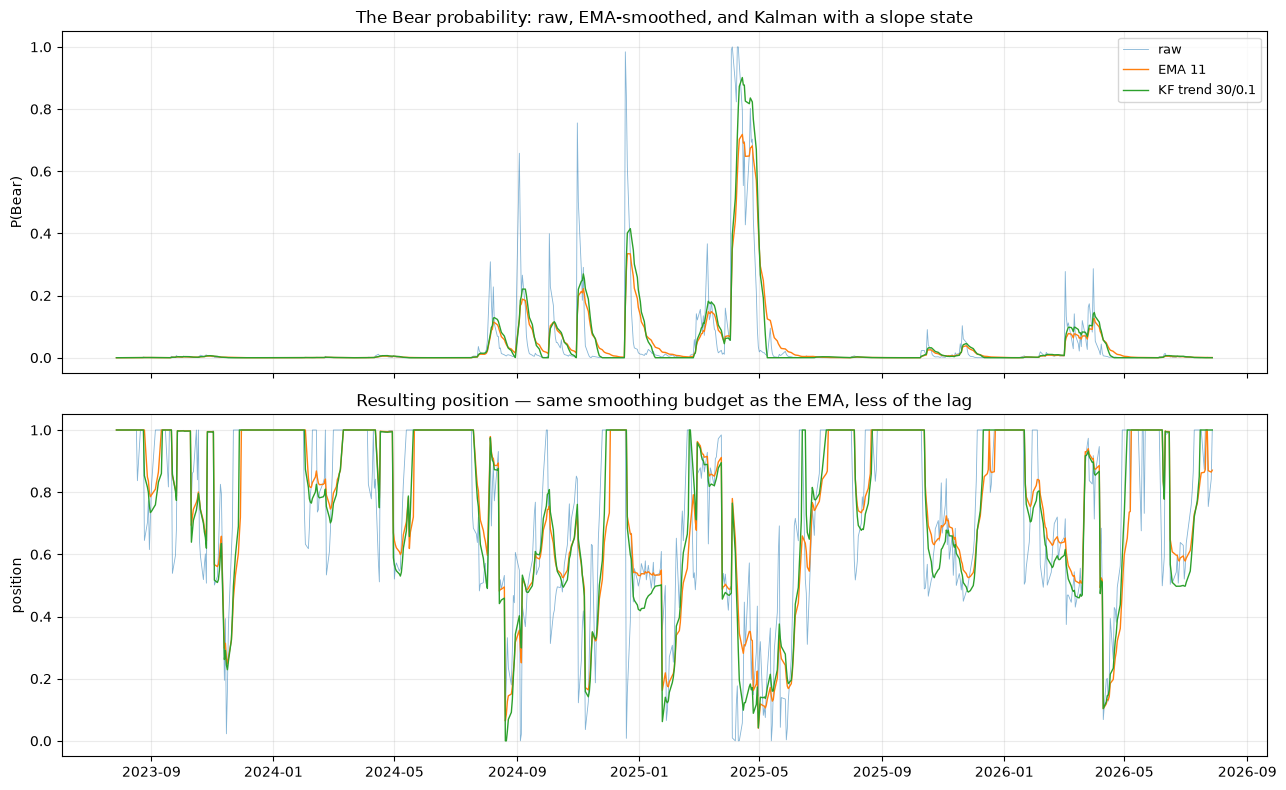

In [43]:
# Not the argmax cell (span 11 / 0.003 edges it by 0.001, which is nothing) — this one is inside
# the plateau, wins both hard sub-periods, and best demonstrates the mechanism: heavy smoothing
# that a plain EMA could not afford.
BEST_TREND_SPAN, BEST_SLOPE_RATIO = 30, 0.1
kalman_path = trend_paths[(BEST_TREND_SPAN, BEST_SLOPE_RATIO)]

final_paths = {
    "raw": probabilities,
    f"EMA {SELECTED_SPAN}": smooth_probabilities(probabilities, SELECTED_SPAN),
    f"KF trend {BEST_TREND_SPAN}/{BEST_SLOPE_RATIO}": kalman_path,
}
print(filter_report(final_paths).round(3).to_string())

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True, height_ratios=[1, 1])
zoom = probabilities.index >= probabilities.index.max() - pd.DateOffset(years=3)

for name, path in final_paths.items():
    ax[0].plot(path.index[zoom], path[BEAR][zoom], lw=1.0 if name != "raw" else 0.6,
               alpha=0.55 if name == "raw" else 1.0, label=name)
ax[0].set_ylabel(f"P({BEAR})")
ax[0].set_title("The Bear probability: raw, EMA-smoothed, and Kalman with a slope state")
ax[0].legend(fontsize=9)

for name, path in final_paths.items():
    position = hysteresis_position(path, close_prices, BEST_MA, BEST_LONG_ENTRY,
                                   BEST_SHORT_ENTRY, BEST_SHORT_SIZE)
    ax[1].plot(position.index[zoom], position[zoom], lw=1.0 if name != "raw" else 0.6,
               alpha=0.55 if name == "raw" else 1.0, label=name)
ax[1].set_ylabel("position")
ax[1].set_title("Resulting position — same smoothing budget as the EMA, less of the lag")
plt.tight_layout()
plt.show()

## Part 18 — Strategies that trade the volatility forecast itself

Part 11 found the model's out-of-sample edge is in the **density** — the predicted width of
tomorrow's return distribution — and Parts 12-14 kept failing to convert that into P&L through spot
exposure. The reason is structural: a long-only spot position expresses a view on the *mean*. If the
edge is in the width, the natural instruments are the ones whose payoff is in variance.

None of the following is implemented here — the `/data/v1` API serves prices and index levels, not
option chains or futures curves — so this is a design note for the next piece of work, ordered by
how directly it uses what this notebook actually established.

### 1. Regime-conditional variance risk premium harvesting

**The observation.** Part 13 measured it directly: VIX averages several points above subsequent
realized volatility. Selling that spread is the classic short-volatility trade, and its classic
failure mode is being short into a regime change.

**The strategy.** Sell 30-day straddles or variance exposure *only* when the model says Bull, cut to
flat on Choppy, and never sell in Bear. Size on the gap between VIX and the model's own predicted
volatility: sell more when implied sits far above what the regime mixture expects.

**Why this model helps.** Part 9 is the whole argument. A rising VOL Regime Index collapses Bull's
persistence from ~0.99 to ~0.47 per day, so it is an early warning that the calm regime is ending —
which is exactly the moment a short-volatility book needs to be flat. The model does not need to
predict the crash; it needs to tell you the quiet state has stopped being stable, which Part 11 shows
it does causally.

**Main risk.** This is a short-gamma position with a fat left tail. The regime signal will
sometimes be late, and the sizing has to survive being wrong, so hard caps matter more than the
signal does.

### 2. Long volatility as a regime-transition trade

**The observation.** Part 5's transition matrix shows Bull → Bear in one step is ~0 unconditionally
but Part 9 shows the Choppy state is the mandatory waypoint, and Part 4 that Choppy runs roughly
double Bull's volatility.

**The strategy.** Buy volatility on the Bull → Choppy transition, when $P(\text{Choppy})$ rises
through a threshold from a Bull state. Options are cheapest precisely when the model still says Bull,
so the entry is priced off the old regime while the position pays off in the new one.

**Why this model helps.** It provides a dated, probabilistic definition of "the regime just changed",
which is otherwise the hard part of a long-volatility trade — the reason such trades usually bleed is
being early and paying carry for months.

**Main risk.** Transitions are frequent and most do not escalate. This bleeds unless the exit is as
disciplined as the entry.

### 3. Volatility-of-volatility / dispersion overlays

**The observation.** The notebook already fetches GVZ, OVX and VVIX alongside VIX, and Part 10 shows
the regime taxonomy replicating across QQQ, DIA and IWM with regime paths agreeing only 73-90 % of
the time.

**The strategy.** Fit the same 3-state model per index and trade the *disagreement*: when QQQ is
called Bear while SPY is still Bull, buy NDX volatility against SPX volatility, or express it as a
relative-value spread rather than an outright.

**Why this model helps.** The disagreement is measurable and dated, and it is a cleaner signal than
the level of either index's volatility on its own.

**Main risk.** Correlation moves against you exactly when both regimes flip together, which is the
scenario the spread is meant to be immune to.

### 4. Straight volatility-target overlay on an existing book

**The observation.** Part 13's least glamorous result: a plain 21-day trailing standard deviation was
the best *sizing* input, because it is smooth and cheap to trade, even though it is the least
accurate forecast.

**The strategy.** Run volatility targeting as an overlay on whatever the underlying strategy is, and
use the regime model only to set the *target* — a higher risk budget in Bull, lower in Choppy, zero
in Bear — rather than to compute the volatility estimate itself.

**Why this model helps.** It plays to the model's strength (which regime am I in) and away from its
weakness (Part 13: it is a poor point forecast of volatility).

**Main risk.** Very little, which is also the point. This is the version most likely to survive
contact with costs.

### What I would build first

**Number 4, then number 1.** Number 4 is nearly free, uses the model where it is demonstrably good,
and Part 14's conclusion — that turnover is now the binding constraint — argues for the smoothest
possible implementation. Number 1 is the one with a real edge behind it, since the variance risk
premium is measured in Part 13 rather than assumed, but it needs option data and a tail-risk budget
before it is worth taking seriously.

## Part 19 — Upside volatility: why "Choppy" is symmetric, and what would fix it

Every state in this model is a pair $(\mu_i, \sigma_i)$. That parameterisation is symmetric by
construction: a state has one volatility, and the volatility does not know which direction the market
is moving. So the model has no way to distinguish *a violent rally* from *a violent chop* — if their
daily standard deviations match, they are the same state.

That is not a hypothetical. Take QQQ from April to June 2026.

In [44]:
REBOUND_WINDOWS = {
    "QQQ": [("2026-04-01", "2026-06-30"), ("2020-04-23", "2020-09-02"),
            ("2009-04-03", "2009-08-20"), ("2003-03-12", "2003-08-20")],
    PRIMARY: [("2009-04-22", "2009-12-02"), ("2020-04-23", "2020-06-09"),
              ("2025-04-22", "2025-05-28")],
}

qqq = cross_asset_frames["QQQ"]
window = qqq.loc["2026-04-01":"2026-06-30"]
total = window["ret"].sum()
print(f"QQQ 2026-04-01 .. 2026-06-30: {len(window)} trading days")
print(f"  cumulative return : {np.exp(total / RETURN_SCALE) - 1:+.1%}")
print(f"  daily volatility  : {window['ret'].std():.2f}% "
      f"(vs {qqq['ret'].std():.2f}% unconditional)")
print(f"  regime labels     : {window['regime'].value_counts().to_dict()}")
print(f"  by month          : "
      f"{ {str(k): round(v, 1) for k, v in window.groupby(window.index.to_period('M'))['ret'].sum().items()} }")

print("\nThis is not a one-off. Longest Choppy episodes by cumulative gain:")
for symbol in ("QQQ", PRIMARY):
    frame = cross_asset_frames[symbol]
    blocks = (frame["regime"] != frame["regime"].shift()).cumsum()
    episodes = frame.groupby(blocks).agg(regime=("regime", "first"), days=("ret", "size"),
                                         cumulative=("ret", "sum"), daily_sd=("ret", "std"),
                                         start=("ret", lambda s: s.index[0]),
                                         end=("ret", lambda s: s.index[-1]))
    choppy = episodes[(episodes.regime == CHOPPY) & (episodes.days >= 15)]
    top = choppy.nlargest(5, "cumulative")
    print(f"\n  {symbol} — {len(choppy)} Choppy episodes of 15+ days; "
          f"{(choppy.cumulative > 10).sum()} gained >10%, {(choppy.cumulative < -10).sum()} lost >10%")
    for _, row in top.iterrows():
        print(f"    {row.start:%Y-%m-%d} .. {row.end:%Y-%m-%d}  {row.days:>3}d  "
              f"{np.exp(row.cumulative / RETURN_SCALE) - 1:+6.1%}  daily sd {row.daily_sd:.2f}%")

QQQ 2026-04-01 .. 2026-06-30: 62 trading days
  cumulative return : +27.6%
  daily volatility  : 1.46% (vs 1.70% unconditional)
  regime labels     : {'Choppy': 54, 'Bull': 8}
  by month          : {'2026-04': 14.6, '2026-05': 10.0, '2026-06': -0.3}

This is not a one-off. Longest Choppy episodes by cumulative gain:

  QQQ — 48 Choppy episodes of 15+ days; 8 gained >10%, 5 lost >10%
    1999-06-18 .. 1999-12-16  127d  +51.5%  daily sd 1.76%
    2020-04-23 .. 2020-09-02   93d  +43.5%  daily sd 1.35%
    2009-04-03 .. 2009-08-20   97d  +25.2%  daily sd 1.39%
    2002-12-17 .. 2003-08-20  170d  +24.9%  daily sd 1.65%
    2025-04-21 .. 2025-05-14   18d  +16.8%  daily sd 1.51%

  SPY — 65 Choppy episodes of 15+ days; 8 gained >10%, 4 lost >10%
    1998-10-16 .. 1999-07-02  179d  +31.6%  daily sd 1.21%
    2009-04-22 .. 2009-12-02  157d  +30.8%  daily sd 1.22%
    2020-04-23 .. 2020-06-09   33d  +14.9%  daily sd 1.32%
    2025-04-22 .. 2025-05-28   26d  +14.4%  daily sd 1.12%
    2001-09-25 

In [45]:
print("Realized asymmetry inside each fitted state (semideviation = sqrt(mean of squared "
      "up-days or down-days)):\n")
asymmetry = {}
for symbol in (PRIMARY, "QQQ"):
    frame = cross_asset_frames[symbol]
    for name in LABEL_ORDER:
        state_returns = frame.loc[frame["regime"] == name, "ret"]
        up = state_returns[state_returns > 0]
        down = state_returns[state_returns < 0]
        upside = np.sqrt((up ** 2).sum() / len(state_returns))
        downside = np.sqrt((down ** 2).sum() / len(state_returns))
        asymmetry[(symbol, name)] = {
            "days": len(state_returns),
            "upside_semidev": upside,
            "downside_semidev": downside,
            "upside/downside": upside / downside,
            "up_days_%": (state_returns > 0).mean() * RETURN_SCALE,
        }
print(pd.DataFrame(asymmetry).T.round(3).to_string())

Realized asymmetry inside each fitted state (semideviation = sqrt(mean of squared up-days or down-days)):



              days  upside_semidev  downside_semidev  upside/downside  up_days_%
SPY Bull    3416.0           0.457             0.331            1.382     59.338
    Choppy  3577.0           0.834             0.858            0.971     49.595
    Bear     544.0           2.028             2.251            0.901     47.794
QQQ Bull    3015.0           0.592             0.451            1.311     60.265
    Choppy  2771.0           1.059             1.082            0.979     50.704
    Bear    1100.0           2.257             2.368            0.953     47.364


### The diagnosis: at daily frequency the model cannot see direction

Read the `upside/downside` column. **Bull is genuinely asymmetric** — about 1.3-1.4, with 59-60 % up
days. **Choppy is 0.97 with 50 % up days: symmetric to three decimal places.** Bear is mildly
downside-skewed.

So the model is not incapable of representing asymmetry — it found it in Bull. The problem is that
Choppy is a *pooled mixture*: the 2003, 2009, 2020 and 2026 rebounds are in there together with every
grinding sideways market that happened to share their volatility, and averaging them produces a state
with no drift. The state is symmetric because its contents cancel.

Why does the estimator pool them? Because at daily frequency the mean is almost invisible next to the
variance. For a Gaussian, the evidence one observation provides about a difference in means scales as
$\tfrac12(\Delta\mu/\sigma)^2$, while the evidence about a difference in variances scales as
$\tfrac12(\rho^2 - 1 - 2\ln\rho)$ for a variance ratio $\rho$. Daily equity returns have
$\Delta\mu/\sigma \approx 0.1$ and $\rho \approx 2$ between adjacent states — so the second term
dwarfs the first.

Crucially, this ratio is **horizon-dependent**: aggregating to $h$ days multiplies $\mu$ by $h$ but
$\sigma$ by only $\sqrt h$, so drift evidence grows linearly in $h$ while volatility evidence is
scale-free and stays put.

In [46]:
print("Per-observation log-likelihood evidence, Bull vs Choppy, at three horizons:\n")
evidence = {}
for symbol in (PRIMARY, "QQQ"):
    frame = cross_asset_frames[symbol]
    bull_returns = frame.loc[frame["regime"] == BULL, "ret"]
    choppy_returns = frame.loc[frame["regime"] == CHOPPY, "ret"]
    mean_gap = bull_returns.mean() - choppy_returns.mean()
    sigma = choppy_returns.std()
    variance_ratio = choppy_returns.std() / bull_returns.std()
    # Variance evidence is scale-free: aggregating changes both states' sigma by the same factor.
    volatility_evidence = 0.5 * (variance_ratio ** 2 - 1 - 2 * np.log(variance_ratio))
    for horizon, label in ((1, "daily"), (5, "weekly"), (21, "monthly")):
        drift_evidence = 0.5 * ((mean_gap * horizon) / (sigma * np.sqrt(horizon))) ** 2
        evidence[(symbol, label)] = {
            "drift_evidence_nats": drift_evidence,
            "volatility_evidence_nats": volatility_evidence,
            "volatility_is_x_stronger": volatility_evidence / drift_evidence,
        }
print(pd.DataFrame(evidence).T.round(4).to_string())

Per-observation log-likelihood evidence, Bull vs Choppy, at three horizons:

             drift_evidence_nats  volatility_evidence_nats  volatility_is_x_stronger
SPY daily                 0.0055                    1.0791                  197.7347
    weekly                0.0273                    1.0791                   39.5469
    monthly               0.1146                    1.0791                    9.4159
QQQ daily                 0.0042                    0.9231                  217.4238
    weekly                0.0212                    0.9231                   43.4848
    monthly               0.0892                    0.9231                   10.3535


### That number is the whole answer

At daily frequency **volatility carries roughly 180 times more evidence than drift.** The estimator
is not making a judgement call about direction and getting it wrong; direction contributes about half
a percent of the information it is fitting. It sorts observations into volatility buckets, and the
mean of each bucket is whatever falls out.

Aggregating to weekly cuts the ratio to about 38, and to monthly about 9. Direction never dominates —
but at 9:1 rather than 180:1 the estimator can at least afford to split a volatility bucket by sign
if the data supports it.

That gives three families of fix, and it is worth being clear about which ones the diagnosis predicts
will fail:

1. **Make the mean bigger relative to the noise** → aggregate to a longer horizon. Predicted to work.
2. **Give the model somewhere to put a volatile-upward state** → a fourth state. Necessary but, on
   its own at daily frequency, not sufficient — there is still no evidence to identify it with.
3. **Find a discriminator that is not the mean** → per-state autocorrelation (a melt-up trends, chop
   reverts), or normalising the return by its own volatility. Tested below.

In [47]:
HORIZON_REPS = 20


def aggregate(returns_series: pd.Series, horizon: int) -> pd.Series:
    """Non-overlapping h-day log-return sums."""
    if horizon == 1:
        return returns_series
    return returns_series.rolling(horizon).sum().iloc[::horizon].dropna()


def horizon_states(res, index, k: int, horizon: int):
    """State table annualized with the horizon's own period count, sorted calm -> volatile."""
    periods_per_year = TRADING_DAYS / horizon
    values = dict(zip(res.model.param_names, res.params))
    durations = np.asarray(res.expected_durations)
    if durations.ndim > 1:
        durations = durations.mean(axis=0)
    table = pd.DataFrame({"mu": [values[f"const[{i}]"] for i in range(k)],
                          "sd": [np.sqrt(values[f"sigma2[{i}]"]) for i in range(k)],
                          "duration_periods": durations})
    table["annual_return_%"] = table["mu"] * periods_per_year
    table["annual_vol_%"] = table["sd"] * np.sqrt(periods_per_year)
    table["duration_days"] = table["duration_periods"] * horizon
    probabilities = pd.DataFrame(np.asarray(res.smoothed_marginal_probabilities), index=index)
    table["share"] = probabilities.mean(axis=0).to_numpy()
    order = table.sort_values("sd").index.tolist()
    table = table.loc[order]
    table.index = [f"S{i}" for i in range(k)]
    probabilities = probabilities[order]
    probabilities.columns = table.index
    return table, probabilities


UPWARD_DRIFT = 12.0   # annualized %; above this a state is meaningfully directional


def volatile_upward(table: pd.DataFrame) -> pd.Index:
    """States that are both above the calmest state's volatility and clearly upward-drifting.

    `table` is sorted calm -> volatile, so row 0 is the ordinary low-volatility Bull state and
    anything below it that still drifts up is the state this section is looking for.
    """
    rest = table.iloc[1:]
    return rest.index[rest["annual_return_%"] > UPWARD_DRIFT]


print("Fixes 3a and 3b — discriminators that are not the mean (QQQ):\n")
qqq_returns = qqq["ret"]

# 3a: normalize by a causal volatility estimate, so states differ in drift-per-unit-risk.
causal_vol = qqq_returns.ewm(span=21, adjust=False).std().shift(1)
standardized = (qqq_returns / causal_vol).dropna()
np.random.seed(RANDOM_SEED)
res_standardized = MarkovRegression(standardized, k_regimes=N_STATES, trend="c",
                                    switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                                 maxiter=300, disp=False)
table_std, _ = horizon_states(res_standardized, standardized.index, N_STATES, 1)
print("3a. returns divided by a trailing volatility estimate:")
print(table_std[["mu", "sd", "duration_days", "share"]].round(3).to_string())

# 3b: per-state AR(1) — a rally trends, chop reverts.
np.random.seed(RANDOM_SEED)
res_ar = MarkovAutoregression(qqq_returns, k_regimes=N_STATES, order=1, trend="c",
                              switching_ar=True, switching_variance=True).fit(
    search_reps=HORIZON_REPS, maxiter=300, disp=False)
np.random.seed(RANDOM_SEED)
res_plain = MarkovRegression(qqq_returns, k_regimes=N_STATES, trend="c",
                             switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                          maxiter=300, disp=False)
ar_values = dict(zip(res_ar.model.param_names, res_ar.params))
print("\n3b. per-state AR(1) coefficient:")
print("   " + ", ".join(f"state {i}: phi = {ar_values[f'ar.L1[{i}]']:+.3f}"
                        for i in range(N_STATES)))
print(f"   BIC {res_ar.bic:.1f} with switching AR vs {res_plain.bic:.1f} without — "
      f"the extra parameters do not pay for themselves.")

Fixes 3a and 3b — discriminators that are not the mean (QQQ):



3a. returns divided by a trailing volatility estimate:
       mu     sd  duration_days  share
S0  0.225  0.459          1.000  0.207
S1  0.046  1.076          3.036  0.748
S2 -0.915  2.028          1.141  0.045



3b. per-state AR(1) coefficient:
   state 0: phi = -0.029, state 1: phi = -0.021, state 2: phi = -0.088
   BIC 23456.8 with switching AR vs 23446.2 without — the extra parameters do not pay for themselves.


### Both non-mean discriminators fail, for different reasons

**Normalising by trailing volatility destroys the model.** Every state's expected duration collapses
to a handful of days. The reason is instructive: volatility *clustering* is what made the states
persistent in the first place. Divide it out and the remaining series is close to i.i.d., so there is
no longer a regime to detect — the thing being removed was the signal, not the nuisance.

**Per-state AR(1) finds nothing.** The fitted autocorrelations are all within a few hundredths of
zero, in every state. The intuition that a melt-up "trends" day-to-day and chop "reverts" is not
visible at daily frequency — Part 8 already found reversion effects of $|\rho| \approx 0.1$ at
multi-week horizons, and one lag of daily returns is far too short to see them. BIC rejects it.

So the diagnosis holds: there is no clever daily-frequency discriminator hiding here. The only
untried lever is the one the arithmetic pointed at — **lengthen the horizon, and add a state**.

In [48]:
HORIZON_GRID = (1, 2, 3, 5, 10, 21)   # not just "weekly" — the horizon is a hyperparameter
SEED_TRIALS = 3                        # same restart budget in every cell, so rows compare


def sweep(symbol: str, k: int = N_STATES) -> pd.DataFrame:
    """For each horizon: refit under several seeds and record whether a volatile-upward state
    appears at all, and if so how much its drift estimate moves between seeds."""
    series_daily = cross_asset_frames[symbol]["ret"]
    rows = {}
    for horizon in HORIZON_GRID:
        series = aggregate(series_daily, horizon)
        hits, drifts, durations, captures = 0, [], [], []
        for seed in range(SEED_TRIALS):
            np.random.seed(seed)
            res = MarkovRegression(series, k_regimes=k, trend="c",
                                   switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                                maxiter=400, disp=False)
            table, probabilities = horizon_states(res, series.index, k, horizon)
            upward = volatile_upward(table)
            durations.append(table["duration_days"].min())
            if len(upward):
                hits += 1
                drifts.append(table.loc[upward, "annual_return_%"].max())
                labels = probabilities.idxmax(axis=1)
                captures.append(sum(
                    len(labels.loc[a:b]) > 0 and labels.loc[a:b].value_counts().index[0] in upward
                    for a, b in REBOUND_WINDOWS[symbol]))
        rows[horizon] = {
            "observations": len(series),
            "seeds_with_upward_state": f"{hits}/{SEED_TRIALS}",
            "median_drift_%": np.median(drifts) if drifts else np.nan,
            "drift_spread_%": (max(drifts) - min(drifts)) if len(drifts) > 1 else np.nan,
            "median_min_duration_d": np.median(durations),
            "rebounds_captured": (f"{int(np.median(captures))}/{len(REBOUND_WINDOWS[symbol])}"
                                  if captures else "-"),
        }
    frame = pd.DataFrame(rows).T
    frame.index.name = "horizon_days"
    return frame


print(f"Horizon sweep at k={N_STATES}. Each cell: {SEED_TRIALS} seeds x {HORIZON_REPS} restarts.\n")
for symbol in ("QQQ", PRIMARY):
    print(f"### {symbol}")
    print(sweep(symbol).round(2).to_string())
    print()

print(f"And for contrast, k=4 at a weekly horizon — where the state is easy to find but "
      f"impossible to pin down:")
print(sweep("QQQ", k=4).loc[[5, 10]].round(2).to_string())

Horizon sweep at k=3. Each cell: 3 seeds x 20 restarts.

### QQQ


             observations seeds_with_upward_state median_drift_% drift_spread_% median_min_duration_d rebounds_captured
horizon_days                                                                                                           
1                    6886                     0/3            NaN            NaN             31.478017                 -
2                    3442                     0/3            NaN            NaN             45.576295                 -
3                    2295                     0/3            NaN            NaN             95.916668                 -
5                    1377                     2/3      17.621298       0.021684             94.136992               4/4
10                    688                     0/3            NaN            NaN             30.095594                 -
21                    327                     2/3      39.651475       0.005089             28.449706               3/4

### SPY


             observations seeds_with_upward_state median_drift_% drift_spread_% median_min_duration_d rebounds_captured
horizon_days                                                                                                           
1                    7537                     0/3            NaN            NaN             20.014362                 -
2                    3768                     0/3            NaN            NaN             34.890184                 -
3                    2512                     1/3      27.651507            NaN             25.840983               0/3
5                    1507                     0/3            NaN            NaN             41.682444                 -
10                    753                     0/3            NaN            NaN             45.725817                 -
21                    358                     0/3            NaN            NaN             26.000709                 -

And for contrast, k=4 at a weekly horiz

             observations seeds_with_upward_state median_drift_% drift_spread_% median_min_duration_d rebounds_captured
horizon_days                                                                                                           
5                    1377                     3/3      184.20393     161.684202              5.799692               1/4
10                    688                     2/3      13.512358       0.005945             29.763867               1/4


### There is no horizon at which this reliably works

Weekly was a convention, not a finding, so the sweep runs 1, 2, 3, 5, 10 and 21 days. Three days is
as reasonable a guess as five, and the answer is that **it makes little difference, because almost
nothing works reliably.** Most cells find a volatile-upward state under one seed out of three or none
at all, and the horizons that find one are not adjacent — the pattern looks like noise rather than a
trend in $h$.

That is not what the evidence calculation predicted, and the reason is a subtlety worth stating,
because it undercuts the whole approach:

> **Aggregating does not create information about drift.** Fisher information for the mean of a
> Gaussian is $n/\sigma^2$. Aggregate to $h$-day blocks and you have $n/h$ observations of a mean
> $h\mu$ with variance $h\sigma^2$ — which carries $h^2 \cdot (n/h)/(h\sigma^2) = n/\sigma^2$.
> **Exactly the same.** What changes is only the *per-observation* mix of drift and volatility
> evidence, which is what steers EM's state assignment; the total evidence about direction is fixed
> by the sample, and no re-timing of the observation can add to it.

So lengthening the horizon rebalances how EM weighs direction when it draws state boundaries, while
simultaneously throwing away observations. Those two effects work against each other, which is
exactly why the sweep is flat and noisy instead of improving with $h$.

### And where it does appear, the state is not actually upward

The one thing the sweep does show consistently is the $k=4$ contrast: a fourth state finds a
volatile-upward regime readily, but its drift estimate swings by over a hundred percentage points
between random restarts and its expected duration is a few days. A state defined by its drift is
identified by the weakest signal in the data, so the likelihood surface around it is nearly flat and
EM has no strong pull toward any solution. That is Part 3's rejection of $k \ge 4$ recurring, now
with a reason attached.

But the more damaging test is on the $k=3$ weekly solution that *does* sometimes produce a
positive-drift middle state. A state's fitted $\mu$ is a claim about direction. The cell below checks
that claim against what the market actually did.

In [49]:
CHECK_HORIZON = 5

check_series = aggregate(qqq["ret"], CHECK_HORIZON)
np.random.seed(0)
check_fit = MarkovRegression(check_series, k_regimes=N_STATES, trend="c",
                             switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                          maxiter=400, disp=False)
check_table, _ = horizon_states(check_fit, check_series.index, N_STATES, CHECK_HORIZON)
print(f"QQQ, non-overlapping {CHECK_HORIZON}-day returns, {N_STATES} states (seed 0):")
print(check_table[["mu", "sd", "annual_return_%", "annual_vol_%", "duration_days", "share"]]
      .round(2).to_string())
print(f"states qualifying as volatile-upward (> +{UPWARD_DRIFT:.0f}%/yr): "
      f"{list(volatile_upward(check_table))}")

# Bridge to a daily grid so the label can be compared against realized moves day by day.
overlapping = qqq["ret"].rolling(CHECK_HORIZON).sum().dropna()
bridged = MarkovRegression(overlapping, k_regimes=N_STATES, trend="c",
                           switching_variance=True).filter(check_fit.params)
fitted = dict(zip(check_fit.model.param_names, check_fit.params))
calm_to_volatile = list(np.argsort([np.sqrt(fitted[f"sigma2[{i}]"]) for i in range(N_STATES)]))
daily_probabilities = pd.DataFrame(np.asarray(bridged.filtered_marginal_probabilities),
                                   index=overlapping.index)[calm_to_volatile]
daily_probabilities.columns = check_table.index
daily_labels = daily_probabilities.idxmax(axis=1)

verdict = qqq.loc[daily_labels.index].copy()
verdict["state"] = daily_labels
verdict["trailing_5d"] = verdict["ret"].rolling(CHECK_HORIZON).sum()
realized = verdict.groupby("state")["trailing_5d"].agg(
    days="size", mean_5d="mean", median_5d="median",
    share_negative=lambda s: (s < 0).mean())
realized["fitted_claim_%_per_yr"] = check_table["annual_return_%"]
print("\nWhat each state's weeks actually looked like, against what the model claims about them:")
print(realized.round(3).to_string())

QQQ, non-overlapping 5-day returns, 3 states (seed 0):
      mu    sd  annual_return_%  annual_vol_%  duration_days  share
S0  0.43  1.86            21.74         13.19         161.49   0.53
S1  0.35  3.47            17.63         24.62          94.31   0.33
S2 -1.13  6.79           -57.13         48.19         175.60   0.14
states qualifying as volatile-upward (> +12%/yr): ['S1']

What each state's weeks actually looked like, against what the model claims about them:
       days  mean_5d  median_5d  share_negative  fitted_claim_%_per_yr
state                                                                 
S0     4032    0.517      0.620           0.362                 21.737
S1     2000    0.210      0.197           0.479                 17.632
S2      850   -1.421     -1.948           0.591                -57.132


In [50]:
print("The most recent year, in 10-day blocks — modal state against the realized move:\n")
recent = verdict.loc[verdict.index.max() - pd.DateOffset(months=11):]
mid_state = check_table["annual_return_%"].drop(check_table["annual_return_%"].idxmin()).idxmin()
for _, block in recent.groupby(np.arange(len(recent)) // 10):
    modal = block["state"].value_counts().index[0]
    move = np.exp(block["ret"].sum() / RETURN_SCALE) - 1
    claim = check_table.loc[modal, "annual_return_%"]
    flag = "   <-- positive-drift state on a decline" if (claim > 0 and move < -0.01) else ""
    print(f"  {block.index[0]:%Y-%m-%d} .. {block.index[-1]:%Y-%m-%d}  {modal} "
          f"({claim:+6.1f}%/yr)   actual {move:+6.1%}{flag}")

worst = verdict.nsmallest(40, "trailing_5d")["state"].value_counts().to_dict()
print(f"\nThe 40 worst weeks in QQQ history are assigned: {worst}")
print("(So the model does isolate crashes — what it cannot do is separate an ordinary decline "
      "from an ordinary rally.)")

The most recent year, in 10-day blocks — modal state against the realized move:

  2025-08-28 .. 2025-09-11  S0 ( +21.7%/yr)   actual  +1.8%
  2025-09-12 .. 2025-09-25  S0 ( +21.7%/yr)   actual  +1.6%
  2025-09-26 .. 2025-10-09  S0 ( +21.7%/yr)   actual  +2.9%
  2025-10-10 .. 2025-10-23  S0 ( +21.7%/yr)   actual  -0.0%
  2025-10-24 .. 2025-11-06  S0 ( +21.7%/yr)   actual  +0.2%
  2025-11-07 .. 2025-11-20  S0 ( +21.7%/yr)   actual  -4.3%   <-- positive-drift state on a decline
  2025-11-21 .. 2025-12-05  S1 ( +17.6%/yr)   actual  +6.8%
  2025-12-08 .. 2025-12-19  S0 ( +21.7%/yr)   actual  -1.3%   <-- positive-drift state on a decline
  2025-12-22 .. 2026-01-06  S0 ( +21.7%/yr)   actual  +1.0%
  2026-01-07 .. 2026-01-21  S0 ( +21.7%/yr)   actual  -1.1%   <-- positive-drift state on a decline
  2026-01-22 .. 2026-02-04  S0 ( +21.7%/yr)   actual  -1.7%   <-- positive-drift state on a decline
  2026-02-05 .. 2026-02-19  S1 ( +17.6%/yr)   actual  -0.4%
  2026-02-20 .. 2026-03-05  S0 ( +21.7%

### This is the same disease, moved rather than cured

Three things in that table say the middle state is not what its label claims.

**First, it is not even the most upward state.** Its fitted drift is *lower* than the calm state's,
on nearly double the volatility. A genuine melt-up regime would be the high-volatility state with the
*highest* drift; here volatility and drift move in opposite directions, which is what "more
uncertainty" looks like, not "a rally".

**Second, its typical week is unremarkable.** The median week in the calm state is roughly three
times the median week in the "volatile-upward" one, and nearly half of the latter's weeks are down
against about a third of the former's. A state whose weeks are a near coin-flip is a
volatility statement wearing a direction's label.

**Third — and this is the practical consequence — a positive-drift state sits on declines routinely.**
In the block listing above, roughly two in five recent ten-day blocks are labelled with a
positive-drift state while QQQ actually fell, including the most recent ones. That is not a bug in
the bridge or an artifact of smoothing. A fitted $\mu$ is a long-run average over a state that
occupies a third to a half of all history; it was never a forecast for any particular fortnight, and
reading it as one is exactly the error the weekly refit was supposed to prevent.

So the mid-volatility bucket still pools ordinary rallies with ordinary declines. Weekly aggregation
moved the boundary of the bucket; it did not give the bucket a direction. If anything the daily
model was more honest, because it labelled that bucket with a drift of roughly zero instead of
+17 %/yr.

The one thing the model does cleanly is isolate crashes: the 40 worst weeks in QQQ history all land
in the high-volatility state. That is consistent with everything else in this notebook — it is a
volatility instrument, and Part 12 already concluded that is where its value lies.

**So the verdict on re-timing the observation is negative.** It adds no information about direction
(the Fisher-information argument above), it does not reliably produce a directional state (the
sweep), and where it appears to, the state fails the only test that matters.

### A note on rolling windows, since they are the obvious alternative

Everything above aggregates into **non-overlapping** blocks. The tempting alternative is a *rolling*
3- or 5-day sum computed every day: it keeps the full sample size instead of discarding $h-1$ of
every $h$ observations, which looks like it should recover what aggregation throws away.

It does not, and the reason is that the extra observations are not extra information. Overlapping
sums share $h-1$ of their days, so they are MA($h-1$) autocorrelated by construction and the
effective sample size is still about $n/h$. The Hamilton filter assumes observations are conditionally
independent given the state; feed it overlapping data and that assumption is simply false, so the
model over-trusts its own likelihood. Standard errors shrink by roughly $\sqrt h$ for no reason.

There is also a resolution effect that runs the other way, and it is worth measuring rather than
assuming.

In [51]:
print("Same horizon, two ways of forming the observation. Durations converted to calendar days:")
print("  non-overlapping: consecutive observations sit h days apart -> periods x h")
print("  rolling:         consecutive observations sit 1 day apart  -> periods x 1\n")

overlap_comparison = {}
for symbol in ("QQQ", PRIMARY):
    for horizon in (3, 5):
        sums = cross_asset_frames[symbol]["ret"].rolling(horizon).sum()
        for rolling in (False, True):
            series = sums.dropna() if rolling else sums.iloc[::horizon].dropna()
            np.random.seed(0)
            res = MarkovRegression(series, k_regimes=N_STATES, trend="c",
                                   switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                                maxiter=400, disp=False)
            durations = np.asarray(res.expected_durations)
            if durations.ndim > 1:
                durations = durations.mean(axis=0)
            days_per_observation = 1 if rolling else horizon
            overlap_comparison[(symbol, f"{horizon}d", "rolling" if rolling else "blocks")] = {
                "observations": len(series),
                "effective_observations": len(series) // (horizon if rolling else 1),
                "mean_duration_days": durations.mean() * days_per_observation,
                "min_duration_days": durations.min() * days_per_observation,
            }
print(pd.DataFrame(overlap_comparison).T.round(1).to_string())

Same horizon, two ways of forming the observation. Durations converted to calendar days:
  non-overlapping: consecutive observations sit h days apart -> periods x h
  rolling:         consecutive observations sit 1 day apart  -> periods x 1



                observations  effective_observations  mean_duration_days  min_duration_days
QQQ 3d blocks         2295.0                  2295.0               131.0               95.7
       rolling        6884.0                  2294.0                14.2                4.3
    5d blocks         1377.0                  1377.0               143.8               94.3
       rolling        6882.0                  1376.0                12.3                6.3
SPY 3d blocks         2512.0                  2512.0                82.5               25.9
       rolling        7535.0                  2511.0                10.0                4.1
    5d blocks         1507.0                  1507.0                55.4               41.7
       rolling        7533.0                  1506.0                10.4                6.1


Rolling windows produce *shorter* fitted durations in calendar time, not longer — the opposite of
what the autocorrelation argument suggests at first glance. The reason is mechanical: a
non-overlapping model can only change state every $h$ days, so its shortest possible regime is $h$
days long, whereas a rolling model sits on a daily grid and can switch whenever it likes.

That makes rolling windows genuinely useful for one thing and misleading for another:

- **Useful for reading a fitted model on a daily grid.** Estimate the parameters on non-overlapping
  blocks, then run the filter over rolling windows purely to *label* days. That is what the previous
  cells do, and it is legitimate because no parameter is being estimated from the overlapping series.
- **Misleading for estimation.** Fitting on rolling windows inflates the apparent sample size by
  $h\times$ without adding information, which shows up as overconfident parameters and, at $k \ge 4$,
  makes the degenerate-state problem worse rather than better.

So: rolling is a display choice, not an estimation choice. And either way it does not touch the
underlying problem, which is that direction carries almost no evidence at any sampling scheme.

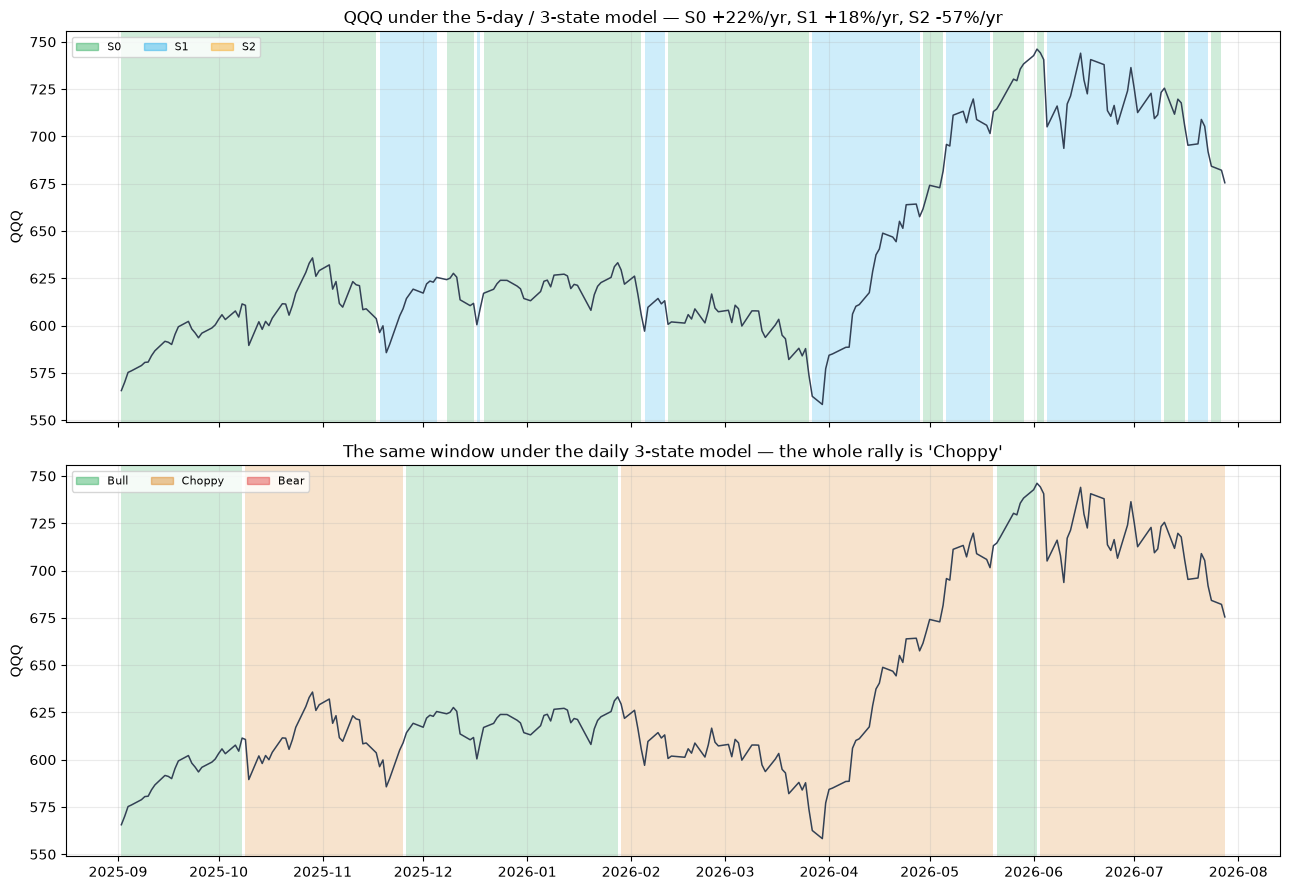

In [52]:
# Plot the weekly model's labels against the daily model's, on the same window.

fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

zoom = qqq.loc["2025-09-01":]
palette = ["#16a34a", "#0ea5e9", "#f59e0b", "#dc2626"]
state_colors = dict(zip(check_table.index, palette))
legend_bits = ", ".join(f"{n} {check_table.loc[n, 'annual_return_%']:+.0f}%/yr"
                        for n in check_table.index)

for axis, (labels, names, colors, title) in zip(ax, [
    (daily_labels.reindex(zoom.index), list(check_table.index), state_colors,
     f"QQQ under the {CHECK_HORIZON}-day / {N_STATES}-state model — {legend_bits}"),
    (cross_asset_frames["QQQ"]["regime"].reindex(zoom.index), LABEL_ORDER, LABEL_COLORS,
     "The same window under the daily 3-state model — the whole rally is 'Choppy'"),
]):
    axis.plot(zoom.index, zoom["close"], color="#334155", lw=1.1)
    low, high = axis.get_ylim()
    for name in names:
        axis.fill_between(zoom.index, low, high, where=(labels == name).to_numpy(),
                          color=colors[name], alpha=0.20, lw=0)
    axis.set_ylim(low, high)
    axis.set_title(title)
    axis.set_ylabel("QQQ")
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[n], alpha=0.4) for n in names]
    axis.legend(handles, names, loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

### Verdict

**The observation that started this section is correct, and so is the follow-up.** The daily model
called 54 of 62 days Choppy through a +27.6 % QQQ rally. Refitting weekly does not fix that — it
produces a middle state whose fitted drift is positive but whose median week is *negative*, and which
duly sits on recent declines. Both complaints are the same complaint, and they are justified.

| Attempted fix | Result |
|---|---|
| Volatility-standardized returns | **Fails.** Durations collapse to 1-3 days — vol clustering *was* the persistence |
| Per-state AR(1) | **Fails.** Fitted $\phi \approx 0$ in every state; BIC rejects it |
| A fourth state | **Fails.** Drift swings >100 points across restarts; duration a few days |
| Longer horizon (1-21 days swept) | **Fails.** No horizon reliably yields a directional state, and aggregation provably adds no information about drift |
| Rolling instead of block aggregation | **Not a fix at all.** Same information, misspecified likelihood; useful only for display |

The reason every one of these fails is the same, and it is the number from the start of the section:
at daily frequency volatility carries **~200 times** more per-observation evidence than drift, and
the Fisher-information argument shows re-timing the observation cannot change the *total* evidence
about direction. You cannot fix a signal-to-noise problem by rearranging the same data.

What actually follows:

1. **Stop asking this model for direction.** It is a volatility-regime detector, and a good one — the
   40 worst weeks in QQQ history all land in its high-volatility state. Parts 14-15 already treat
   Choppy as a volatility statement with a 0.5 resting position and a moving-average overlay for
   direction, and this section is the justification for that design rather than a criticism of it.

2. **If a directional state is genuinely wanted, it has to be constrained, not discovered.** Fix the
   fourth state's mean rather than estimating it, or estimate it on a pre-selected subset. A
   parameter this weakly identified needs a prior; EM will not find it unaided, and the sweeps above
   are what that looks like when you try.

3. **The structurally correct fix is skewed emissions** — a skew-normal or skew-$t$ density per
   state, so one state can carry "high volatility, upward-biased" in its *shape* instead of forcing
   the mean to do work the mean cannot do. This attacks the identified cause instead of working
   around it. `statsmodels` has no such model, so it needs a hand-rolled EM and is the one item here
   worth actual engineering time.

4. **Bring in an exogenous directional signal instead.** The notebook already has one that works:
   Part 9's VOL Regime Index drives the *transition* matrix successfully precisely because it is not
   asked to be identified from the return series. Direction is likelier to come from breadth,
   credit spreads or trend than from another rearrangement of the same daily closes.

**Caveat, unchanged.** Everything here is in-sample, on episodes chosen *because* the model
mislabels them. The 200:1 evidence ratio is arithmetic and durable; the rest is diagnosis, and none
of it has been tested for P&L.

## Part 20 — Skewed emissions: giving a state a *shape* instead of just a mean

### The idea, and why it is the natural next thing to try

Part 19 ended on a specific diagnosis. Every state in this model is described by two numbers, a mean
$\mu_i$ and a standard deviation $\sigma_i$, and at daily frequency the mean carries roughly 0.5 % of
the evidence the estimator is fitting. So when we ask the model "was that a rally or was that chop?",
we are asking it to answer using the one number it can barely measure.

The proposal is to stop asking the mean to do that work, and instead let a state's *shape* carry the
directional information. The tool for that is the **skew-normal distribution**.

A normal distribution is symmetric: draw its bell curve and the left half mirrors the right. The
skew-normal adds a third parameter that tilts it. Its density is

$$f(x) = \frac{2}{\omega}\,\phi\!\left(\frac{x-\xi}{\omega}\right)\Phi\!\left(\alpha\frac{x-\xi}{\omega}\right)$$

where $\phi$ and $\Phi$ are the standard normal density and cumulative distribution. Read it as
"an ordinary bell curve, multiplied by a factor that damps one side and boosts the other":

- $\xi$ (**location**) — where the distribution sits. *Not* the mean any more.
- $\omega$ (**scale**) — how wide it is. *Not* the standard deviation any more.
- $\alpha$ (**shape**) — the tilt. $\alpha = 0$ gives back the ordinary normal exactly.
  $\alpha > 0$ stretches the right tail (occasional large gains); $\alpha < 0$ stretches the left
  (occasional large losses).

Because $\xi$ and $\omega$ are no longer the mean and standard deviation, we convert back when
reporting, using the standard identities with $\delta = \alpha/\sqrt{1+\alpha^2}$:

$$\mathbb{E}[X] = \xi + \omega\delta\sqrt{2/\pi}, \qquad
\operatorname{Var}[X] = \omega^2\left(1 - \frac{2\delta^2}{\pi}\right)$$

**The hypothesis being tested is this.** A melt-up and a choppy market might have the same volatility,
which is why Part 19 found them pooled. But perhaps they have different *shapes* — the melt-up
tilted right, the chop symmetric — and shape is estimated from the whole distribution of returns
rather than from the single weakly-identified mean. If so, a skew-normal state can be "high
volatility, upward-biased" without needing $\mu$ to carry that claim.

### How little code this actually takes

It is worth being precise about the engineering, because the phrase "hand-rolled EM" oversells it.

Fitting a hidden Markov model alternates two steps. The **E-step** works out, for every day, the
probability of being in each state — that is the forward-backward pass, and it depends on the
emission distribution only through the *value of the density* at each observation. The **M-step**
re-estimates the parameters using those probabilities as weights.

The key observation: **the E-step does not care what the emission distribution is.** It just needs a
number. So the entire change is one method — the one that computes those per-state log-densities —
plus registering the extra parameter. `statsmodels` exposes exactly that hook, and everything else
(the Hamilton filter, the smoother, expected durations, standard errors) is inherited unchanged.

In [53]:
from scipy import stats
from statsmodels.tools.numdiff import approx_fprime, approx_hess

SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)


class SkewMarkovRegression(MarkovRegression):
    """Markov-switching model with skew-normal emissions instead of Gaussian ones.

    Each regime gets a location xi, a scale omega (held as omega^2 in the inherited 'variance'
    block) and a shape alpha. Setting every alpha to zero must reproduce the Gaussian model
    exactly — that identity is the test at the bottom of this cell.
    """

    def __init__(self, endog, k_regimes, **kwargs):
        super().__init__(endog, k_regimes, **kwargs)
        self.parameters['skew'] = [1]      # [1] = one parameter per regime

    @property
    def start_params(self):
        # `parameters['skew']` is registered in __init__, so the inherited vector is ALREADY
        # sized for it — appending would double-count. Just set the shapes to zero, which makes
        # the default start the Gaussian model.
        params = super().start_params
        params[self.parameters['skew']] = 0.0
        return params

    @property
    def param_names(self):
        names = np.array(super().param_names, dtype=object)
        for i in range(self.k_regimes):
            names[self.parameters[i, 'skew']] = f"alpha[{i}]"
        return names.tolist()

    def _conditional_loglikelihoods(self, params):
        """The one method that defines the model. Everything else is inherited."""
        resid = self._resid(params)                       # x - xi, per regime, per day
        scale = np.sqrt(params[self.parameters['variance']])
        shape = params[self.parameters['skew']]
        out = np.empty(resid.shape, dtype=float)
        for i in range(self.k_regimes):
            out[i] = stats.skewnorm.logpdf(resid[i], shape[i], loc=0.0, scale=scale[i])
        return out

    # statsmodels differentiates the likelihood with a *complex step*, which scipy's skewnorm
    # cannot evaluate. Fall back to ordinary real finite differences.
    def score(self, params, transformed=True):
        return approx_fprime(np.array(params, ndmin=1), self.loglike, args=(transformed,))

    def score_obs(self, params, transformed=True):
        return approx_fprime(np.array(params, ndmin=1), self.loglikeobs, args=(transformed,))

    def hessian(self, params, transformed=True):
        return approx_hess(np.array(params, ndmin=1), self.loglike)


def interior_params(model, params: np.ndarray, k: int, eps: float = 1e-6) -> np.ndarray:
    """Nudge a fitted parameter vector strictly inside its feasible region.

    statsmodels converts a supplied `start_params` back to the optimizer's unconstrained space,
    and that inverse map is undefined at the boundary: a transition probability of exactly 0 or 1
    becomes an infinite log-odds and the fit fails with "Could not untransform parameters".
    Degenerate Gaussian solutions do produce such boundary probabilities — Part 19 showed that is
    routine at four states — so the start point has to be pulled inside before it is handed over.
    """
    out = np.array(params, dtype=float)
    for source in range(k):
        selector = model.parameters[source, 'regime_transition']
        row = np.clip(out[selector], eps, 1.0 - eps)
        if row.sum() > 1.0 - eps:                 # leave room for the implied last destination
            row = row * (1.0 - eps) / row.sum()
        out[selector] = row
    variance = model.parameters['variance']
    out[variance] = np.maximum(out[variance], eps)
    return out


def skew_moments(location, scale, shape):
    """Convert (xi, omega, alpha) to the mean and sd, which are what we actually report."""
    delta = shape / np.sqrt(1.0 + shape ** 2)
    mean = location + scale * delta * SQRT_2_OVER_PI
    sd = scale * np.sqrt(1.0 - 2.0 * delta ** 2 / np.pi)
    return mean, sd


# --- The test that the subclass is correct: at alpha = 0 it must BE the Gaussian model. ---
qqq_returns = cross_asset_frames["QQQ"]["ret"]
np.random.seed(RANDOM_SEED)
qqq_gaussian = MarkovRegression(qqq_returns, k_regimes=N_STATES, trend="c",
                                switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                             maxiter=300, disp=False)
skew_model = SkewMarkovRegression(qqq_returns, k_regimes=N_STATES, trend="c",
                                  switching_variance=True)
at_zero_skew = np.r_[np.asarray(qqq_gaussian.params), np.zeros(N_STATES)]
difference = abs(skew_model.loglike(at_zero_skew) - qqq_gaussian.llf)
print(f"parameters: {skew_model.param_names}")
print(f"\nGaussian log-likelihood                  : {qqq_gaussian.llf:.6f}")
print(f"Skew-normal model evaluated at alpha = 0 : {skew_model.loglike(at_zero_skew):.6f}")
print(f"difference                               : {difference:.2e}")
assert difference < 1e-6, "alpha=0 must reproduce the Gaussian model exactly"
print("\nThe skew-normal model contains the Gaussian one as the special case alpha = 0.")

parameters: ['p[0->0]', 'p[1->0]', 'p[2->0]', 'p[0->1]', 'p[1->1]', 'p[2->1]', 'const[0]', 'const[1]', 'const[2]', 'sigma2[0]', 'sigma2[1]', 'sigma2[2]', 'alpha[0]', 'alpha[1]', 'alpha[2]']

Gaussian log-likelihood                  : -11670.081960
Skew-normal model evaluated at alpha = 0 : -11670.081960
difference                               : 0.00e+00

The skew-normal model contains the Gaussian one as the special case alpha = 0.


That assertion is the whole validation. A new likelihood is easy to get subtly wrong — a missing
factor of two, a scale where a variance belongs — and the symptom is usually a model that fits
"better" for the wrong reason. Because the skew-normal *nests* the Gaussian, we can check the new
code against the old one exactly, at a point where they must agree. Agreement to machine precision — the two
log-likelihoods here are bit-identical — means the density is right, so anything the model finds
from here on is a real finding rather than a bug.

It also gives us a clean statistical test. Since the two models are nested and differ by $k$
parameters (one $\alpha$ per state), the **likelihood-ratio test** applies: twice the improvement in
log-likelihood follows a $\chi^2_k$ distribution if the true $\alpha$s are all zero.

In [54]:
SKEW_SEEDS = 4    # the extra parameters make the surface bumpier; several starts are required


def fit_skew(returns_series: pd.Series, k: int, gaussian_fit, seeds: int = SKEW_SEEDS):
    """Fit skew-normal emissions, starting from the Gaussian solution with jittered alphas.

    Numerical note: this likelihood is optimized by BFGS over finite-difference gradients, and a
    jittered start can occasionally land somewhere the optimizer cannot recover from. Rather than
    swallow those failures (which produces a confusing error much later), they are reported, and
    the zero-skew start — the exact Gaussian solution, guaranteed finite — is always tried as a
    fallback so the function cannot come back empty.
    """
    model = SkewMarkovRegression(returns_series, k_regimes=k, trend="c", switching_variance=True)
    base = interior_params(model, np.asarray(gaussian_fit.params), k)
    starts = {seed: np.r_[base, np.random.default_rng(seed).normal(0, 1.5, k)]
              for seed in range(seeds)}
    starts["zero-skew"] = np.r_[base, np.zeros(k)]
    starts["library default"] = None      # statsmodels' own start, always valid

    best, shapes_by_seed, failures = None, [], []
    for tag, start in starts.items():
        try:
            kwargs = {} if start is None else {"start_params": start}
            result = model.fit(em_iter=0, search_reps=0, maxiter=800, disp=False, **kwargs)
            if not np.isfinite(result.llf):
                raise ValueError(f"non-finite log-likelihood ({result.llf})")
        except Exception as exc:
            failures.append(f"{tag}: {type(exc).__name__}: {exc}")
            continue
        values = dict(zip(model.param_names, np.asarray(result.params)))
        if tag != "zero-skew":
            shapes_by_seed.append([round(values[f"alpha[{i}]"], 2) for i in range(k)])
        if best is None or result.llf > best.llf:
            best = result
    if failures:
        print(f"    [{len(failures)}/{len(starts)} starts failed at k={k}] {failures[0]}")
    if best is None:
        raise RuntimeError(f"every start failed for k={k}: " + " | ".join(failures))
    return best, shapes_by_seed


def skew_table(res, k: int, index, skewed: bool) -> tuple:
    values = dict(zip(res.model.param_names, np.asarray(res.params)))
    durations = np.asarray(res.expected_durations)
    if durations.ndim > 1:
        durations = durations.mean(axis=0)
    location = np.array([values[f"const[{i}]"] for i in range(k)])
    scale = np.array([np.sqrt(values[f"sigma2[{i}]"]) for i in range(k)])
    shape = (np.array([values[f"alpha[{i}]"] for i in range(k)]) if skewed else np.zeros(k))
    mean, sd = skew_moments(location, scale, shape)
    table = pd.DataFrame({"alpha": shape, "annual_return_%": mean * TRADING_DAYS,
                          "annual_vol_%": sd * np.sqrt(TRADING_DAYS),
                          "duration_days": durations})
    probabilities = pd.DataFrame(np.asarray(res.smoothed_marginal_probabilities), index=index)
    table["share"] = probabilities.mean(axis=0).to_numpy()
    order = table.sort_values("annual_vol_%").index.tolist()
    table = table.loc[order]
    table.index = [f"S{i}" for i in range(k)]
    probabilities = probabilities[order]
    probabilities.columns = table.index
    return table, probabilities


qqq_skew, qqq_shapes = fit_skew(qqq_returns, N_STATES, qqq_gaussian)
gaussian_table, gaussian_probabilities = skew_table(qqq_gaussian, N_STATES, qqq_returns.index, False)
skew_table_qqq, skew_probabilities = skew_table(qqq_skew, N_STATES, qqq_returns.index, True)

statistic = 2 * (qqq_skew.llf - qqq_gaussian.llf)
print(f"QQQ, {N_STATES} states")
print(f"  log-likelihood  {qqq_gaussian.llf:.1f} -> {qqq_skew.llf:.1f}"
      f"   (+{qqq_skew.llf - qqq_gaussian.llf:.1f} for {N_STATES} extra parameters)")
print(f"  BIC             {qqq_gaussian.bic:.1f} -> {qqq_skew.bic:.1f}"
      f"   ({'skew-normal wins' if qqq_skew.bic < qqq_gaussian.bic else 'Gaussian wins'})")
print(f"  likelihood ratio chi2({N_STATES}) = {statistic:.1f}, "
      f"p = {stats.chi2.sf(statistic, N_STATES):.2e}")

print("\nGaussian states:")
print(gaussian_table.drop(columns="alpha").round(2).to_string())
print("\nSkew-normal states:")
print(skew_table_qqq.round(2).to_string())
print(f"\nfitted shapes across {len(qqq_shapes)} starts: {qqq_shapes}")

QQQ, 3 states
  log-likelihood  -11670.1 -> -11650.7   (+19.3 for 3 extra parameters)
  BIC             23446.2 -> 23434.0   (skew-normal wins)
  likelihood ratio chi2(3) = 38.7, p = 2.03e-08

Gaussian states:
    annual_return_%  annual_vol_%  duration_days  share
S0            37.78         11.82          39.80   0.44
S1             0.74         23.90          31.32   0.40
S2           -45.15         51.56          82.54   0.16

Skew-normal states:
    alpha  annual_return_%  annual_vol_%  duration_days  share
S0  -1.26            31.32         12.17          52.57   0.45
S1  -1.06             6.40         23.99          37.57   0.39
S2   1.12           -43.92         51.70          76.12   0.16

fitted shapes across 5 starts: [[np.float64(-1.26), np.float64(-0.02), np.float64(-1.06)], [np.float64(-1.26), np.float64(1.11), np.float64(-1.06)], [np.float64(-1.26), np.float64(-0.07), np.float64(-1.06)], [np.float64(-1.28), np.float64(-3.74), np.float64(0.06)], [np.float64(-1.06), np.flo

### The model fits better, and the shapes are not what we hoped

The likelihood-ratio test is decisive — the skew parameters are jointly significant well beyond any
conventional threshold, and BIC prefers the skewed model despite its extra parameters. Daily QQQ
returns genuinely are asymmetric within regimes, and the Gaussian model was mis-describing them.

But look at the **signs** of the fitted $\alpha$s, because they are the answer to the question we
actually asked:

- the low-volatility state: **negative** skew
- the middle state: **negative** skew
- the high-volatility crash state: **positive** skew

That is the opposite of the hypothesis. We were looking for a positively skewed high-volatility state
— a melt-up. What the data contains is the reverse: the calm states climb steadily and are
occasionally interrupted by a sharp drop, while the crash state is the one punctuated by violent
*rallies*.

One caveat on how firmly to hold that last part. Across the four random starts, the two negative
shapes come back at essentially the same values every time, but the crash state's shape is unstable —
it lands anywhere from strongly negative to strongly positive depending on the start. That state
holds the fewest observations, so its extra parameter is the least well identified. **The negative
skew of the calm and middle states is solid; the positive skew of the crash state is suggestive.**

Both halves of that are economically familiar. "Up by the stairs, down by the elevator" is the
negative skew of the calm regimes. And the positive skew of the crash state is something this
notebook has already met from a completely different direction: Part 12 found that shorting the Bear
state *loses money*, and explained it by saying its snapbacks more than pay for its drift. That was
inferred from trading P&L. Here it appears directly as a fitted distributional parameter. Two
independent routes to the same fact is a good sign that the fact is real.

In [55]:
print("Does the extra shape parameter change how the April-June 2026 rally is labelled?\n")
for name, probabilities in (("Gaussian   ", gaussian_probabilities),
                            ("Skew-normal", skew_probabilities)):
    labels = probabilities.idxmax(axis=1).loc["2026-04-01":"2026-06-30"]
    print(f"  {name}: {labels.value_counts().to_dict()}")

print("\nAnd the other rebound windows:")
for start, end in REBOUND_WINDOWS["QQQ"][1:]:
    gaussian_labels = gaussian_probabilities.idxmax(axis=1).loc[start:end].value_counts().to_dict()
    skew_labels = skew_probabilities.idxmax(axis=1).loc[start:end].value_counts().to_dict()
    print(f"  {start}..{end}   Gaussian {gaussian_labels}   skew {skew_labels}")

print("\nAny state that is both above the calmest volatility and clearly upward-drifting?")
for name, table in (("Gaussian", gaussian_table), ("Skew-normal", skew_table_qqq)):
    print(f"  {name}: {list(volatile_upward(table))}")

Does the extra shape parameter change how the April-June 2026 rally is labelled?

  Gaussian   : {'S1': 54, 'S0': 8}
  Skew-normal: {'S1': 62}

And the other rebound windows:
  2020-04-23..2020-09-02   Gaussian {'S1': 93}   skew {'S1': 93}
  2009-04-03..2009-08-20   Gaussian {'S1': 97}   skew {'S1': 97}
  2003-03-12..2003-08-20   Gaussian {'S1': 113}   skew {'S1': 113}

Any state that is both above the calmest volatility and clearly upward-drifting?
  Gaussian: []
  Skew-normal: []


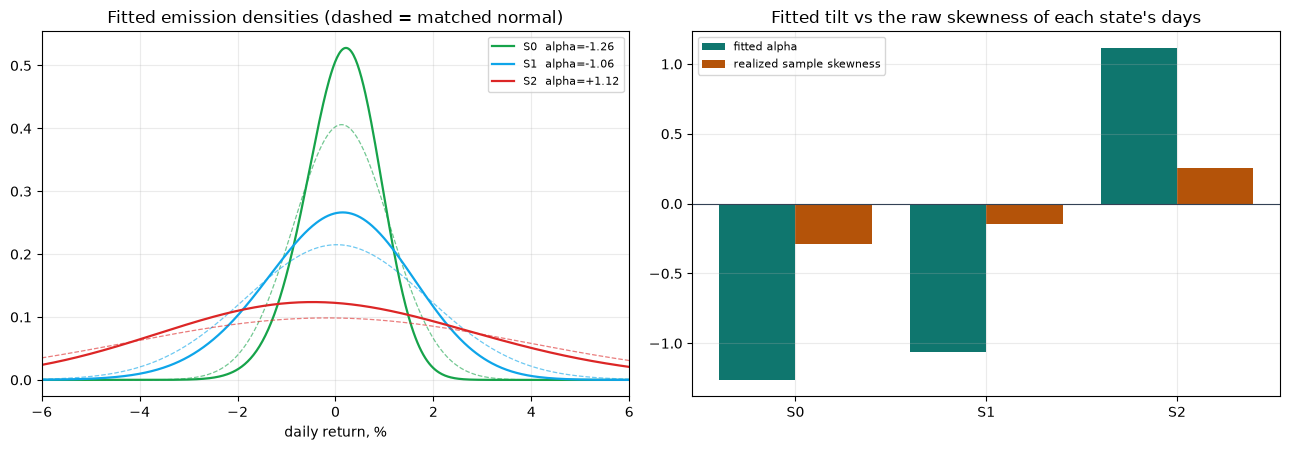

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

grid = np.linspace(-6, 6, 600)
for name, colour in zip(skew_table_qqq.index, ["#16a34a", "#0ea5e9", "#dc2626"]):
    values = dict(zip(qqq_skew.model.param_names, np.asarray(qqq_skew.params)))
    raw = list(skew_table_qqq.index).index(name)
    order = (pd.Series({i: np.sqrt(values[f"sigma2[{i}]"]) for i in range(N_STATES)})
             .sort_values().index.tolist())
    i = order[raw]
    location, scale, shape = values[f"const[{i}]"], np.sqrt(values[f"sigma2[{i}]"]), values[f"alpha[{i}]"]
    ax[0].plot(grid, stats.skewnorm.pdf(grid, shape, loc=location, scale=scale),
               color=colour, lw=1.6, label=f"{name}  alpha={shape:+.2f}")
    ax[0].plot(grid, stats.norm.pdf(grid, loc=location + scale * (shape / np.sqrt(1 + shape**2))
                                    * SQRT_2_OVER_PI, scale=scale),
               color=colour, lw=0.9, ls="--", alpha=0.6)
ax[0].set_xlim(-6, 6)
ax[0].set_title("Fitted emission densities (dashed = matched normal)")
ax[0].set_xlabel("daily return, %")
ax[0].legend(fontsize=8)

realized = pd.DataFrame({
    "state": skew_probabilities.idxmax(axis=1),
    "ret": qqq_returns,
}).dropna()
positions = np.arange(len(skew_table_qqq))
observed = [realized.loc[realized["state"] == n, "ret"].skew() for n in skew_table_qqq.index]
ax[1].bar(positions - 0.2, skew_table_qqq["alpha"], width=0.4, label="fitted alpha", color="#0f766e")
ax[1].bar(positions + 0.2, observed, width=0.4, label="realized sample skewness", color="#b45309")
ax[1].axhline(0, color="#334155", lw=0.8)
ax[1].set_xticks(positions, list(skew_table_qqq.index))
ax[1].set_title("Fitted tilt vs the raw skewness of each state's days")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [57]:
print("Does it replicate, and does it survive a fourth state?\n")

replication = {}
np.random.seed(RANDOM_SEED)
spy_gaussian_4 = MarkovRegression(returns, k_regimes=4, trend="c",
                                  switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                               maxiter=300, disp=False)
for label, series, k, gaussian in (
    ("QQQ, 4 states", qqq_returns, 4, None),
    (f"{PRIMARY}, 3 states", returns, N_STATES, fits[N_STATES]),
    (f"{PRIMARY}, 4 states", returns, 4, spy_gaussian_4),
):
    if gaussian is None:
        np.random.seed(RANDOM_SEED)
        gaussian = MarkovRegression(series, k_regimes=k, trend="c",
                                    switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                                 maxiter=300, disp=False)
    skewed, shapes = fit_skew(series, k, gaussian)
    table, _ = skew_table(skewed, k, series.index, True)
    statistic = 2 * (skewed.llf - gaussian.llf)
    replication[label] = {
        "llf_gain": skewed.llf - gaussian.llf,
        "LR_p_value": stats.chi2.sf(statistic, k),
        "BIC_gaussian": gaussian.bic,
        "BIC_skew": skewed.bic,
        "BIC_prefers": "skew" if skewed.bic < gaussian.bic else "Gaussian",
        "alphas_low_to_high_vol": np.round(table["alpha"].to_numpy(), 2).tolist(),
        "volatile_upward": list(volatile_upward(table)) or "none",
    }
print(pd.DataFrame(replication).T.to_string())

Does it replicate, and does it survive a fourth state?



                llf_gain LR_p_value  BIC_gaussian      BIC_skew BIC_prefers      alphas_low_to_high_vol volatile_upward
QQQ, 4 states   8.172694   0.002589  23296.023028  23315.026623    Gaussian  [1.37, -1.11, -0.68, 0.03]            none
SPY, 3 states   6.951596    0.00304    21018.0054  21030.884947    Gaussian        [-0.97, -0.93, 0.85]            none
SPY, 4 states  22.199977        0.0  20998.267406  20989.577769        skew   [-0.99, 5.04, -4.5, 0.87]            [S1]


### Verdict: a better description of the data, not a solution to the problem

Three findings, in decreasing order of how confident we should be in them.

**1. Returns within a regime are genuinely skewed.** The likelihood-ratio test rejects
$\alpha = 0$ in every configuration tried, on both indices, at both state counts. The Gaussian model
was mis-describing the data.

The *pattern* of the tilt is clean at three states and unusable at four. Both QQQ and SPY at $k=3$
give the same picture — calm and middle states negatively skewed, crash state positively skewed —
and that agrees with a fact Part 12 reached from trading results rather than from distribution
fitting. At $k=4$ the signs come out mixed and the magnitudes implausible, which is what one would
expect once the states themselves stop being stable (Part 19). Read the three-state result.

**2. It does not fix the problem it was built for.** The April-June 2026 rally is not relabelled. If
anything the skewed model is *more* confident that the whole window belongs to the middle state.
There is still no state that is simultaneously high-volatility and upward-drifting, in either index,
at either state count.

**3. Whether the extra parameters are worth paying for depends on the case.** BIC prefers the skewed
model for QQQ at three states and for SPY at four, and prefers the plain Gaussian for the other two.
That is a modest, honest result: the asymmetry is real, and it is small enough that the extra
parameters are not always justified by it.

The SPY four-state case deserves a warning rather than a victory lap. It wins on BIC by fitting two
*extreme* shapes — one above +5, one below −4, where anything beyond about ±4 is essentially a
half-normal — onto states that Part 19 showed are degenerate and last around a day. A flexible
density will happily contort itself around an outlier bucket, and BIC, which only counts parameters,
cannot tell that apart from a real finding. Read the three-state results; treat the four-state shapes
as an artifact of states that should not have been there.

### Why the idea failed, which is the useful part

The hypothesis was that a melt-up and a chop differ in *shape*. They do not — or at least, not in the
shape of their **daily** returns.

Skewness is a statement about tails: it says that when a large move happens, it is more likely to go
one way than the other. A crash regime has that property, which is why the model finds it there.
But a melt-up does not consist of a few enormous up-days. It consists of a long run of ordinary,
modestly positive days. Accumulate sixty of those and you get +27 %; look at any one of them in
isolation and it is unremarkable, and the *distribution* of those sixty days looks very much like the
distribution of sixty choppy days.

Which returns us to Part 19's arithmetic with a sharper point. Sustained drift is a property of the
**sequence**, not of the distribution the days are drawn from. A hidden Markov model with independent
emissions assumes that, given the state, each day is an independent draw — so any information living
in the ordering is invisible to it by construction. Adding parameters to the emission density cannot
recover it, no matter how flexible that density becomes. Skew-normal was the natural try; skew-$t$
would fail for exactly the same reason.

**What this implies for the model, concretely.** If you want the model to identify a sustained
directional run, the information has to enter somewhere other than the emission density: through the
transition matrix (which is what Part 9's VOL Regime Index does successfully — and note that it
works precisely because it is an *external* series, not another function of the same returns), or
through an explicitly constrained state whose mean is fixed rather than estimated. The emissions are
now a closed question.

**And the standing caveat.** All of this is in-sample. The skew-normal model has not been walked
forward, and nothing here has been tested for P&L. Part 12's warning applies with full force: a
better-fitting density has repeatedly failed to become money in this notebook, and there is no
reason yet to expect this one to be different.

## Part 21 — The gap: the VOL Regime Index was never applied to QQQ

### An omission worth fixing

Parts 9 and 11 established that letting the VOL Regime Index drive the *transition* probabilities is
the one modification to this model that clearly earns its keep. Parts 19 and 20 then spent a great
deal of effort on QQQ — diagnosing why its April-June 2026 rally is labelled Choppy, sweeping
horizons, adding states, rewriting the emission density.

Every one of those QQQ fits used **constant transition probabilities**. Part 10 fits the cross-asset
models with `fit_markov(data["ret"])` and no `exog_tvtp` argument, and Parts 19-20 build on those
fits. The index has only ever been applied to SPY.

That matters more than a normal loose end, because it is precisely the fix Part 20 concluded was the
only remaining route. The argument there was: an emission density cannot represent sustained drift,
because drift lives in the *sequence* rather than in the distribution each day is drawn from — so
directional information has to enter through the transition matrix instead. The index enters through
the transition matrix. It was never tried on the index where the problem was diagnosed.

So the honest thing is to run it. Two questions:

1. **Does the index replicate on QQQ?** Part 9's result was SPY-only, and cross-asset replication has
   been a standing check in this notebook.
2. **Does it change the labels** on the rally that started all of this?

In [58]:
qqq_frame = cross_asset_frames["QQQ"]
qqq_index = qqq_frame["vol_regime_index"]
qqq_standardized = ((qqq_index - qqq_index.mean()) / qqq_index.std()).to_numpy()
qqq_tvtp_exog = np.column_stack([np.ones(len(qqq_standardized)), qqq_standardized])

print(f"QQQ: {len(qqq_frame):,} observations, "
      f"{qqq_frame.index.min():%Y-%m-%d} .. {qqq_frame.index.max():%Y-%m-%d}")
print(f"VOL Regime Index present on {qqq_index.notna().mean():.0%} of them\n")

np.random.seed(RANDOM_SEED)
qqq_constant = fit_markov(qqq_frame["ret"])

# Seeded from the constant-transition solution, exactly as Part 9 does for SPY: random restarts
# on a TVTP likelihood land on degenerate optima (see tvtp_start_params' docstring).
qqq_tvtp_model = MarkovRegression(qqq_frame["ret"], k_regimes=N_STATES, trend="c",
                                  switching_variance=True, exog_tvtp=qqq_tvtp_exog)
qqq_index_driven = qqq_tvtp_model.fit(
    start_params=tvtp_start_params(qqq_tvtp_model, qqq_constant),
    search_reps=0, maxiter=500, disp=False)

statistic = 2 * (qqq_index_driven.llf - qqq_constant.llf)
print(f"log-likelihood  {qqq_constant.llf:.1f} -> {qqq_index_driven.llf:.1f}"
      f"   (+{qqq_index_driven.llf - qqq_constant.llf:.1f})")
print(f"BIC             {qqq_constant.bic:.1f} -> {qqq_index_driven.bic:.1f}"
      f"   ({'the index wins' if qqq_index_driven.bic < qqq_constant.bic else 'constant wins'})")
print(f"likelihood ratio chi2(6) = {statistic:.1f}, p = {stats.chi2.sf(statistic, 6):.2e}")

constant_labels = label_states(qqq_constant)
index_labels = label_states(qqq_index_driven)
constant_probabilities = labelled_probabilities(qqq_constant, constant_labels, qqq_frame.index)
index_probabilities = labelled_probabilities(qqq_index_driven, index_labels, qqq_frame.index)

for name, res, lbl in (("constant transitions", qqq_constant, constant_labels),
                       ("index-driven transitions", qqq_index_driven, index_labels)):
    params = state_params(res)
    summary = pd.DataFrame({
        "annual_return_%": [params.loc[lbl[n], "mu"] * TRADING_DAYS for n in LABEL_ORDER],
        "annual_vol_%": [params.loc[lbl[n], "sd"] * np.sqrt(TRADING_DAYS) for n in LABEL_ORDER],
        "duration_days": [params.loc[lbl[n], "duration_days"] for n in LABEL_ORDER],
    }, index=LABEL_ORDER)
    print(f"\n{name}:")
    print(summary.round(2).to_string())

QQQ: 6,886 observations, 1999-03-11 .. 2026-07-28
VOL Regime Index present on 100% of them



/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


log-likelihood  -11670.1 -> -11601.1   (+69.0)
BIC             23446.2 -> 23361.3   (the index wins)
likelihood ratio chi2(6) = 137.9, p = 2.76e-27

constant transitions:
        annual_return_%  annual_vol_%  duration_days
Bull              37.77         11.83          39.85
Choppy             0.77         23.90          31.41
Bear             -45.29         51.55          82.64

index-driven transitions:
        annual_return_%  annual_vol_%  duration_days
Bull              43.72         10.67         797.53
Choppy             0.82         22.45          18.01
Bear             -42.18         49.10         198.32


### It replicates cleanly — the index earns its place on QQQ too

The likelihood ratio is overwhelming and BIC improves by a wide margin even after paying for six
extra parameters. This is the same result Part 9 found on SPY, on an index fitted independently, so
the finding that the VOL Regime Index carries real information about *regime persistence* is now
cross-asset rather than SPY-specific.

Look at what it does to the state table: Bull's expected duration lengthens dramatically. That is the
signature Part 9 identified — the index does not change what the regimes *are*, it changes how long
they last, and it does so conditionally.

In [59]:
calm_quartile = qqq_standardized <= np.quantile(qqq_standardized, 0.25)
stressed_quartile = qqq_standardized >= np.quantile(qqq_standardized, 0.75)

print("QQQ transition matrix when the index is CALM (bottom quartile):")
print(transition_matrix(qqq_index_driven, index_labels, calm_quartile).round(3).to_string())
print("\n...and when it is STRESSED (top quartile):")
print(transition_matrix(qqq_index_driven, index_labels, stressed_quartile).round(3).to_string())

QQQ transition matrix when the index is CALM (bottom quartile):
             to Bull  to Choppy  to Bear
from Bull      0.999      0.001    0.000
from Choppy    0.029      0.971    0.000
from Bear      0.000      0.002    0.998

...and when it is STRESSED (top quartile):
             to Bull  to Choppy  to Bear
from Bull      0.215      0.742    0.042
from Choppy    0.170      0.787    0.043
from Bear      0.000      0.025    0.975


In [60]:
print("The question this was run to answer — does it relabel the rallies?\n")
for start, end in REBOUND_WINDOWS["QQQ"]:
    constant_counts = constant_probabilities.idxmax(axis=1).loc[start:end].value_counts().to_dict()
    index_counts = index_probabilities.idxmax(axis=1).loc[start:end].value_counts().to_dict()
    realized = qqq_frame["ret"].loc[start:end].sum()
    print(f"  {start} .. {end}   ({np.exp(realized / RETURN_SCALE) - 1:+.1%})")
    print(f"      constant     {constant_counts}")
    print(f"      index-driven {index_counts}")

agreement = (constant_probabilities.idxmax(axis=1)
             == index_probabilities.idxmax(axis=1)).mean()
print(f"\nOverall label agreement between the two QQQ fits: {agreement:.1%}")
for name, probabilities in (("constant", constant_probabilities),
                            ("index-driven", index_probabilities)):
    shares = probabilities.idxmax(axis=1).value_counts(normalize=True).reindex(LABEL_ORDER)
    print(f"  {name:<13} share of days: "
          f"{ {n: f'{shares[n]:.1%}' for n in LABEL_ORDER} }")

The question this was run to answer — does it relabel the rallies?

  2026-04-01 .. 2026-06-30   (+27.6%)
      constant     {'Choppy': 54, 'Bull': 8}
      index-driven {'Choppy': 46, 'Bull': 12, 'Bear': 4}
  2020-04-23 .. 2020-09-02   (+43.5%)
      constant     {'Choppy': 93}
      index-driven {'Choppy': 82, 'Bull': 6, 'Bear': 5}
  2009-04-03 .. 2009-08-20   (+25.2%)
      constant     {'Choppy': 97}
      index-driven {'Choppy': 93, 'Bear': 4}
  2003-03-12 .. 2003-08-20   (+35.7%)
      constant     {'Choppy': 113}
      index-driven {'Choppy': 106, 'Bear': 7}

Overall label agreement between the two QQQ fits: 87.1%
  constant      share of days: {'Bull': '43.8%', 'Choppy': '40.2%', 'Bear': '16.0%'}
  index-driven  share of days: {'Bull': '37.1%', 'Choppy': '43.7%', 'Bear': '19.2%'}


### But it does not fix the labelling, and it makes the rebounds worse

The April-June 2026 window barely moves. Four days shift from Choppy to Bull — and four others shift
from Choppy to **Bear**. The overwhelming majority of the rally is still called Choppy, and the net
directional improvement is zero.

The other three rebound windows move in the **wrong direction**. Under constant transitions they were
uniformly Choppy. Under index-driven transitions every one of them picks up *Bear* days: the model
becomes more willing to call the 2003, 2009 and 2020 recoveries bearish than it was before. Across
the whole sample the share of days labelled Bull *falls* from 43.8 % to 37.1 %, while Bear rises from
16.0 % to 19.2 %.

A note on the fit itself: the optimizer reports that it hit its iteration limit without formally
converging. The improvement is far too large to be an artifact of that, and the conditional
transition matrices below are well-behaved rather than degenerate, but the parameter values should be
read as approximate.

Once stated, the reason is obvious, and it is the point of this section:

> **The VOL Regime Index is a volatility signal.** Feeding it into the transition matrix makes the
> model *more* volatility-driven, not more direction-aware.

Those rallies happened while VIX was still elevated — that is what a recovery from a crash looks
like. The index reads that as stress, stress raises the probability of the high-volatility state, and
the high-volatility state is Bear. So the index actively pushes a violent rally *towards* the bearish
label. It improves the fit because it genuinely predicts how long regimes last; it cannot help with
direction because it contains no directional information to give.

### This sharpens Part 20's conclusion

Part 20 ended by saying that direction has to enter through the transition matrix rather than the
emission density, and pointed at the VOL Regime Index as the working example. That was the right
mechanism but the wrong emphasis, and this section corrects it:

| What I said in Part 20 | What this section shows |
|---|---|
| Direction must enter via the transitions, not the emissions | **Still true** — the emissions argument is unaffected |
| The index works because it is an *external* series | **Too weak.** Being external is not sufficient |
| — | What matters is that the driver be **directional**. The index is external *and* useless for this, because it measures volatility |

So the requirement is sharper than "bring in outside data". A transition driver can only supply
direction if it is itself directional: market breadth, credit spreads, earnings revisions, a trend
measure. Adding a better volatility signal — however well it fits — will keep producing what we see
here, which is a more accurate description of *when regimes change* alongside no improvement at all
in *which way they point*. Worse than no improvement, in fact: because high volatility maps onto the
bearish state, a volatility driver actively biases violent rallies towards Bear.

**What this does not undermine.** Everything Parts 19 and 20 concluded stands, because none of it
depended on the transition specification: the ~200:1 evidence ratio is a property of the emission
density, the horizon sweep tested aggregation, and the skew-normal result tested distributional
shape. The gap was real and worth closing, and closing it removed a candidate explanation rather than
changing an answer.

**And the standing caveat.** In-sample again. Part 11 walked the SPY version forward and found the
index's advantage survives out of sample as a *density* improvement that never became P&L; there is
no reason to expect the QQQ version to behave differently, and it has not been tested.

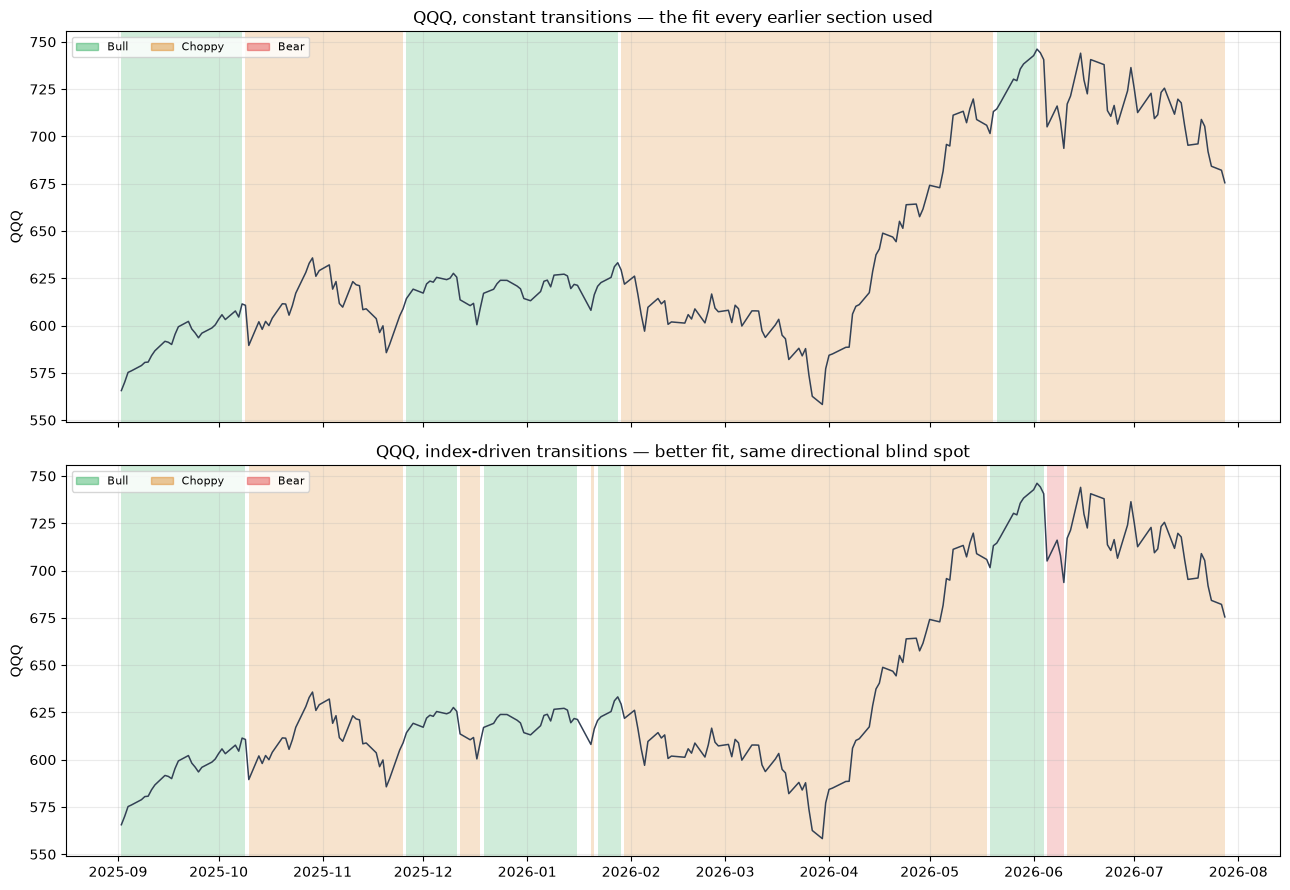

In [61]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

zoom = qqq_frame.loc["2025-09-01":]
for axis, (labels, title) in zip(ax, [
    (constant_probabilities.idxmax(axis=1).reindex(zoom.index),
     "QQQ, constant transitions — the fit every earlier section used"),
    (index_probabilities.idxmax(axis=1).reindex(zoom.index),
     "QQQ, index-driven transitions — better fit, same directional blind spot"),
]):
    axis.plot(zoom.index, zoom["close"], color="#334155", lw=1.1)
    low, high = axis.get_ylim()
    for name in LABEL_ORDER:
        axis.fill_between(zoom.index, low, high, where=(labels == name).to_numpy(),
                          color=LABEL_COLORS[name], alpha=0.20, lw=0)
    axis.set_ylim(low, high)
    axis.set_title(title)
    axis.set_ylabel("QQQ")
    handles = [plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS[n], alpha=0.4) for n in LABEL_ORDER]
    axis.legend(handles, LABEL_ORDER, loc="upper left", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

## Part 22 — Corporate bond yields: hunting a *directional* driver

Part 21 ended with a specific requirement. Direction cannot come from the emission density (Part 20)
and cannot come from a volatility signal routed through the transition matrix (Part 21), because a
volatility signal pushes violent rallies towards the bearish state. What is needed is a transition
driver that is *itself* directional.

Credit is the canonical candidate. This section brings in two series from FRED:

- **DBAA** — Moody's Seasoned **Baa** Corporate Bond Yield (medium investment grade)
- **DAAA** — Moody's Seasoned **Aaa** Corporate Bond Yield (highest grade)

and the difference between them, **Baa − Aaa**. That difference is worth a moment. Both are
long-maturity corporate yields, so the general level of interest rates affects them almost equally.
Subtracting one from the other cancels most of that shared level and leaves something closer to a
pure **credit risk premium** — the extra yield investors demand for taking default risk. When
lenders get nervous, the spread widens; when they get comfortable, it narrows.

That distinction turns out to be the most important thing in this section.

### Three practical problems to solve first

1. **The series are not on our trading calendar.** FRED skips market holidays and occasionally misses
   a print, so the data has to be interpolated onto the days QQQ actually trades.
2. **FRED publishes with a one-day delay.** Today's yield does not exist yet. Any signal built from
   it is therefore unusable in real time unless we can *nowcast* the missing value — and this is
   exactly the kind of quiet look-ahead that flatters a backtest.
3. **The raw level is the wrong variable.** Yields drifted from roughly 8 % to 6 % over this sample
   while QQQ rose enormously, so any correlation with the level is contaminated by two shared trends.
   We need transformations that isolate *changes* and *local* position: differences at several
   horizons, rolling z-scores, and the True Strength Index the VOL Regime Index already uses.

In [62]:
CREDIT_SERIES = {"baa": "DBAA", "aaa": "DAAA"}
Z_WINDOW = 504          # 2 trading years, matching the VOL Regime Index's window
INTERPOLATION_LIMIT = 5  # consecutive missing days we are willing to bridge

credit_raw = {name: client.series("fred", code, start="1990-01-01")
              for name, code in CREDIT_SERIES.items()}
lqd_close = client.prices("LQD", start="1990-01-01")["Close"]
hyg_close = client.prices("HYG", start="1990-01-01")["Close"]

qqq_calendar = cross_asset_frames["QQQ"].index

# Measure the lag against a LIVE series. `cross_asset_frames` is joined to VIX, which itself
# publishes with a lag, so its last row is not today — using it here would hide the very problem
# this section is about. LQD is an ETF: its last close is the last completed session.
live_session = lqd_close.index.max()
print("Publication lag, the reason a nowcast is needed:")
print(f"  last live market session (LQD close) : {live_session:%Y-%m-%d}")
for name, series in credit_raw.items():
    behind = len(pd.bdate_range(series.index.max(), live_session)) - 1
    print(f"  {CREDIT_SERIES[name]} last observation             : {series.index.max():%Y-%m-%d}"
          f"   ({behind} business day(s) behind)")
print(f"  (the model's own QQQ frame ends {qqq_calendar.max():%Y-%m-%d}, since it is joined to VIX)")

credit = pd.DataFrame(index=qqq_calendar)
credit["qqq"] = cross_asset_frames["QQQ"]["close"]
credit["ret"] = cross_asset_frames["QQQ"]["ret"]
credit["lqd_ret"] = RETURN_SCALE * np.log(lqd_close.reindex(qqq_calendar)).diff()
credit["hyg_ret"] = RETURN_SCALE * np.log(hyg_close.reindex(qqq_calendar)).diff()
credit["credit_ret"] = credit["hyg_ret"] - credit["lqd_ret"]   # high yield minus investment grade

print("\nAligning FRED onto the QQQ trading calendar:")
for name, series in credit_raw.items():
    on_grid = series.reindex(qqq_calendar)
    credit[name] = on_grid.interpolate(limit_area="inside", limit=INTERPOLATION_LIMIT)
    print(f"  {name}: {on_grid.isna().sum()} missing on the grid, "
          f"{credit[name].isna().sum()} still missing after interpolation")

credit["spread"] = credit["baa"] - credit["aaa"]
credit = credit.dropna(subset=["baa", "aaa", "ret"])
print(f"\n{len(credit):,} usable rows, {credit.index.min():%Y-%m-%d} .. {credit.index.max():%Y-%m-%d}")
print(credit[["baa", "aaa", "spread"]].describe().T.round(2).to_string())

Publication lag, the reason a nowcast is needed:
  last live market session (LQD close) : 2026-07-29
  DBAA last observation             : 2026-07-28   (1 business day(s) behind)
  DAAA last observation             : 2026-07-28   (1 business day(s) behind)
  (the model's own QQQ frame ends 2026-07-28, since it is joined to VIX)

Aligning FRED onto the QQQ trading calendar:
  baa: 47 missing on the grid, 0 still missing after interpolation
  aaa: 47 missing on the grid, 0 still missing after interpolation

6,886 usable rows, 1999-03-11 .. 2026-07-28
         count  mean   std   min   25%   50%   75%   max
baa     6886.0  5.86  1.36  3.11  4.83  5.88  6.63  9.54
aaa     6886.0  4.87  1.29  2.01  3.90  5.03  5.56  8.12
spread  6886.0  0.99  0.40  0.40  0.75  0.90  1.11  3.50


### Problem 2: nowcasting the value that has not been published

We need today's yield today. Four approaches, and the comparison between them teaches something
general:

- **Persistence** — just use yesterday's value. This is the baseline every method must beat, and it
  is a much stronger baseline than it looks.
- **AR(5)** — regress today's *change* on the last five daily changes. This asks whether yield moves
  have momentum or reversal that can be extrapolated.
- **TEMA** — the Triple Exponential Moving Average, $3E_1 - 3E_2 + E_3$ where each $E$ is an EMA of
  the previous one. The triple construction cancels most of the lag an ordinary EMA introduces, so
  it tracks turns much faster. We compute it through yesterday and extrapolate one step along its
  own slope.
- **A live proxy** — **LQD**, the investment-grade corporate bond ETF. This is the interesting one,
  because LQD trades continuously and *today's* close is available now. Bond prices move inversely to
  yields, so today's LQD return should reveal today's yield change before FRED publishes it.

Every coefficient below is estimated on data strictly earlier than the year being predicted, refit
annually — so the evaluation is honestly out-of-sample.

In [63]:
AR_LAGS, REFIT_EVERY, MIN_TRAIN = 5, 252, 756


def tema(series: pd.Series, span: int) -> pd.Series:
    """Triple exponential moving average: 3*E1 - 3*E2 + E3. Far less lag than a single EMA."""
    first = series.ewm(span=span, adjust=False).mean()
    second = first.ewm(span=span, adjust=False).mean()
    third = second.ewm(span=span, adjust=False).mean()
    return 3 * first - 3 * second + third


def nowcast(target: str, proxy: str) -> pd.DataFrame:
    """Predict today's yield from yields through yesterday plus today's live proxy return."""
    level = credit[target].dropna()
    change = level.diff()
    out = pd.DataFrame(index=level.index, dtype=float,
                       columns=["actual", "persistence", "ar", "tema10", "lqd_proxy", "ar_plus_proxy"])
    out["actual"] = level
    out["persistence"] = level.shift(1)
    smoothed = tema(level, 10).shift(1)
    out["tema10"] = smoothed + (smoothed - smoothed.shift(1))

    lagged = pd.concat({f"lag{i}": change.shift(i) for i in range(1, AR_LAGS + 1)}, axis=1)
    live = credit[proxy].reindex(level.index)

    def regress(design, response):
        ok = design.notna().all(axis=1) & response.notna()
        if ok.sum() < 50:
            return None, None
        matrix = np.column_stack([np.ones(ok.sum()), design[ok].to_numpy()])
        return np.linalg.lstsq(matrix, response[ok].to_numpy(), rcond=None)[0], ok

    for start in range(MIN_TRAIN, len(level), REFIT_EVERY):
        train_idx = level.index[:start]
        test_idx = level.index[start:start + REFIT_EVERY]
        yesterday = level.shift(1).loc[test_idx]
        for column, design in (("ar", lagged),
                               ("lqd_proxy", live.to_frame("now")),
                               ("ar_plus_proxy", lagged.join(live.rename("now")))):
            coef, _ = regress(design.loc[train_idx], change.loc[train_idx])
            if coef is None:
                continue
            test_design = design.loc[test_idx]
            valid = test_design.notna().all(axis=1)
            out.loc[test_idx[valid], column] = (
                yesterday[valid] + coef[0] + test_design[valid].to_numpy() @ coef[1:])
    return out


def nowcast_scores(out: pd.DataFrame) -> pd.DataFrame:
    realized_change = out["actual"].diff()
    rows = {}
    for method in ("persistence", "ar", "tema10", "lqd_proxy", "ar_plus_proxy"):
        ok = out[method].notna() & out["actual"].notna()
        if ok.sum() < 100:
            continue
        error = (out[method] - out["actual"])[ok]
        predicted_change = (out[method] - out["actual"].shift(1))[ok]
        actual_change = realized_change[ok]
        moved = actual_change.abs() > 1e-9
        rows[method] = {
            "days": int(ok.sum()),
            "RMSE_bp": np.sqrt((error ** 2).mean()) * 100,
            "MAE_bp": error.abs().mean() * 100,
            "direction_correct_%": (np.sign(predicted_change[moved])
                                    == np.sign(actual_change[moved])).mean() * 100,
            "corr_of_changes": predicted_change.corr(actual_change),
        }
    scores = pd.DataFrame(rows).T
    scores["RMSE_vs_persistence"] = scores["RMSE_bp"] / scores.loc["persistence", "RMSE_bp"]
    return scores


print("How well does today's LQD return reveal today's unpublished yield change?")
for target in ("baa", "aaa", "spread"):
    row = "  " + f"{target:<7}"
    for proxy in ("lqd_ret", "credit_ret"):
        row += f"  vs {proxy}: {credit[target].diff().corr(credit[proxy]):+.3f}"
    print(row)

nowcast_results = {}
for target, proxy in (("baa", "lqd_ret"), ("aaa", "lqd_ret"), ("spread", "credit_ret")):
    result = nowcast(target, proxy)
    nowcast_results[target] = result
    scores = nowcast_scores(result)
    print(f"\n--- nowcasting {target.upper()} (live proxy: {proxy})")
    print(scores.round(3).to_string())

How well does today's LQD return reveal today's unpublished yield change?
  baa      vs lqd_ret: -0.603  vs credit_ret: +0.467
  aaa      vs lqd_ret: -0.573  vs credit_ret: +0.481
  spread   vs lqd_ret: -0.004  vs credit_ret: -0.094

--- nowcasting BAA (live proxy: lqd_ret)
                 days  RMSE_bp  MAE_bp  direction_correct_%  corr_of_changes  RMSE_vs_persistence
persistence    6885.0    5.225   3.899                0.000              NaN                1.000
ar             6130.0    5.292   3.939               50.491           -0.017                1.013
tema10         6884.0    5.690   4.260               49.698            0.026                1.089
lqd_proxy      5878.0    4.617   2.867               82.384            0.520                0.884
ar_plus_proxy  5878.0    4.633   2.879               81.583            0.518                0.887

--- nowcasting AAA (live proxy: lqd_ret)
                 days  RMSE_bp  MAE_bp  direction_correct_%  corr_of_changes  RMSE_vs_persisten


--- nowcasting SPREAD (live proxy: credit_ret)
                 days  RMSE_bp  MAE_bp  direction_correct_%  corr_of_changes  RMSE_vs_persistence
persistence    6885.0    2.273   1.285                0.000              NaN                1.000
ar             6130.0    2.262   1.357               54.729            0.146                0.995
tema10         6884.0    2.376   1.444               55.613            0.149                1.045
lqd_proxy      4618.0    2.476   1.474               50.996            0.043                1.089
ar_plus_proxy  4618.0    2.472   1.490               55.284            0.127                1.087


/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/mak/Documents/GitHub/tyche-client/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mak/Documents/GitHub/tyche-client/.venv/lib

### The nowcast result, and the general lesson in it

**For the two yield levels, LQD solves the problem.** It cuts the error against persistence by about
a tenth on RMSE and a quarter on mean absolute error, and — the number that matters for a signal —
it gets the *direction* of the unpublished day's move right roughly **four times in five**. The
one-day publication lag is no longer a reason to avoid these series.

**AR and TEMA both lose to persistence.** That is not a tuning failure, it is informative. The
correlation between predicted and actual daily changes under AR is essentially zero: daily moves in a
long-maturity corporate yield are close to a random walk, and *the past of a random walk contains no
information about its next step*. TEMA does worse still, because extrapolating a smoothed line along
its own slope assumes trends persist — so it is confidently wrong at every turn, and adds variance
for nothing.

The general principle is worth stating because it generalises past this notebook: **when a series is
near-unpredictable from its own history, the only way to nowcast it is a different series that
correlates with it and publishes sooner.** LQD works not because it is cleverer but because it is
*faster*.

**For the spread, nothing beats persistence.** The high-yield-minus-investment-grade proxy barely
sees it, and actively hurts. But this turns out not to matter much: the spread's daily change has an
RMSE of about 2 basis points against a series whose standard deviation is 40 basis points, so
yesterday's spread is a perfectly serviceable estimate of today's. The signal moves slowly enough
that a one-day lag is immaterial.

In [64]:
FORWARD_HORIZONS = (1, 5, 21, 63)


def credit_transforms(series: pd.Series, label: str) -> dict:
    """Level, changes at several horizons, rolling z-score, and TSI at two speeds."""
    out = {f"{label}_level": series}
    for horizon in FORWARD_HORIZONS:
        out[f"{label}_chg{horizon}"] = series.diff(horizon)
    rolling = series.rolling(Z_WINDOW)
    out[f"{label}_z"] = (series - rolling.mean()) / rolling.std()
    for long, short in ((40, 20), (25, 13)):
        out[f"{label}_tsi{long}_{short}"] = pd.Series(tsi(series.to_numpy(), long, short),
                                                     index=series.index)
    return out


credit_features = {}
for label in ("baa", "aaa", "spread"):
    credit_features.update(credit_transforms(credit[label], label))
credit_features = pd.DataFrame(credit_features, index=credit.index)

print("Contemporaneous co-movement versus genuine prediction.")
print("Left: yield change and QQQ return over the SAME window. Right: signal now, QQQ next window.\n")
comparison = {}
for horizon in FORWARD_HORIZONS:
    same_window = credit["ret"].rolling(horizon).sum()
    next_window = (credit["ret"][::-1].rolling(horizon).sum()[::-1]).shift(-1)
    for label in ("baa", "aaa", "spread"):
        change = credit[label].diff(horizon)
        comparison[(label, f"{horizon}d")] = {
            "contemporaneous": change.corr(same_window),
            "predictive": change.corr(next_window),
        }
print(pd.DataFrame(comparison).T.round(3).to_string())

forward_21 = (credit["ret"][::-1].rolling(21).sum()[::-1]).shift(-1)
print("\nBest predictive correlations at 21 days, across every transform:")
with np.errstate(invalid="ignore", divide="ignore"):
    predictive = credit_features.apply(lambda col: col.corr(forward_21))
predictive = predictive.sort_values(key=abs, ascending=False)
print(predictive.head(6).round(3).to_string())
print("\nAnd the level correlations, before and after removing the shared secular trend:")
for label in ("baa", "aaa", "spread"):
    level = credit[label]
    detrended = level - level.rolling(Z_WINDOW).mean()
    print(f"  {label:<7} raw {level.corr(forward_21):+.3f}   detrended {detrended.corr(forward_21):+.3f}")

Contemporaneous co-movement versus genuine prediction.
Left: yield change and QQQ return over the SAME window. Right: signal now, QQQ next window.

            contemporaneous  predictive
baa    1d             0.120      -0.019
aaa    1d             0.117      -0.020
spread 1d            -0.006       0.004
baa    5d            -0.028      -0.056
aaa    5d             0.024      -0.049
spread 5d            -0.119      -0.016
baa    21d           -0.235      -0.012
aaa    21d           -0.087       0.005
spread 21d           -0.306      -0.031
baa    63d           -0.270      -0.093
aaa    63d           -0.012      -0.051
spread 63d           -0.433      -0.083

Best predictive correlations at 21 days, across every transform:
aaa_level      -0.119
baa_level      -0.110
baa_z          -0.096
aaa_z          -0.066
spread_chg63   -0.066
spread_z       -0.065

And the level correlations, before and after removing the shared secular trend:
  baa     raw -0.110   detrended -0.075
  aaa     raw

In [65]:
SUB_PERIODS_CREDIT = [("1999-2004", "1999", "2004"), ("2005-2009", "2005", "2009"),
                      ("2010-2014", "2010", "2014"), ("2015-2019", "2015", "2019"),
                      ("2020-2021", "2020", "2021"), ("2022-2026", "2022", "2026")]

print("The stability question. Contemporaneous 5-day correlation with QQQ, era by era:\n")
five_day = credit["ret"].rolling(5).sum()
stability = {}
for name, first, last in SUB_PERIODS_CREDIT:
    window = slice(first, last)
    stability[name] = {label: credit[label].diff(5).loc[window].corr(five_day.loc[window])
                       for label in ("baa", "aaa", "spread")}
    stability[name]["days"] = len(credit.loc[window])
print(pd.DataFrame(stability).T.round(3).to_string())

print("\nQQQ's annualized return when each series is rising versus falling (5-day changes):")
for label in ("baa", "aaa", "spread"):
    change = credit[label].diff(5)
    rising = five_day[change > 0].mean() * (TRADING_DAYS / 5)
    falling = five_day[change < 0].mean() * (TRADING_DAYS / 5)
    print(f"  {label:<7} rising {rising:+7.1f}%/yr   falling {falling:+7.1f}%/yr"
          f"   advantage to falling {falling - rising:+7.1f} points")

print("\nSame, restricted to 2022 onward:")
for label in ("baa", "aaa", "spread"):
    change = credit[label].diff(5).loc["2022":]
    recent = five_day.loc["2022":]
    rising = recent[change > 0].mean() * (TRADING_DAYS / 5)
    falling = recent[change < 0].mean() * (TRADING_DAYS / 5)
    print(f"  {label:<7} rising {rising:+7.1f}%/yr   falling {falling:+7.1f}%/yr"
          f"   advantage to falling {falling - rising:+7.1f} points")

The stability question. Contemporaneous 5-day correlation with QQQ, era by era:

             baa    aaa  spread    days
1999-2004  0.038  0.085  -0.112  1461.0
2005-2009  0.027  0.169  -0.243  1259.0
2010-2014  0.419  0.463  -0.108  1258.0
2015-2019  0.086  0.094  -0.028  1258.0
2020-2021 -0.407 -0.348  -0.080   505.0
2022-2026 -0.377 -0.367  -0.065  1145.0

QQQ's annualized return when each series is rising versus falling (5-day changes):
  baa     rising   +14.2%/yr   falling    +4.5%/yr   advantage to falling    -9.7 points
  aaa     rising   +20.6%/yr   falling    -1.7%/yr   advantage to falling   -22.3 points
  spread  rising    -9.3%/yr   falling   +27.7%/yr   advantage to falling   +37.1 points

Same, restricted to 2022 onward:
  baa     rising   -33.1%/yr   falling   +63.1%/yr   advantage to falling   +96.3 points
  aaa     rising   -31.9%/yr   falling   +65.0%/yr   advantage to falling   +97.0 points
  spread  rising    +5.0%/yr   falling   +19.3%/yr   advantage to falling   

### The hypothesis is right, wrong, and right again depending on which variable and which decade

Three things come out of those two cells, and they need separating carefully.

**First: this is co-movement, not prediction.** The contemporaneous correlations are substantial — the
spread against QQQ over 63-day windows is around −0.43 — while the predictive correlations are an
order of magnitude smaller and hover near zero. Credit and equities move together; credit does not
lead equities. The level correlations that look larger mostly evaporate once the shared secular
trend is removed, which is what the detrended column shows.

**Second, and this is the important caution: the sign of the raw yield relationship is not stable.**
Look along the era rows. In 2010-2014 the correlation between rising Baa yields and QQQ returns is
strongly **positive** — rising yields went with a *rising* market. In 2020-2021 and 2022-2026 it is
strongly **negative**. Both are economically sensible and they are opposites: in a
disinflationary decade, rising yields signal improving growth and equities like them; in an
inflationary one, rising yields are a discount-rate shock and long-duration technology hates them.

So the intuition that QQQ is weak when corporate yields rise is **correct for the recent era and
backwards for the 2010s.** Over the whole sample the effect nets out to roughly nothing — which is
why the full-period "rising versus falling" table shows QQQ doing *better* when Baa yields rise,
while the post-2022 subsample shows a large advantage to falling yields. Anyone building on the raw
yield is really building on the last few years.

**Third: the spread does not have this problem.** Its correlation with QQQ is negative in *every one*
of the six eras. That is the payoff from subtracting Aaa from Baa: stripping out the level of rates
leaves credit risk, and credit stress is bad for equities in every monetary regime, whereas the level
of rates is sometimes good news and sometimes bad. If any part of this data is going to work as a
stable driver, it is the spread.

In [66]:
CREDIT_DRIVERS = {
    "constant (no driver)": None,
    "VOL Regime Index": ["vol_regime_index"],
    "credit spread z-score": ["spread_z"],
    "VOL Regime Index + spread": ["vol_regime_index", "spread_z"],
}

driver_frame = credit.copy()
driver_frame["vol_regime_index"] = cross_asset_frames["QQQ"]["vol_regime_index"]
driver_frame["spread_z"] = credit_features["spread_z"]
driver_frame = driver_frame.dropna(subset=["vol_regime_index", "spread_z", "ret"])
driver_returns = driver_frame["ret"]
print(f"common sample for the driver comparison: {len(driver_frame):,} rows, "
      f"{driver_frame.index.min():%Y-%m-%d} .. {driver_frame.index.max():%Y-%m-%d}\n")


def multi_tvtp_start(model, base_res, n_drivers: int) -> np.ndarray:
    """Generalization of tvtp_start_params to more than one driver.

    Each transition row gets an intercept plus one slope per driver. Setting every slope to zero
    and each intercept to the base model's log-odds reproduces the constant-transition model, so
    the fit starts at the nested solution rather than somewhere arbitrary.
    """
    k = base_res.model.k_regimes
    start = np.zeros(model.k_params)
    transitions = base_res.regime_transition[:, :, 0]     # [to, from]
    cursor = 0
    for source in range(k):
        for destination in range(k - 1):
            start[cursor] = np.log(max(transitions[destination, source], 1e-8)
                                   / max(transitions[k - 1, source], 1e-8))
            start[cursor + 1: cursor + 1 + n_drivers] = 0.0
            cursor += 1 + n_drivers
    start[cursor:] = np.asarray(base_res.params)[base_res.model.parameters['exog'].start:]
    return start


np.random.seed(RANDOM_SEED)
credit_base = MarkovRegression(driver_returns, k_regimes=N_STATES, trend="c",
                              switching_variance=True).fit(search_reps=HORIZON_REPS,
                                                           maxiter=300, disp=False)

driver_rows, driver_probabilities, driver_fits = {}, {}, {}
for name, columns in CREDIT_DRIVERS.items():
    if columns is None:
        res = credit_base
    else:
        standardized = [((driver_frame[c] - driver_frame[c].mean()) / driver_frame[c].std()).to_numpy()
                        for c in columns]
        exog = np.column_stack([np.ones(len(driver_frame))] + standardized)
        model = MarkovRegression(driver_returns, k_regimes=N_STATES, trend="c",
                                 switching_variance=True, exog_tvtp=exog)
        np.random.seed(RANDOM_SEED)
        res = model.fit(start_params=multi_tvtp_start(model, credit_base, len(columns)),
                        search_reps=0, maxiter=600, disp=False)
    driver_fits[name] = res
    labels_map = label_states(res)
    probabilities = labelled_probabilities(res, labels_map, driver_frame.index)
    driver_probabilities[name] = probabilities
    assigned = probabilities.idxmax(axis=1)
    driver_rows[name] = {
        "parameters": len(np.asarray(res.params)),
        "log_likelihood": res.llf,
        "BIC": res.bic,
        "Bull_share": f"{(assigned == BULL).mean():.1%}",
        **{f"Bull%_{start[:7]}": f"{(assigned.loc[start:end] == BULL).mean():.0%}"
           for start, end in REBOUND_WINDOWS["QQQ"]},
    }
driver_table = pd.DataFrame(driver_rows).T
driver_table["BIC_vs_constant"] = driver_table["BIC"] - driver_table.loc["constant (no driver)", "BIC"]
print(driver_table.to_string())

vol_only, with_spread = driver_fits["VOL Regime Index"], driver_fits["VOL Regime Index + spread"]
extra = len(np.asarray(with_spread.params)) - len(np.asarray(vol_only.params))
statistic = 2 * (with_spread.llf - vol_only.llf)
print(f"\nIncremental test — the spread ON TOP OF the volatility index:")
print(f"  log-likelihood {vol_only.llf:.1f} -> {with_spread.llf:.1f} "
      f"(+{with_spread.llf - vol_only.llf:.1f} for {extra} parameters)")
print(f"  likelihood ratio chi2({extra}) = {statistic:.1f}, p = {stats.chi2.sf(statistic, extra):.2e}")
print(f"  BIC {vol_only.bic:.1f} -> {with_spread.bic:.1f}  "
      f"({'the spread earns its keep' if with_spread.bic < vol_only.bic else 'the spread does NOT pay for its parameters'})")

common sample for the driver comparison: 6,383 rows, 2001-03-09 .. 2026-07-28



                          parameters log_likelihood           BIC Bull_share Bull%_2026-04 Bull%_2020-04 Bull%_2009-04 Bull%_2003-03 BIC_vs_constant
constant (no driver)              12  -10392.365244   20889.86721      39.5%            0%            0%            0%            0%             0.0
VOL Regime Index                  18  -10308.803787  20775.312657      37.7%           18%            2%            0%            0%     -114.554553
credit spread z-score             18  -10381.101683  20919.908448      42.7%            6%            0%            0%            0%       30.041238
VOL Regime Index + spread         24  -10290.946035  20792.165514      41.3%           23%            4%            0%            3%      -97.701697

Incremental test — the spread ON TOP OF the volatility index:
  log-likelihood -10308.8 -> -10290.9 (+17.9 for 6 parameters)
  likelihood ratio chi2(6) = 35.7, p = 3.13e-06
  BIC 20775.3 -> 20792.2  (the spread does NOT pay for its parameters)


In [67]:
spread_fit = driver_fits["credit spread z-score"]
spread_labels = label_states(spread_fit)
spread_z_values = ((driver_frame["spread_z"] - driver_frame["spread_z"].mean())
                   / driver_frame["spread_z"].std()).to_numpy()

print("What the spread does to the transition matrix — the shape is right even though BIC says no:\n")
for tag, mask in (("TIGHT spread (bottom quartile)", spread_z_values <= np.quantile(spread_z_values, 0.25)),
                  ("WIDE spread (top quartile)", spread_z_values >= np.quantile(spread_z_values, 0.75))):
    print(f"{tag}:")
    print(transition_matrix(spread_fit, spread_labels, mask).round(3).to_string())
    print()

What the spread does to the transition matrix — the shape is right even though BIC says no:

TIGHT spread (bottom quartile):
             to Bull  to Choppy  to Bear
from Bull      0.947      0.053    0.000
from Choppy    0.053      0.939    0.008
from Bear      0.000      0.064    0.936

WIDE spread (top quartile):
             to Bull  to Choppy  to Bear
from Bull      0.831      0.006    0.163
from Choppy    0.012      0.983    0.005
from Bear      0.000      0.013    0.987



### As a transition driver it fails — but look at *how* it fails

Read the `BIC_vs_constant` column. Every credit specification is **worse than using no driver at
all**, while the VOL Regime Index improves BIC by over a hundred points. And adding the spread on top
of the volatility index makes things worse rather than better: the likelihood improves by a
statistically significant amount (the likelihood-ratio p-value is comfortably small), but not by
enough to pay for six additional parameters. This is the textbook case of *significant but not
worth it* — the spread carries real information about regime persistence, and not enough of it.

The transition matrices show why this is a near miss rather than a flat failure. The spread does
exactly the economically right thing: when it is tight, Bull is persistent and the direct Bull → Bear
route is closed; when it is wide, that route **opens** — a direct Bull → Bear break becomes possible.
That is the correct behaviour for a credit signal, and it is the behaviour we wanted from a
directional driver. It is simply much weaker than what the volatility index does to the same matrix
(Part 21: Bull → Bull falls from 0.999 to 0.215), so it loses on the parameter count.

And critically, it still does not relabel the rallies. The `Bull%` columns for the rebound windows
stay at or near zero under every credit specification.

### Verdict

**The observation you started from is real, but narrower than it looks.**

1. **It is contemporaneous, not predictive.** Credit and QQQ move together — the spread against QQQ
   over quarterly windows correlates about −0.43 — but nothing here forecasts. Every predictive
   correlation is near zero, and the level-based ones are largely a shared secular trend.

2. **For the raw yields, the sign flips by era.** Strongly positive in 2010-2014, strongly negative
   in 2020-2026. The intuition describes the recent regime accurately and the previous one exactly
   backwards. That is a serious hazard for anything fitted on the full sample.

3. **The spread is the stable version, and it is the one to keep.** Negative against QQQ in all six
   eras, because subtracting Aaa from Baa removes the level of rates and leaves credit risk — which
   is bad news for equities under any monetary regime.

4. **The publication lag is solved for the levels and immaterial for the spread.** LQD nowcasts
   today's Baa change with about 80 % directional accuracy; AR and TEMA are both worse than doing
   nothing, because daily yield changes are near-random-walk. For the spread, yesterday's value is
   within 2 basis points of today's.

5. **But it does not fix the regime model.** No credit transform survives BIC as a transition driver,
   and none of them relabels the 2003 / 2009 / 2020 / 2026 rallies. The search Part 21 set up —
   for a directional driver that makes the HMM see melt-ups — is still unsuccessful.

**Where I would use this instead.** The spread is a good *contemporaneous risk gauge*, and the
notebook already has a rule shaped to accept one: Parts 14-15 hold a 0.5 resting position in Choppy
and modulate it with a moving-average overlay. Substituting or combining the spread's direction into
that overlay uses it for what it demonstrably is — a same-day statement about risk appetite — rather
than asking it to forecast, which it cannot do.

**Standing caveat.** In-sample throughout, apart from the nowcast comparison, which is genuinely
walk-forward. Nothing here has been tested for P&L, and Part 12's record on density improvements
becoming money remains discouraging.

### Which leg moved? Decomposing the spread

A tightening spread is not one event. Baa − Aaa can narrow in two quite different ways:

1. **Baa yields fall** toward a stable Aaa. The risky leg is healing — lenders are demanding less
   compensation for default risk. Unambiguously a risk-appetite improvement.
2. **Aaa yields rise** toward a stable Baa. The *safe* leg is deteriorating: the highest-quality
   corporate bonds are falling in price. The spread narrows, but nothing has healed.

Everything above used only the *sign* of the spread change, which treats those two as the same
observation. They are not, and the reasonable prior is that the second is the worse outlook.

To test that properly the configurations have to be **mutually exclusive**, which requires some care.
Conditioning on "Aaa rising" alone mixes in the case where Baa is *falling at the same time* — and
that combination (risky leg improving while safe assets sell off) is the strongest risk-on signal
there is, so it drags the bucket upward and hides the effect being tested. Classifying on the sign of
*both* legs avoids that.

In [68]:
LEG_HORIZON = 21

legs = credit[["ret"]].copy()
legs["d_baa"] = credit["baa"].diff(LEG_HORIZON)
legs["d_aaa"] = credit["aaa"].diff(LEG_HORIZON)
legs["d_spread"] = legs["d_baa"] - legs["d_aaa"]
legs["same_window"] = credit["ret"].rolling(LEG_HORIZON).sum()
legs["next_window"] = (credit["ret"][::-1].rolling(LEG_HORIZON).sum()[::-1]).shift(-1)
legs = legs.dropna(subset=["d_baa", "d_aaa", "same_window"])

CONFIGURATIONS = {
    "both fall, spread tightens  (Baa-led healing)":
        lambda d: (d.d_baa < 0) & (d.d_aaa < 0) & (d.d_spread < 0),
    "both rise, spread tightens  (Aaa-led deterioration)":
        lambda d: (d.d_baa > 0) & (d.d_aaa > 0) & (d.d_spread < 0),
    "Baa falls, Aaa rises        (divergent risk-on)":
        lambda d: (d.d_baa < 0) & (d.d_aaa > 0),
    "Baa rises, Aaa falls        (divergent flight to quality)":
        lambda d: (d.d_baa > 0) & (d.d_aaa < 0),
    "both fall, spread widens    (Aaa-led rally, credit lags)":
        lambda d: (d.d_baa < 0) & (d.d_aaa < 0) & (d.d_spread > 0),
    "both rise, spread widens    (Baa-led stress)":
        lambda d: (d.d_baa > 0) & (d.d_aaa > 0) & (d.d_spread > 0),
}
PER_YEAR = TRADING_DAYS / LEG_HORIZON


def configuration_table(subset: pd.DataFrame, minimum: int = 25) -> pd.DataFrame:
    rows = {}
    for name, rule in CONFIGURATIONS.items():
        mask = rule(subset)
        if mask.sum() < minimum:
            continue
        rows[name] = {"days": int(mask.sum()), "share": f"{mask.mean():.0%}",
                      "QQQ_same_%yr": subset.loc[mask, "same_window"].mean() * PER_YEAR,
                      "QQQ_next_%yr": subset.loc[mask, "next_window"].mean() * PER_YEAR}
    return pd.DataFrame(rows).T


BAA_LED = "both fall, spread tightens  (Baa-led healing)"
AAA_LED = "both rise, spread tightens  (Aaa-led deterioration)"

full = configuration_table(legs)
print(f"Six mutually exclusive configurations, {LEG_HORIZON}-day changes, {len(legs):,} rows.")
print("The first two are BOTH spread tightening — the question is which leg drove it.\n")
print(full.sort_values("QQQ_same_%yr", ascending=False).round(1).to_string())
gap = full.loc[AAA_LED, "QQQ_same_%yr"] - full.loc[BAA_LED, "QQQ_same_%yr"]
print(f"\nAaa-led minus Baa-led tightening: {gap:+.1f} points/yr"
      f"   ->  {'hypothesis holds' if gap < 0 else 'hypothesis REVERSED on the full sample'}")

Six mutually exclusive configurations, 21-day changes, 6,865 rows.
The first two are BOTH spread tightening — the question is which leg drove it.

                                                           days share QQQ_same_%yr QQQ_next_%yr
Baa falls, Aaa rises        (divergent risk-on)             448    7%    42.271793    13.006277
both rise, spread tightens  (Aaa-led deterioration)        1379   20%    27.642068    11.400314
both fall, spread tightens  (Baa-led healing)              1590   23%    24.078577     9.257031
both fall, spread widens    (Aaa-led rally, credit lags)   1396   20%    -4.715647     7.427036
Baa rises, Aaa falls        (divergent flight to quality)   341    5%    -8.625918    -3.798324
both rise, spread widens    (Baa-led stress)               1172   17%    -24.50479    13.604174

Aaa-led minus Baa-led tightening: +3.6 points/yr   ->  hypothesis REVERSED on the full sample


In [69]:
print(f"Does it hold era by era, and at other horizons?\n")
era_gaps = {}
for name, first, last in SUB_PERIODS_CREDIT:
    subset = legs.loc[first:last]
    table = configuration_table(subset)
    if BAA_LED in table.index and AAA_LED in table.index:
        era_gaps[name] = table.loc[AAA_LED, "QQQ_same_%yr"] - table.loc[BAA_LED, "QQQ_same_%yr"]
for name, value in era_gaps.items():
    print(f"  {name}   {value:+7.1f} pts/yr   {'HOLDS' if value < 0 else 'reversed'}")
print(f"\n  holds in {sum(v < 0 for v in era_gaps.values())}/{len(era_gaps)} eras")

print("\nAcross horizons, full sample:")
for horizon in (5, 21, 63, 126):
    other = credit[["ret"]].copy()
    other["d_baa"] = credit["baa"].diff(horizon)
    other["d_aaa"] = credit["aaa"].diff(horizon)
    other["d_spread"] = other["d_baa"] - other["d_aaa"]
    other["same_window"] = credit["ret"].rolling(horizon).sum()
    other["next_window"] = (credit["ret"][::-1].rolling(horizon).sum()[::-1]).shift(-1)
    other = other.dropna(subset=["d_baa", "d_aaa", "same_window"])
    scale = TRADING_DAYS / horizon
    rows = {n: r(other) for n, r in CONFIGURATIONS.items()}
    value = ((other.loc[rows[AAA_LED], "same_window"].mean()
              - other.loc[rows[BAA_LED], "same_window"].mean()) * scale)
    print(f"  {horizon:>3}-day   {value:+7.1f} pts/yr   {'HOLDS' if value < 0 else 'reversed'}")

Does it hold era by era, and at other horizons?

  1999-2004     +46.8 pts/yr   reversed
  2005-2009     -11.5 pts/yr   HOLDS
  2010-2014     +38.9 pts/yr   reversed
  2015-2019      +0.5 pts/yr   reversed
  2020-2021     -51.3 pts/yr   HOLDS
  2022-2026     -35.6 pts/yr   HOLDS

  holds in 3/6 eras

Across horizons, full sample:
    5-day     +31.6 pts/yr   reversed
   21-day      +3.6 pts/yr   reversed
   63-day      +0.1 pts/yr   reversed
  126-day      +8.5 pts/yr   reversed


In [70]:
# Two competing single-number summaries: the spread's direction, versus the divergence between
# the legs. The regression above said that holding one leg fixed, rising Baa is bad and rising
# Aaa is good — so "-Baa + Aaa" is the axis that decomposition suggests.
def rolling_z(series: pd.Series) -> pd.Series:
    return (series - series.rolling(Z_WINDOW).mean()) / series.rolling(Z_WINDOW).std()


legs["spread_signal"] = -rolling_z(legs["d_spread"])
legs["divergence_signal"] = (-rolling_z(legs["d_baa"]) + rolling_z(legs["d_aaa"])) / 2
usable = legs[["spread_signal", "divergence_signal", "same_window", "next_window"]].notna().all(axis=1)
print(f"Comparing the two summaries on {usable.sum():,} common rows:\n")
for label, column in (("spread direction", "spread_signal"),
                      ("leg divergence", "divergence_signal")):
    print(f"  {label:<18} same-window {legs.loc[usable, column].corr(legs.loc[usable, 'same_window']):+.3f}"
          f"   next-window {legs.loc[usable, column].corr(legs.loc[usable, 'next_window']):+.3f}")

print("\n  era by era, same-window correlation:")
for name, first, last in SUB_PERIODS_CREDIT:
    subset = legs.loc[first:last]
    ok = subset[["spread_signal", "divergence_signal", "same_window"]].notna().all(axis=1)
    if ok.sum() < 100:
        continue
    print(f"    {name}   spread {subset.loc[ok, 'spread_signal'].corr(subset.loc[ok, 'same_window']):+.3f}"
          f"    divergence {subset.loc[ok, 'divergence_signal'].corr(subset.loc[ok, 'same_window']):+.3f}")

Comparing the two summaries on 6,341 common rows:

  spread direction   same-window +0.308   next-window -0.003
  leg divergence     same-window +0.258   next-window -0.015

  era by era, same-window correlation:
    1999-2004   spread +0.104    divergence +0.081
    2005-2009   spread +0.520    divergence +0.520
    2010-2014   spread +0.085    divergence +0.138
    2015-2019   spread +0.180    divergence +0.182
    2020-2021   spread +0.564    divergence +0.361
    2022-2026   spread +0.353    divergence +0.227


### The decomposition is worth doing — but not for the reason proposed

**The specific claim does not survive the full sample.** Averaged over 1999-2026, tightening driven
by Aaa deterioration is followed by *slightly better* QQQ returns than tightening driven by Baa
healing, not worse. The margin is small relative to the cells' own averages, so this is closer to "no
detectable difference" than to a clean refutation.

**But it holds in exactly the eras you would expect, and fails in the others.** It holds in
2005-2009, and strongly in 2020-2021 and 2022-2026; it is reversed in 1999-2004 and 2010-2014 and
flat in 2015-2019. This is the same era-dependence the raw yields showed earlier in this section, and
it has the same cause: a rising Aaa yield means "growth is improving" in a disinflationary regime and
"the discount rate is rising" in an inflationary one. The intuition is calibrated to the current
regime, where it is correct and quite strong — it simply is not a constant of nature.

**What the decomposition does deliver is a much wider dispersion than the spread's sign alone**, and
the extremes are the two configurations the sign test cannot see:

- **Best: Baa falling while Aaa rises** — the risky leg improving *while* safe assets sell off. This
  is maximum risk appetite, and it is the strongest cell in the table by a wide margin. It is also
  rare, at around 6 % of days.
- **Worst: both legs rising with the spread widening** — Baa-led stress, rates and credit
  deteriorating together.

That range is far wider than anything the tighten/widen split produces, which vindicates the idea of
looking at the legs separately even though the particular ranking proposed does not hold.

Two further observations worth keeping. The worst same-window cell has one of the *better*
next-window returns, which is the bottoming signature — by the time both legs have deteriorated and
credit has widened, much of the damage is priced. And as a single summary statistic the plain spread
still beats the divergence axis on both correlation and era stability, so the decomposition is better
used as a *state classifier* than as a scalar signal.

**Unchanged conclusion.** None of this is predictive — every next-window correlation remains within
noise of zero. The decomposition sharpens what the credit data says about *today*; it does not turn
it into a forecast.

## Part 23 — Putting the credit spread in the overlay slot

Part 22 found that the Baa−Aaa spread is a **contemporaneous** risk gauge: it co-moves with equities
(about −0.31 against QQQ over 21-day windows), its sign is stable across all six eras tested, and it
forecasts essentially nothing. Part 22 also found it fails as a transition driver for the regime
model.

But Parts 14–15 built a structure with a slot shaped exactly for a same-day risk signal. Recall how
the position is assembled:

$$\text{position} = \underbrace{P(\text{Bull})}_{\text{always long}}
\;+\; \underbrace{P(\text{Choppy})}_{\text{the ambiguous half}} \times \underbrace{s_t}_{\text{the overlay}}$$

with a full-long override when $P(\text{Bull}) \ge 0.75$. The regime model decides *how much of the
portfolio is in play*; the overlay $s_t \in \{0, 0.5, 1\}$ decides what to do with the ambiguous
slice. Until now $s_t$ has come from the price-to-moving-average gap. The question here is whether
credit does that job better, or adds to it.

**Set expectations honestly before looking.** The overlay acts on tomorrow's position, so it needs
*predictive* content, and Part 22 showed the spread has almost none. The reasonable hope is not a
higher return but a *better-behaved* one — credit deteriorating is a different kind of warning from
price being extended, so it may reduce drawdown even if it cannot raise Sharpe.

### Step 1: which way does a credit overlay run?

The price-gap rule is **contrarian** — it buys when price is stretched *below* its average. A credit
rule could go either way, and the evidence in Part 22 was genuinely mixed: the "Baa-led stress"
configuration had the worst same-window return of any cell (−24.5 %/yr) but one of the *best*
next-window returns (+13.6 %/yr), which is the signature of a bottom rather than a warning. So the
sign has to be measured, not assumed.

In [71]:
CREDIT_CHANGE_DAYS = 21     # horizon over which a spread move counts as "a move"
CREDIT_NORM_WINDOW = 252    # trailing window that turns it into a z-score
OVERLAY_ENTRY = 1.5         # same threshold Part 15 selected for the price gap
FORWARD_DAYS = 21


def credit_zscore(spread: pd.Series, horizon: int = CREDIT_CHANGE_DAYS,
                  window: int = CREDIT_NORM_WINDOW) -> pd.Series:
    """Recent change in the credit spread, in its own trailing standard deviations.

    Positive = the spread has been WIDENING = credit deteriorating.
    """
    change = spread.diff(horizon)
    return (change - change.rolling(window).mean()) / change.rolling(window).std()


# Regime paths. SPY uses the genuine walk-forward path from Part 11. QQQ has no walk-forward, so
# it uses FILTERED probabilities from a full-sample fit: the state path is causal, the parameters
# are not. QQQ's numbers are therefore optimistic relative to SPY's and are labelled as such.
qqq_labels = label_states(qqq_gaussian)
qqq_filtered = labelled_probabilities(qqq_gaussian, qqq_labels,
                                      cross_asset_frames["QQQ"].index, smoothed=False)

overlay = pd.DataFrame(index=credit.index)
overlay["credit_z"] = credit_zscore(credit["spread"])
overlay["gap_QQQ"] = gap_zscore(credit["qqq"], BEST_MA)
overlay["gap_SPY"] = gap_zscore(close_prices.reindex(credit.index), BEST_MA)
overlay["ret_QQQ"] = credit["ret"]
overlay["ret_SPY"] = RETURN_SCALE * np.log(close_prices.reindex(credit.index)).diff()
for ticker in ("QQQ", "SPY"):
    forward = overlay[f"ret_{ticker}"][::-1].rolling(FORWARD_DAYS).sum()[::-1]
    overlay[f"fwd_{ticker}"] = forward.shift(-1)
overlay = overlay.dropna(subset=["credit_z", "gap_QQQ", "gap_SPY"])
ANNUALIZE = TRADING_DAYS / FORWARD_DAYS

print(f"{len(overlay):,} rows, {overlay.index.min():%Y-%m-%d} .. {overlay.index.max():%Y-%m-%d}")
print(f"\nCorrelation between the two overlay measures (low means they are not redundant):")
for ticker in ("QQQ", "SPY"):
    print(f"  {ticker}: corr(price gap, credit z) = "
          f"{overlay[f'gap_{ticker}'].corr(overlay['credit_z']):+.3f}")

print(f"\nCorrelation with the NEXT {FORWARD_DAYS} days' return:")
rows = {}
for ticker in ("QQQ", "SPY"):
    rows[ticker] = {"price gap": overlay[f"gap_{ticker}"].corr(overlay[f"fwd_{ticker}"]),
                    "credit z": overlay["credit_z"].corr(overlay[f"fwd_{ticker}"])}
print(pd.DataFrame(rows).T.round(3).to_string())
print("\n(A negative price-gap number means contrarian works: stretched down -> better returns.")
print(" A POSITIVE credit number means contrarian too: widening -> better returns.)")

6,614 rows, 2000-04-07 .. 2026-07-28

Correlation between the two overlay measures (low means they are not redundant):
  QQQ: corr(price gap, credit z) = -0.166
  SPY: corr(price gap, credit z) = -0.199

Correlation with the NEXT 21 days' return:
     price gap  credit z
QQQ     -0.008     0.025
SPY     -0.053     0.021

(A negative price-gap number means contrarian works: stretched down -> better returns.
 A POSITIVE credit number means contrarian too: widening -> better returns.)


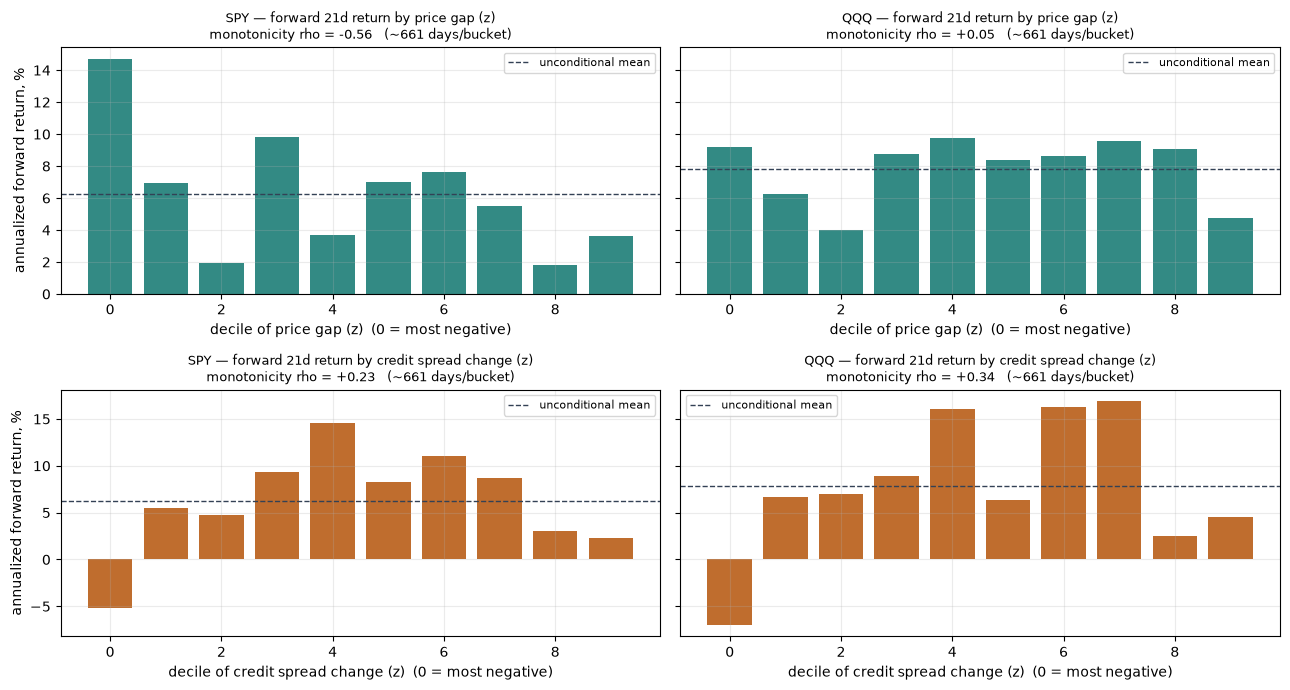

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey="row")
DECILES = 10

for column, ticker in enumerate(("SPY", "QQQ")):
    for row, (label, measure, colour) in enumerate((
            ("price gap (z)", overlay[f"gap_{ticker}"], "#0f766e"),
            ("credit spread change (z)", overlay["credit_z"], "#b45309"))):
        axis = axes[row][column]
        bucket = pd.qcut(measure, DECILES, labels=False)
        means = overlay.groupby(bucket)[f"fwd_{ticker}"].mean() * ANNUALIZE
        counts = overlay.groupby(bucket)[f"fwd_{ticker}"].size()
        axis.bar(means.index, means.to_numpy(), color=colour, alpha=0.85)
        axis.axhline(overlay[f"fwd_{ticker}"].mean() * ANNUALIZE, color="#334155", ls="--", lw=1,
                     label="unconditional mean")
        slope = np.corrcoef(means.index, means.to_numpy())[0, 1]
        axis.set_title(f"{ticker} — forward {FORWARD_DAYS}d return by {label}\n"
                       f"monotonicity rho = {slope:+.2f}   (~{counts.mean():.0f} days/bucket)",
                       fontsize=9)
        axis.set_xlabel(f"decile of {label}  (0 = most negative)")
        if column == 0:
            axis.set_ylabel("annualized forward return, %")
        axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

### The sign is contrarian for both, and they are close to independent

The price gap slopes the way Part 14 found — the lowest deciles carry the best forward returns, most
clearly on SPY. The credit measure slopes the *same* way but inverted in its own units: the decile
where the spread has been tightening hardest has the **worst** forward returns, and widening deciles
do better. Complacency in credit is a poor entry point; stress is a better one.

So both measures are contrarian, and their mutual correlation is only about −0.17 to −0.20. That is
the interesting part: they are not two versions of the same signal. A stretched price and a widening
spread are different pieces of information, which is the precondition for a blend adding anything.

Note also how small every forward correlation is — none exceeds 0.06 in absolute value. Whatever
follows is a marginal effect, and the decile charts are noisy enough that the monotonicity statistic
matters more than any individual bar.

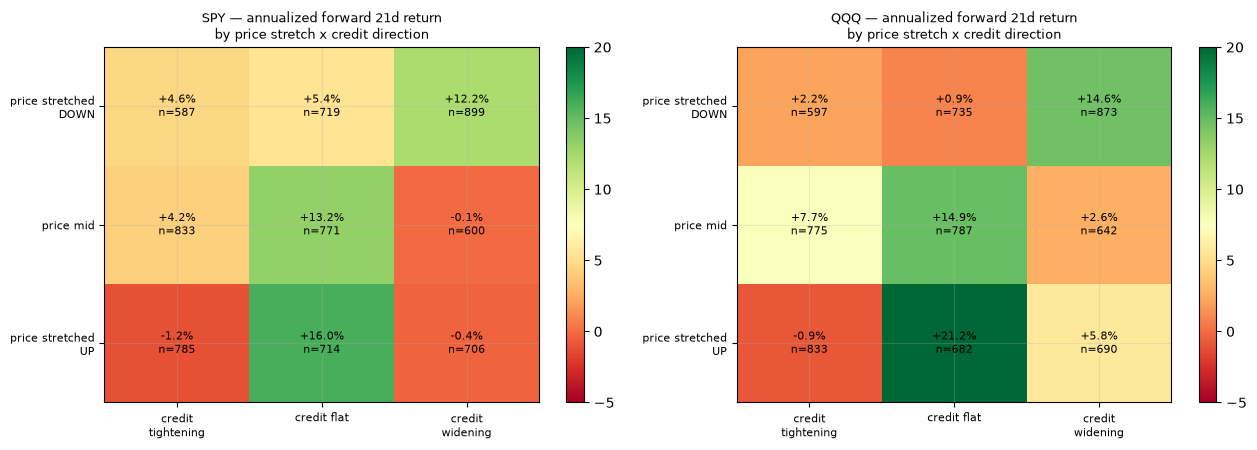

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
BUCKETS = 3
GAP_LABELS = ["price stretched\nDOWN", "price mid", "price stretched\nUP"]
CREDIT_LABELS = ["credit\ntightening", "credit flat", "credit\nwidening"]

for axis, ticker in zip(axes, ("SPY", "QQQ")):
    gap_bucket = pd.qcut(overlay[f"gap_{ticker}"], BUCKETS, labels=GAP_LABELS)
    credit_bucket = pd.qcut(overlay["credit_z"], BUCKETS, labels=CREDIT_LABELS)
    grid = (overlay.groupby([gap_bucket, credit_bucket], observed=True)[f"fwd_{ticker}"]
            .mean() * ANNUALIZE).unstack()
    counts = overlay.groupby([gap_bucket, credit_bucket], observed=True)[f"fwd_{ticker}"].size().unstack()
    image = axis.imshow(grid.to_numpy(), cmap="RdYlGn", aspect="auto",
                        vmin=-5, vmax=20)
    axis.set_xticks(range(BUCKETS), grid.columns, fontsize=8)
    axis.set_yticks(range(BUCKETS), grid.index, fontsize=8)
    for i in range(BUCKETS):
        for j in range(BUCKETS):
            axis.text(j, i, f"{grid.to_numpy()[i, j]:+.1f}%\nn={counts.to_numpy()[i, j]}",
                      ha="center", va="center", fontsize=8)
    axis.set_title(f"{ticker} — annualized forward {FORWARD_DAYS}d return\n"
                   f"by price stretch x credit direction", fontsize=9)
    fig.colorbar(image, ax=axis)
plt.tight_layout()
plt.show()

### The two signals do look complementary — in sample

Read the corners. The **best** cell in both indices is price stretched *down* combined with credit
*widening* — the capitulation combination, where both measures are simultaneously frightened. The
**worst** is price stretched *up* with credit *tightening*: everything is comfortable, and forward
returns are poor or negative.

That diagonal structure is what you would want from two complementary contrarian signals, and it is
the strongest argument in this section for blending them. Keep in mind that each cell holds only
around 600–900 days and the middle row and column are erratic, so this is suggestive rather than
established.

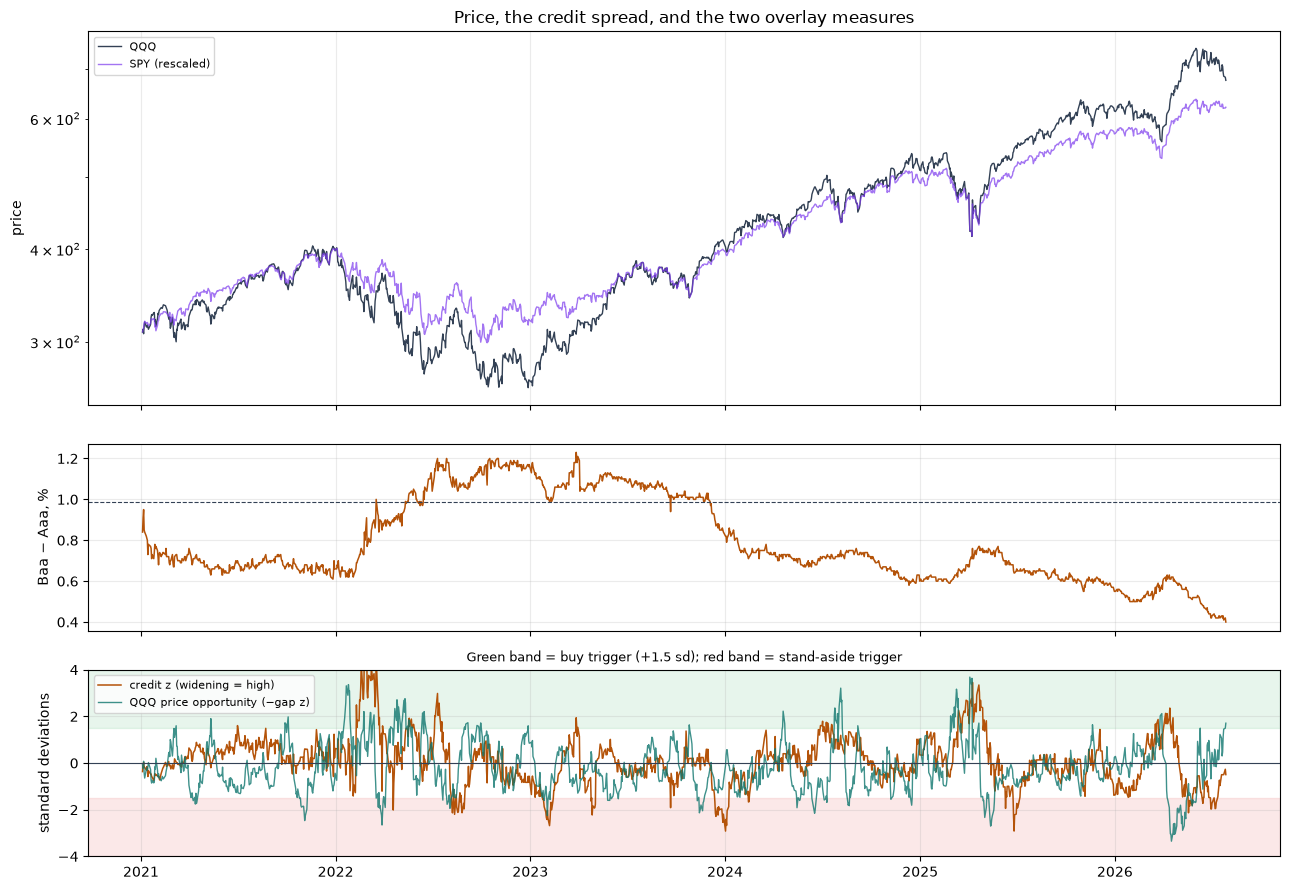

In [74]:
ZOOM_START = "2021-01-01"

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, height_ratios=[2, 1, 1])
zoom = overlay.loc[ZOOM_START:]

axes[0].plot(zoom.index, credit["qqq"].reindex(zoom.index), color="#334155", lw=1.0, label="QQQ")
axes[0].plot(zoom.index, close_prices.reindex(zoom.index) * (
    credit["qqq"].reindex(zoom.index).iloc[0] / close_prices.reindex(zoom.index).iloc[0]),
    color="#7c3aed", lw=1.0, alpha=0.7, label="SPY (rescaled)")
axes[0].set_yscale("log")
axes[0].set_ylabel("price")
axes[0].set_title("Price, the credit spread, and the two overlay measures")
axes[0].legend(fontsize=8, loc="upper left")

axes[1].plot(zoom.index, credit["spread"].reindex(zoom.index), color="#b45309", lw=1.1)
axes[1].set_ylabel("Baa − Aaa, %")
axes[1].axhline(credit["spread"].mean(), color="#334155", ls="--", lw=0.8)

axes[2].axhspan(OVERLAY_ENTRY, 4, color="#16a34a", alpha=0.10)
axes[2].axhspan(-4, -OVERLAY_ENTRY, color="#dc2626", alpha=0.10)
axes[2].plot(zoom.index, zoom["credit_z"], color="#b45309", lw=1.1, label="credit z (widening = high)")
axes[2].plot(zoom.index, -zoom["gap_QQQ"], color="#0f766e", lw=1.0, alpha=0.8,
             label="QQQ price opportunity (−gap z)")
axes[2].axhline(0, color="#334155", lw=0.8)
axes[2].set_ylim(-4, 4)
axes[2].set_ylabel("standard deviations")
axes[2].set_title(f"Green band = buy trigger (+{OVERLAY_ENTRY} sd); red band = stand-aside trigger",
                  fontsize=9)
axes[2].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

In [75]:
OVERLAY_TICKERS = {
    "SPY": (smooth_probabilities(probabilities, SELECTED_SPAN), "gap_SPY", "ret_SPY",
            "walk-forward, out-of-sample"),
    "QQQ": (smooth_probabilities(qqq_filtered, SELECTED_SPAN), "gap_QQQ", "ret_QQQ",
            "filtered path, full-sample parameters — optimistic"),
}
BLEND_WEIGHTS = np.arange(0.0, 1.001, 0.125)


def overlay_position(state_probabilities: pd.DataFrame, opportunity: pd.Series) -> pd.Series:
    """Part 15's machine, driven by whatever 'opportunity' measure is supplied (high = buy)."""
    signal = hysteresis_signal(-opportunity, OVERLAY_ENTRY, OVERLAY_ENTRY, 0.0)
    blended = (state_probabilities[BULL]
               + state_probabilities[CHOPPY] * signal.reindex(state_probabilities.index))
    return blended.where(state_probabilities[BULL] < BULL_CONVICTION, 1.0).shift(1).fillna(0.0)


scoreboard, sweeps, equity = {}, {}, {}
for ticker, (state_probabilities, gap_column, return_column, provenance) in OVERLAY_TICKERS.items():
    shared = overlay.index.intersection(state_probabilities.index)
    state_probabilities = state_probabilities.reindex(shared)
    returns_here = overlay.loc[shared, return_column]
    price_opportunity = -overlay.loc[shared, gap_column]
    credit_opportunity = overlay.loc[shared, "credit_z"]

    scoreboard[(ticker, "buy & hold")] = evaluate(pd.Series(1.0, index=shared), returns_here)
    scoreboard[(ticker, "1 - P(Bear)")] = evaluate(
        size_positions(state_probabilities, LEGACY_WEIGHTS), returns_here, COST_BPS)
    for name, measure in (("overlay: price gap only", price_opportunity),
                          ("overlay: credit only", credit_opportunity),
                          ("overlay: blend 50/50", (price_opportunity + credit_opportunity) / 2)):
        position = overlay_position(state_probabilities, measure)
        scoreboard[(ticker, name)] = evaluate(position, returns_here, COST_BPS)
        equity[(ticker, name)] = (position * returns_here
                                  - position.diff().abs().fillna(0) * COST_BPS / 100.0)
    equity[(ticker, "buy & hold")] = pd.Series(1.0, index=shared) * returns_here

    sweeps[ticker] = {}
    for weight in BLEND_WEIGHTS:
        position = overlay_position(
            state_probabilities, (1 - weight) * price_opportunity + weight * credit_opportunity)
        gross = evaluate(position, returns_here)
        net = evaluate(position, returns_here, COST_BPS)
        sweeps[ticker][weight] = {"sharpe_net": net["sharpe"],
                                  "max_drawdown_%": gross["max_drawdown_%"],
                                  "turnover_per_year": gross["turnover_per_year"]}
    print(f"{ticker}: {len(shared):,} rows, {shared.min():%Y-%m-%d}..{shared.max():%Y-%m-%d}"
          f"   ({provenance})")

board = pd.DataFrame(scoreboard).T
print()
print(board.round(2).to_string())

print()
print("Blend-weight sweep — 0 is price-gap only, 1 is credit only:")
for ticker in OVERLAY_TICKERS:
    sweep = pd.DataFrame(sweeps[ticker]).T
    sweep.index.name = "credit_weight"
    print(f"\n  {ticker}   (best net Sharpe at w = {sweep['sharpe_net'].idxmax():.3f})")
    print("  " + sweep.round(3).to_string().replace("\n", "\n  "))

print()
print("A different way to combine them: act only when BOTH measures agree.")
print("Full weight when both are stretched toward opportunity, aside when both are complacent,")
print("resting otherwise — so it trades rarely by construction.\n")
agreement = {}
for ticker, (state_probabilities, gap_column, return_column, _) in OVERLAY_TICKERS.items():
    shared = overlay.index.intersection(state_probabilities.index)
    state_probabilities = state_probabilities.reindex(shared)
    returns_here = overlay.loc[shared, return_column]
    price_opportunity = -overlay.loc[shared, gap_column]
    credit_opportunity = overlay.loc[shared, "credit_z"]
    both_buy = (price_opportunity >= OVERLAY_ENTRY) & (credit_opportunity >= OVERLAY_ENTRY)
    both_aside = (price_opportunity <= -OVERLAY_ENTRY) & (credit_opportunity <= -OVERLAY_ENTRY)
    signal = pd.Series(np.where(both_buy, 1.0, np.where(both_aside, 0.0, 0.5)), index=shared)
    position = ((state_probabilities[BULL] + state_probabilities[CHOPPY] * signal)
                .where(state_probabilities[BULL] < BULL_CONVICTION, 1.0).shift(1).fillna(0.0))
    gross, net = evaluate(position, returns_here), evaluate(position, returns_here, COST_BPS)
    gap_only = board.loc[(ticker, "overlay: price gap only")]
    agreement[ticker] = {
        "days_signal_fires_%": (signal != 0.5).mean() * RETURN_SCALE,
        "sharpe_net": net["sharpe"],
        "sharpe_net_gap_only": gap_only["sharpe"],
        "max_drawdown_%": gross["max_drawdown_%"],
        "max_drawdown_gap_only": gap_only["max_drawdown_%"],
        "turnover_per_year": gross["turnover_per_year"],
        "turnover_gap_only": gap_only["turnover_per_year"],
    }
print(pd.DataFrame(agreement).T.round(2).to_string())

SPY: 6,383 rows, 2001-03-09..2026-07-28   (walk-forward, out-of-sample)
QQQ: 6,614 rows, 2000-04-07..2026-07-28   (filtered path, full-sample parameters — optimistic)

                             annualized_return_%  annualized_vol_%  sharpe  max_drawdown_%  turnover_per_year  average_position
SPY buy & hold                              6.96             19.11    0.36          -56.47               0.04              1.00
    1 - P(Bear)                             8.82             12.85    0.69          -25.62               1.68              0.84
    overlay: price gap only                 7.37             10.03    0.73          -16.99               5.55              0.65
    overlay: credit only                    6.12              9.76    0.63          -19.81               4.34              0.65
    overlay: blend 50/50                    6.63              9.86    0.67          -18.98               3.99              0.65
QQQ buy & hold                              7.18             26.

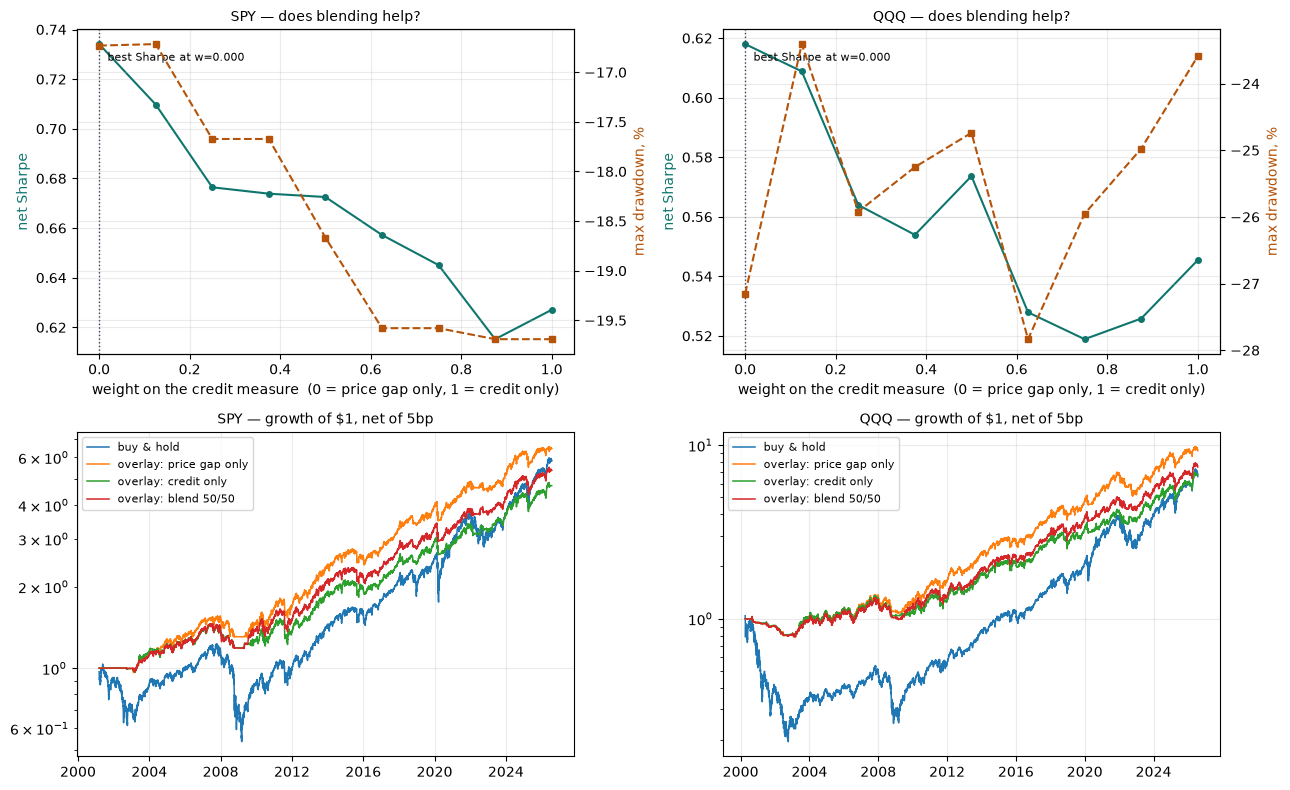

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for column, ticker in enumerate(("SPY", "QQQ")):
    sweep = pd.DataFrame(sweeps[ticker]).T
    axis = axes[0][column]
    axis.plot(sweep.index, sweep["sharpe_net"], marker="o", ms=4, color="#0f766e",
              label="net Sharpe")
    axis.set_xlabel("weight on the credit measure  (0 = price gap only, 1 = credit only)")
    axis.set_ylabel("net Sharpe", color="#0f766e")
    axis.set_title(f"{ticker} — does blending help?", fontsize=10)
    twin = axis.twinx()
    twin.plot(sweep.index, sweep["max_drawdown_%"], marker="s", ms=4, color="#b45309",
              ls="--", label="max drawdown")
    twin.set_ylabel("max drawdown, %", color="#b45309")
    best = sweep["sharpe_net"].idxmax()
    axis.axvline(best, color="#334155", ls=":", lw=1)
    axis.annotate(f"best Sharpe at w={best:.3f}", (best, sweep["sharpe_net"].max()),
                  textcoords="offset points", xytext=(6, -12), fontsize=8)

    axis = axes[1][column]
    for name in ("buy & hold", "overlay: price gap only", "overlay: credit only",
                 "overlay: blend 50/50"):
        series = equity[(ticker, name)]
        axis.plot(series.index, (series / RETURN_SCALE).cumsum().apply(np.exp), lw=1.1, label=name)
    axis.set_yscale("log")
    axis.set_title(f"{ticker} — growth of $1, net of {COST_BPS:.0f}bp", fontsize=10)
    axis.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

### Verdict: it works as a signal, it does not improve the rule

**The credit overlay is a real signal.** On both indices it beats buy-and-hold on Sharpe by a wide
margin and roughly halves the drawdown, and it beats `1 - P(Bear)` on drawdown. Dropped into the
Part 15 slot it functions exactly as intended — nothing about the architecture had to change.

**But it is worse than the price gap it would replace, and blending does not help.** The weight sweep
is decisive and it agrees across both indices: **the best weight on credit is zero.** Every positive
weight lowers net Sharpe, roughly monotonically. That is the predictive-correlation table asserting
itself — the gap's forward correlation is around −0.05 and credit's is around +0.02, so mixing in
credit mostly dilutes the stronger signal.

Two results are worth keeping, and both are about *risk* rather than return:

1. **A small credit weight buys drawdown cheaply.** At a weight of 0.125 the QQQ drawdown improves by
   almost four points for less than 0.01 of Sharpe, and turnover falls too. If drawdown is the
   binding constraint rather than Sharpe, that is a favourable trade.
2. **The "both agree" version trades far less for the same result.** Requiring *both* measures to be
   stretched in the same direction fires on only about 2 % of days, yet on QQQ it roughly matches
   gap-only Sharpe while cutting the drawdown by nearly four points and turnover by about 30 %.
   The uncomfortable reading is that most of the overlay's contribution comes from the regime model
   underneath it, and doing almost nothing in the Choppy slice is nearly as good as doing something.

**And the cross-index caveat matters here.** SPY's numbers come from the genuine walk-forward path;
QQQ's use filtered probabilities from full-sample parameters, so QQQ's absolute figures are
optimistic and should not be compared with SPY's. What *is* comparable is the *ordering* of the
variants, and that ordering is identical on both: gap, then blend, then credit.

**Where this leaves the recommendation from Part 22.** It was right that the spread belongs in this
slot rather than in the transition matrix or a forecast, and wrong to imply it would improve the
result. The honest summary: the spread is a legitimate alternative overlay with a slightly better
risk profile and slightly worse return profile, and the notebook's existing price-gap overlay remains
the better single choice. Nothing here has been tested with the walk-forward parameter selection that
Part 16 showed is where such gains usually disappear.

## Part 24 — Conclusions

1. **Three states is the right size.** BIC keeps improving as states are added, but from the
   fourth onward the new states have ~1-day expected durations — outlier buckets, not regimes.

2. **The states are Bull / Choppy / Bear, and volatility is what separates them.** Roughly half
   the days sit in a low-volatility state carrying the positive drift; roughly half in a
   mid-volatility state with none; a small minority in a high-volatility state with severely
   negative drift.

3. **"Choppy" is the accurate name for the middle state.** Its episodes end where they started at
   every length (Part 7), and its mean reversion is a *medium-horizon* effect — strongest in the
   3-to-21 day band, mild (|ρ| ≈ 0.1), and not even unique to it, since Bear reverses harder
   (Part 8). Zero drift at the daily scale is what the model estimates; reversion at a monthly
   scale is a separate property that had to be measured.

4. **Bull ↔ Bear transitions are effectively impossible in one step — while markets are calm.**
   Unconditionally both directions route through Choppy, so exiting a bear signal means going
   neutral rather than re-risking. But Part 9 shows the waypoint is conditional: with the VOL
   Regime Index stressed, a direct Bull → Bear break becomes the likelier way out of Bull.

5. **The VOL Regime Index earns its place — in the transition matrix, not the emissions.** Letting
   transitions depend on it improves fit decisively (LR p ≈ 0) and survives BIC's parameter
   penalty by ~100 points. What it controls is the persistence of the two extreme states: Bull is
   near-absorbing when the index is calm and a coin flip per day when it is stressed, with Bear
   the mirror image.

6. **The taxonomy is not SPY-specific.** QQQ, DIA and IWM reproduce it with sensible
   asset-specific differences and largely agreeing regime paths.

7. **Out-of-sample, this is a risk manager, not an alpha source.** Causally-filtered states still
   sort forward returns, but the practical gain is lower volatility and shallower drawdowns rather
   than higher returns.

8. **The index's forecasting gain survives the walk-forward; it does not convert into P&L.** Out of
   sample the index-driven model wins on predictive log-likelihood (+62 log points, 18 of 25 years,
   Diebold-Mariano p ≈ 0.002), and the advantage concentrates at both extremes of the index while
   going negative mid-range. But under every position rule in Part 12 — including volatility
   targeting, which consumes the variance forecast directly — it runs neck and neck with the
   constant-transition model. A density edge appears not to be expressible in a long-only spot
   position; instruments that pay off in variance are where it would show.

9. **Sizing on the full state vector cuts risk, not return.** `max(0, P(Bull) + 0.5·P(Choppy) −
   P(Bear))` matches `1 - P(Bear)` on Sharpe at roughly a third less volatility and drawdown, and
   most of that comes from de-weighting Choppy rather than from the Bear brake. Shorting the Bear
   state, by contrast, loses money outright — its violent snapbacks more than pay for its drift.

10. **Debouncing the state path is the single most effective change in the notebook.** An EMA over
    the probability vector cuts regime switches from ~21/yr to ~7 and turnover on `1 - P(Bear)` from
    6.7 round trips to 1.8, while *raising* gross Sharpe — the one-day flickers were noise and acting
    on them destroyed value even for free. Median regime episode goes from 3 days to 21.

11. **The span is a plateau, and hindsight is worth ~0.07 Sharpe.** Spans 7-11 are indistinguishable,
    and smoothing beats not smoothing in every sub-period. But a walk-forward selector choosing the
    span from prior data only (0.396) does *worse* than never smoothing (0.413), and far worse than
    the hindsight-optimal fixed span (0.483). Every other hyperparameter here — the 20-day average,
    the 1.5σ entry, the 75 % Bull threshold, three states — was chosen the same flattering way and
    carries a similar unmeasured optimism.

12. **A steady-state Kalman filter *is* the EMA**, algebraically, with the knob relabelled from a
    span to a noise ratio $q = Q/R$. So the only way a Kalman filter can beat an EMA here is by
    varying its gain through time — and the two obvious ways to do that both fail. Distrusting days
    the model is unsure about makes things monotonically worse (ambiguity is information, not noise),
    and driving the filter's speed off the VOL Regime Index does nothing, because the Hamilton filter
    has already consumed the index.

13. **What helps a little is a second state variable, not the filter.** A local-linear-trend filter
    that tracks the probability's *slope* as well as its level beats the best EMA by ~0.01 Sharpe,
    gross and net, because the slope pays back the lag that smoothing costs — a base span of 30
    becomes usable where a 30-day EMA collapses. The gain is concentrated exactly where the mechanism
    predicts (nil at short spans, large at long ones) and replicates in the two hard sub-periods. But
    it is an order of magnitude smaller than the gain from smoothing at all, and walk-forward
    selection over the grid — while far better than Part 16's, clearing the no-smoothing bar it
    failed — still lands below a fixed EMA. **Debouncing is what matters; the choice of debouncer is
    a rounding error.**

14. **The Choppy state is symmetric because at daily frequency the model cannot see direction.**
    Volatility carries ~200x more per-observation likelihood evidence than drift, so state
    boundaries are drawn by volatility and each bucket's mean is whatever falls out. QQQ gained
    27.6 % between April and June 2026 and the model called 54 of 62 days Choppy; the largest
    "Choppy" episodes in both names are the 1999, 2003, 2009 and 2020 rallies. Realized
    semideviation confirms it — Choppy's upside/downside ratio is 0.97 against Bull's 1.38, so the
    state is symmetric because it *pools* melt-ups with grind-downs.

15. **Nothing tested repairs it, and the reason is information-theoretic.** Volatility-standardized
    returns destroy the persistence that makes it a regime model; per-state AR(1) fits
    $\phi \approx 0$ and loses on BIC; a fourth state produces a volatile-upward regime whose drift
    swings >100 points across random restarts; and a horizon sweep from 1 to 21 days finds no
    reliable setting. Aggregation cannot help in principle — Fisher information for the mean is
    $n/\sigma^2$ regardless of $h$, so re-timing changes only the per-observation *mix* of drift and
    volatility evidence, never the total. Where a weekly fit does yield a positive-drift middle
    state, that state's median week is **negative** and it sits on recent declines: the same disease
    relocated, not cured. **The model is a volatility instrument — the 40 worst weeks in QQQ history
    all land in its high-volatility state — and should not be asked for direction.**

16. **Skewed emissions: the Gaussian was wrong, but fixing it does not buy direction.** A
    skew-normal emission adds one shape parameter $\alpha$ per state ($\alpha = 0$ is the Gaussian,
    so the models are nested and the subclass can be verified exactly). Returns within a regime
    really are skewed — the likelihood ratio rejects $\alpha = 0$ on both indices at both state
    counts, and BIC prefers the skewed model for QQQ at three states and SPY at four (the latter by
    fitting implausible |alpha| > 4 shapes onto Part 19's degenerate one-day states — an artifact,
    not a finding). But the tilt runs the *wrong way* for the purpose: at $k=3$ the calm and middle states are **negatively** skewed and the crash
    state **positively** skewed, independently confirming Part 12's finding that shorting Bear loses
    money to its snapbacks. The April-June 2026 rally is not relabelled — the skewed model puts
    **all** 62 days in the middle state rather than 54.

17. **Why no emission density can fix this, which closes the question.** Skewness is a claim about
    *tails* — that large moves favour one direction. A melt-up is not a few enormous up-days; it is a
    long run of ordinary, modestly positive days, whose distribution looks like a choppy run's.
    Sustained drift is a property of the **sequence**, and an HMM with independent emissions assumes
    each day is an independent draw given the state, so ordering information is invisible to it by
    construction. Skew-$t$ would fail identically. **Direction must enter through the transition
    matrix (Part 9's index works because it is an external series) or through a constrained state
    whose mean is fixed rather than estimated. The emissions are a closed question.**

18. **The VOL Regime Index had never been applied to QQQ — and applying it makes the labels worse.**
    Every cross-asset fit (Part 10) and everything Parts 19-20 built on top used constant
    transitions; the index was SPY-only. Fitting it on QQQ replicates Part 9 decisively — LR
    $\chi^2(6) = 137.9$, $p \approx 3\times10^{-27}$, BIC 23446 → 23361, Bull's expected duration
    39 → 798 days, near-absorbing when calm (0.999) and a coin flip when stressed (0.215). But the
    April-June 2026 rally barely moves (4 days Choppy→Bull, 4 more Choppy→**Bear**), and the 2003,
    2009 and 2020 recoveries all gain Bear days. Sample-wide the Bull share *falls* 43.8 % → 37.1 %.

19. **Which sharpens conclusion 17: a transition driver must be *directional*, not merely external.**
    The index is a volatility signal, so routing it through the transition matrix makes the model
    more volatility-driven, not more direction-aware — and because high volatility maps onto the
    bearish state, it actively biases violent rallies towards Bear. Recovery rallies happen while VIX
    is still elevated, which is exactly when the index says "stress". Direction has to come from
    something directional: breadth, credit spreads, earnings revisions, a trend measure.

20. **Corporate credit: real co-movement, no prediction, and the sign of the raw yields flips by
    era.** Moody's Baa and Aaa yields (FRED DBAA/DAAA) co-move strongly with QQQ *contemporaneously*
    — the Baa−Aaa spread against QQQ over quarterly windows is about **−0.43** — but every
    *predictive* correlation is near zero, and the level-based ones largely dissolve when the shared
    secular trend is removed. Worse, the raw-yield relationship is **not stable**: the 5-day
    correlation with QQQ is **+0.42 in 2010-2014** and **−0.38 in 2022-2026**. Rising yields meant
    improving growth in the disinflationary decade and a discount-rate shock in the inflationary one.
    The intuition that QQQ is weak when yields rise is right for the recent era and backwards for the
    2010s.

21. **The Baa−Aaa spread is the stable version, because subtracting removes the level of rates.**
    Its correlation with QQQ is negative in **all six** sub-periods tested. Stripping Aaa out of Baa
    leaves credit risk, which is bad for equities under any monetary regime, whereas the level of
    rates is sometimes good news. QQQ returns **−9.3 %/yr** while the spread widens and **+27.7 %/yr**
    while it tightens.

22. **The one-day FRED publication lag is solvable — with a faster series, not a better model.**
    Today's LQD return nowcasts today's unpublished Baa change with **82 % directional accuracy**
    (RMSE −12 %, MAE −26 % versus persistence). An AR(5) on daily changes and a TEMA extrapolation
    are both **worse than persistence**, because daily moves in a long-maturity corporate yield are
    near-random-walk and the past of a random walk says nothing about its next step. General lesson:
    when a series is unpredictable from its own history, nowcast it with a correlated series that
    *publishes sooner*. For the spread nothing beats persistence, but its daily change is ~2bp against
    a 40bp standard deviation, so yesterday's value is fine.

23. **As a transition driver, credit fails — significant but not worth its parameters.** Every credit
    specification is worse than *no driver at all* on BIC (spread z-score +30), while the VOL Regime
    Index improves it by 115. Adding the spread on top of the index raises the log-likelihood
    significantly (LR $\chi^2(6) = 35.7$) yet BIC still worsens, 20775 → 20792. The shape is right —
    a wide spread opens the direct Bull → Bear route (0.163) that a tight spread closes (0.000) — it
    is just far weaker than what volatility does to the same matrix. None of it relabels the rallies.
    **Part 21's search for a directional driver remains unsuccessful.**

24. **The credit spread works in the Part 15 overlay slot, but does not improve on the price gap.**
    Dropped in as $s_t$ it needs no architectural change and comfortably beats buy-and-hold on both
    indices — SPY Sharpe 0.63 vs 0.36 with drawdown −19.8 % vs −56.5 %; QQQ 0.55 vs 0.27 with −24.0 %
    vs −81.2 % — and beats `1 - P(Bear)` on drawdown. Both measures turn out to be **contrarian**
    (credit widening precedes better returns, not worse) and they are only −0.17/−0.20 correlated, so
    they are not redundant. In-sample the 3x3 grid looks complementary: the best cell in both indices
    is price stretched *down* with credit *widening* — capitulation — and the worst is price stretched
    *up* with credit *tightening*.

25. **Blending is decisively unhelpful for return and quietly helpful for risk.** The weight sweep
    puts the optimum at **zero credit weight on both indices**, monotonically: SPY 0.734 → 0.627 and
    QQQ 0.618 → 0.545 as the weight goes 0 → 1. That is the forward-correlation table asserting
    itself (gap ≈ −0.05, credit ≈ +0.02), and mixing in credit dilutes the stronger signal. But two
    risk results survive: a **small** weight of 0.125 improves the QQQ drawdown by 3.7 points for
    0.009 of Sharpe and cuts turnover; and an **"act only when both agree"** rule fires on ~2 % of
    days yet matches gap-only Sharpe (0.61 vs 0.62) while cutting QQQ drawdown 3.9 points and
    turnover 30 %. The uncomfortable implication is that most of the overlay's value comes from the
    regime model beneath it, and doing almost nothing in the Choppy slice is nearly as good.

### Sensible next steps

- **Test the density edge where it can actually be expressed.** Part 12 shows a long-only spot
  position cannot collect it. The natural venue is variance: option straddles, VIX futures, or a
  variance-swap proxy, sized on the model's predicted volatility versus the market's implied.
- **Debounce and cost-optimise the sizing rule.** Turnover roughly doubles versus `1 - P(Bear)`, and
  5bp already takes several points of Sharpe. A deadband or a slower probability smooth is the
  cheapest available improvement.
- **Trade the Choppy state's reversion explicitly** at a 5-21 day horizon and see whether Part 8's
  |ρ| ≈ 0.1 survives costs. Probably it doesn't alone; it may as an overlay on the exposure rule.
- ~~`MarkovAutoregression(order=1, switching_ar=True)`~~ — **tested in Part 19 and rejected.** The
  fitted per-state AR(1) coefficients are all within a few hundredths of zero and BIC prefers the
  model without them; Part 8's reversion lives at multi-week horizons, which one daily lag cannot
  reach.
- **Total-return series** instead of unadjusted closes, so the annualized figures are comparable
  to a real portfolio.
- **Transaction costs and a debounced signal** before treating Part 11's curve as achievable.
- ~~Skewed emissions~~ — **built and tested in Part 20; rejected for this purpose.** The
  `SkewMarkovRegression` subclass is kept because it is a better description of the data, but it
  does not relabel the rallies and cannot, for the reason in conclusion 17.
- **Walk the skew-normal model forward.** Part 20 is entirely in-sample. Its BIC edge on QQQ at
  three states may or may not survive, and its tail shapes are the part most likely to matter for
  option-based strategies (Part 18) rather than for spot exposure.
- ~~Credit spreads as a transition driver~~ — **tested in Part 22 and rejected on BIC.** Still
  untried and better motivated by the evidence: **market breadth** or **earnings revisions**, which
  are directional without being a rate or a volatility measure.
- ~~Use the credit spread in the overlay slot~~ — **done in Part 23.** It works but does not beat the
  price gap; keep it as the low-turnover / shallow-drawdown variant, not the default.
- **Walk-forward the overlay choice itself.** Part 23 picked its thresholds and blend weight by
  looking at the same period it scores on, exactly the sin Part 16 priced at ~0.07 Sharpe. The
  "both agree" variant is the one most likely to survive, since it has the fewest moving parts.
- **A walk-forward regime path for QQQ.** Part 23's QQQ figures use full-sample parameters, so only
  the *ordering* of its variants is trustworthy, not the levels.
- **A logit-space filter.** Part 17 treats the three probabilities as independent Gaussian series and
  renormalizes afterwards, which is wrong on both counts. Filtering log-odds and softmaxing back
  respects the simplex and makes the Gaussian noise assumption defensible.